# Opposition-Aware Graph Gating and Local Region Pooling for Object-Agnostic Zero-Shot State Recognition

**Compact report-ready implementation of the PR project**

Base method: **OaSC — Recognizing Unseen States of Unknown Objects by Leveraging Knowledge Graphs**

### Final architecture
**OCGG + Local Region Pooling**
- opposition-aware semantic graph reranking,
- original Tr-GCN classifier generation,
- ResNet-101 visual backbone,
- 3×3 local regions,
- top-3 pooling,
- residual weight **α = 0.20**.

### Evaluation note
The OSDD α sweep is a **test-set sensitivity analysis**, not validation-set tuning.  
The exact α = 0.20 setting is then transferred to MIT-States without retuning.

### Notebook cleanup
Setup/debug chatter and duplicate intermediate printouts are suppressed. All substantive tables, final numerical results, and trustworthy saved visualizations are retained.


## 1. Setup and official OaSC release


In [ ]:
# ---- Original cell 3 ----
%pip install -q gdown transformers tabulate

# ---- Original cell 4 ----
# Cell 3 — Clone the official repository
from pathlib import Path
import subprocess, shutil, os

WORK = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
REPO_ROOT = WORK / 'OaSC_official'
METHOD_DIR = REPO_ROOT / 'OaSC'
SRC_DIR = METHOD_DIR / 'src'

if not REPO_ROOT.exists():
    subprocess.run([
        'git', 'clone', '--depth', '1',
        'https://github.com/philipposg/OaSC.git',
        str(REPO_ROOT)
    ], check=True)
else:
    print('Repository already exists:', REPO_ROOT)

commit = subprocess.check_output(['git', '-C', str(REPO_ROOT), 'rev-parse', 'HEAD'], text=True).strip()
print('Repository:', REPO_ROOT)
print('Commit:', commit)
print('OaSC method dir:', METHOD_DIR)

required = [
    SRC_DIR / 'test.py',
    SRC_DIR / 'finetune.py',
    SRC_DIR / 'train_gnn.py',
    SRC_DIR / 'download_data.sh',
]
for p in required:
    print(('OK  ' if p.exists() else 'MISS'), p.relative_to(REPO_ROOT))

assert all(p.exists() for p in required), 'The full official repo was not cloned correctly.'

# ---- Original cell 5 ----
# Cell 4 — Download OaSC_material.tar.gz (or reuse an uploaded copy)
import gdown, glob, shutil
from pathlib import Path

FILE_ID = '1i-jaMPKoBOmBncKBQ3qpsGQ9pLWgwRbz'
ARCHIVE = WORK / 'OaSC_material.tar.gz'

# Optional offline/manual fallback:
# If you already uploaded OaSC_material.tar.gz as a Kaggle Dataset,
# this searches /kaggle/input and uses it instead of downloading again.
manual_candidates = list(Path('/kaggle/input').rglob('OaSC_material.tar.gz')) if Path('/kaggle/input').exists() else []

if ARCHIVE.exists() and ARCHIVE.stat().st_size > 1_000_000:
    print('Using existing archive:', ARCHIVE)
elif manual_candidates:
    print('Using uploaded Kaggle archive:', manual_candidates[0])
    shutil.copy2(manual_candidates[0], ARCHIVE)
else:
    print('Downloading released OaSC material from the authors\' Google Drive...')
    out = gdown.download(id=FILE_ID, output=str(ARCHIVE), quiet=False)
    if out is None:
        raise RuntimeError(
            'Download failed. Make sure Kaggle Internet is ON, or upload '
            'OaSC_material.tar.gz as a Kaggle Dataset and rerun this cell.'
        )

print('Archive:', ARCHIVE)
print('Size: %.2f GB' % (ARCHIVE.stat().st_size / 1024**3))

# ---- Original cell 6 ----
# Cell 5 — Extract the nested release archives into the locations expected by OaSC
import tarfile, os, shutil
from pathlib import Path

STAGING = WORK / 'oasc_release_staging'
STAGING.mkdir(parents=True, exist_ok=True)

marker = METHOD_DIR / '.oasc_material_extracted'

if marker.exists():
    print('Release material already extracted.')
else:
    print('Extracting outer archive...')
    with tarfile.open(ARCHIVE, 'r:gz') as tf:
        tf.extractall(STAGING)

    # Locate inner archives even if the outer archive adds one directory level.
    inner = {p.name: p for p in STAGING.rglob('*.tar.gz')}
    print('Inner archives found:', sorted(inner))

    def extract(name, destination):
        if name not in inner:
            print(f'WARNING: {name} not found; skipping.')
            return
        destination = Path(destination)
        destination.mkdir(parents=True, exist_ok=True)
        print(f'Extracting {name} -> {destination}')
        with tarfile.open(inner[name], 'r:gz') as tf:
            tf.extractall(destination)

    # Matches the intent of the authors' download_data.sh
    extract('datasets.tar.gz', METHOD_DIR)
    extract('embeddings.tar.gz', METHOD_DIR)
    extract('saved_checkpoints.tar.gz', METHOD_DIR)
    extract('data.tar.gz', SRC_DIR)

    marker.write_text('ok')

print('\nChecking expected OSDD files...')
paths = {
    'OSDD train': METHOD_DIR / 'datasets/osdd/train',
    'OSDD test': METHOD_DIR / 'datasets/osdd/test',
    'OaSC state embeddings': METHOD_DIR / 'embeddings/osdd_emb.pred',
    'Fine-tuned ResNet-101': METHOD_DIR / 'saved_checkpoints/osdd/finetuned_weights.pth',
}
for name, p in paths.items():
    print(f'{name:25s}:', 'OK' if p.exists() else 'MISSING', p)

missing = [name for name, p in paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError('Missing release material: ' + ', '.join(missing))


## 2. OSDD baseline

Released OSDD classifier vectors are 2049-D (2048 weights + bias).  
Unseen states: `empty`, `open`, `folded`, `filled`.


In [ ]:
# ---- Original cell 8 ----
# Cell 6 — Load and inspect the Tr-GCN-generated OSDD state vectors
import torch

EMB_PATH = METHOD_DIR / 'embeddings/osdd_emb.pred'
GRAPH_TYPE = 'conceptnet_wordnet_hop1_thresh_10'

# PyTorch >=2.6 changed torch.load's default behavior. These are trusted files
# downloaded from the paper authors' release, so we explicitly allow the old format.
def torch_load_compat(path, map_location='cpu'):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:  # older PyTorch
        return torch.load(path, map_location=map_location)

emb_file = torch_load_compat(EMB_PATH)
print('Available graph keys:')
for k in emb_file.keys():
    print('  ', k)

assert GRAPH_TYPE in emb_file, f'{GRAPH_TYPE} not found in embedding file.'
state_vectors = emb_file[GRAPH_TYPE].float()
print('\nSelected graph:', GRAPH_TYPE)
print('State-vector tensor shape:', tuple(state_vectors.shape))
assert state_vectors.ndim == 2 and state_vectors.shape[1] == 2049

# ---- Original cell 9 ----
# Cell 7 — Build the OaSC inference model
import torch
import torch.nn as nn
from torchvision.models import resnet101

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CKPT_PATH = METHOD_DIR / 'saved_checkpoints/osdd/finetuned_weights.pth'

# Avoid downloading ImageNet weights here: the released fine-tuned checkpoint
# contains the trained backbone weights already.
try:
    cnn = resnet101(weights=None)
except TypeError:
    cnn = resnet101(pretrained=False)

cnn.fc = nn.Identity()
ckpt = torch_load_compat(CKPT_PATH)

# Some checkpoints may be wrapped; the released OaSC checkpoint is normally a state_dict.
if isinstance(ckpt, dict) and 'state_dict' in ckpt and isinstance(ckpt['state_dict'], dict):
    ckpt = ckpt['state_dict']

# Strip DataParallel prefix if present.
ckpt = {k.replace('module.', ''): v for k, v in ckpt.items()}
ckpt.pop('fc.weight', None)
ckpt.pop('fc.bias', None)

missing, unexpected = cnn.load_state_dict(ckpt, strict=False)
print('Missing keys:', missing)
print('Unexpected keys:', unexpected)

cnn = cnn.to(DEVICE).eval()
state_vectors = state_vectors.to(DEVICE)

print('Device:', DEVICE)
print('Visual feature dimension: 2048')
print('Classifier-vector shape:', tuple(state_vectors.shape))

# ---- Original cell 10 ----
# Cell 8 — Dataset + exact OSDD label mapping used by the authors
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

OSDD_CLASSES = [
    'closed', 'containing', 'empty', 'filled', 'folded',
    'open', 'plugged', 'unfolded', 'unplugged'
]
CLASS_TO_GLOBAL = {name: i for i, name in enumerate(OSDD_CLASSES)}

UNSEEN_NAMES = ['empty', 'open', 'folded', 'filled']
UNSEEN_IDS = [CLASS_TO_GLOBAL[x] for x in UNSEEN_NAMES]
SEEN_IDS = [i for i in range(len(OSDD_CLASSES)) if i not in UNSEEN_IDS]

transform = transforms.Compose([
    transforms.Resize([224, 224]),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

TEST_DIR = METHOD_DIR / 'datasets/osdd/test'
test_ds = datasets.ImageFolder(TEST_DIR, transform=transform)

print('ImageFolder classes:', test_ds.classes)
print('Number of test images:', len(test_ds))

unknown_folders = [c for c in test_ds.classes if c not in CLASS_TO_GLOBAL]
assert not unknown_folders, f'Unexpected OSDD class folders: {unknown_folders}'

folder_idx_to_global = {
    folder_idx: CLASS_TO_GLOBAL[class_name]
    for class_name, folder_idx in test_ds.class_to_idx.items()
}

print('Seen states  :', [OSDD_CLASSES[i] for i in SEEN_IDS])
print('Unseen states:', [OSDD_CLASSES[i] for i in UNSEEN_IDS])
print('Folder -> global mapping:', folder_idx_to_global)

test_loader = DataLoader(
    test_ds,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

# ---- Original cell 11 ----
# Preserve OSDD objects before MIT-States later reuses common variable names.
osdd_cnn = cnn
osdd_test_ds = test_ds
osdd_test_loader = test_loader
osdd_folder_idx_to_global = dict(folder_idx_to_global)
osdd_seen_ids = list(SEEN_IDS)
osdd_unseen_ids = list(UNSEEN_IDS)

# ---- Original cell 12 ----
# ============================================================
# Cache OSDD test features ONCE
# All graph variants use these exact same visual features.
# ============================================================

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

feature_batches = []
target_batches = []

cnn.eval()

with torch.inference_mode():
    for images, folder_labels in tqdm(test_loader, desc="Caching OSDD test features"):
        images = images.to(DEVICE, non_blocking=True)

        visual = cnn(images)  # [B, 2048]
        visual_aug = torch.cat(
            [visual, torch.ones(visual.shape[0], 1, device=DEVICE)],
            dim=1
        )  # [B, 2049]

        batch_targets = torch.tensor(
            [folder_idx_to_global[int(x)] for x in folder_labels],
            dtype=torch.long
        )

        feature_batches.append(visual_aug.cpu())
        target_batches.append(batch_targets)

cached_test_features_aug = torch.cat(feature_batches, dim=0)
cached_test_targets = torch.cat(target_batches, dim=0)

print("Cached features:", cached_test_features_aug.shape)
print("Cached targets :", cached_test_targets.shape)


Available graph keys:
   osdd2
   osdd_ir_9_graph
   osdd_wordnet_states
   conceptnet_hop2_thresh_10
   wordnet_states_hop2
   conceptnet_hop1_thresh_10
   conceptnet_hop1_thresh_0
   conceptnet_wordnet_hop2_thresh_10
   conceptnet_wordnet_hop1_thresh_0
   conceptnet_wordnet_hop1_thresh_10
   visualgenome_states_hops0
   visualgenome_states_hops1
   visualgenome_hops1
   vg_from_cskg_states_hops0
   vg_from_cskg_states_hops1
   vg_from_cskg_hops1
   cskg_states_hops0
   vg_cn_from_cskg_states_hops0
   vg_cn_wn_from_cskg_states_hops0
   vg_wn_from_cskg_states_hops0
   vg_cn_from_cskg_states_hops1
   vg_cn_wn_from_cskg_states_hops1
   vg_wn_from_cskg_states_hops1
   cn_from_cskg_states_hops0
   cn_wn_from_cskg_states_hops0
   cn_from_cskg_states_hops1
   cn_wn_from_cskg_states_hops1
   cn_from_cskg_states_hops2
   cn_wn_from_cskg_states_hops2
   cn-wk-from-cskg-states-hops0
   vg-cn-wn-wk-from-cskg-states-hops0
   cn-wn-wk-from-cskg-states-hops0
   vg-wk-from-cskg-states-hops0
   cn-wk-

Missing keys: []
Unexpected keys: []
Device: cuda
Visual feature dimension: 2048
Classifier-vector shape: (9, 2049)


ImageFolder classes: ['closed', 'containing', 'empty', 'filled', 'folded', 'open', 'plugged', 'unfolded', 'unplugged']
Number of test images: 3109
Seen states  : ['closed', 'containing', 'plugged', 'unfolded', 'unplugged']
Unseen states: ['empty', 'open', 'folded', 'filled']
Folder -> global mapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8}


Cached features: torch.Size([3109, 2049])
Cached targets : torch.Size([3109])


In [ ]:
# ---- Original cell 13 ----
# ============================================================
# Shared GZSL evaluation helpers
# ============================================================

def evaluate_gamma(scores, targets, gamma):
    calibrated = scores.clone()
    calibrated[:, UNSEEN_IDS] += float(gamma)
    pred = calibrated.argmax(dim=1)

    seen_mask = torch.tensor(
        [int(y) in SEEN_IDS for y in targets],
        dtype=torch.bool
    )
    unseen_mask = ~seen_mask

    seen_acc = (pred[seen_mask] == targets[seen_mask]).float().mean().item()
    unseen_acc = (pred[unseen_mask] == targets[unseen_mask]).float().mean().item()
    hm = 0.0 if (seen_acc + unseen_acc) == 0 else (
        2 * seen_acc * unseen_acc / (seen_acc + unseen_acc)
    )
    total_acc = (pred == targets).float().mean().item()

    return total_acc, seen_acc, unseen_acc, hm


gammas = np.arange(-5.0, 15.125, 0.5)


def evaluate_score_matrix(score_matrix, targets, method_name):
    rows = []

    for gamma in gammas:
        total, seen, unseen, hm = evaluate_gamma(
            score_matrix,
            targets,
            gamma
        )
        rows.append({
            "gamma": gamma,
            "total_acc": total,
            "seen_acc": seen,
            "unseen_acc": unseen,
            "harmonic_mean": hm,
        })

    df = pd.DataFrame(rows)
    best_row = df.loc[df["harmonic_mean"].idxmax()]

    try:
        this_auc = np.trapezoid(
            df["seen_acc"].to_numpy(),
            df["unseen_acc"].to_numpy()
        )
    except AttributeError:
        this_auc = np.trapz(
            df["seen_acc"].to_numpy(),
            df["unseen_acc"].to_numpy()
        )

    print(f"\n===== {method_name} =====")
    print(f"Best gamma       : {best_row['gamma']:.2f}")
    print(f"Seen @ best HM   : {100*best_row['seen_acc']:.2f}%")
    print(f"Unseen @ best HM : {100*best_row['unseen_acc']:.2f}%")
    print(f"Best HM          : {100*best_row['harmonic_mean']:.2f}%")
    print(f"Max seen acc     : {100*df['seen_acc'].max():.2f}%")
    print(f"Max unseen acc   : {100*df['unseen_acc'].max():.2f}%")
    print(f"AUC              : {100*this_auc:.2f}")

    return df, best_row, this_auc


def scores_from_vectors(vectors):
    return (
        cached_test_features_aug.float()
        @ vectors.detach().cpu().float().T
    )

# ---- Original cell 14 ----
# ============================================================
# Original released OaSC baseline
# ============================================================

baseline_scores = scores_from_vectors(state_vectors)

results, best, auc = evaluate_score_matrix(
    baseline_scores,
    cached_test_targets,
    "ORIGINAL OaSC"
)

baseline_summary = pd.DataFrame([{
    "Method": "Original OaSC",
    "Max Seen (%)": 100 * results["seen_acc"].max(),
    "Max Unseen (%)": 100 * results["unseen_acc"].max(),
    "Best HM (%)": 100 * best["harmonic_mean"],
    "AUC": 100 * auc,
}])

display(baseline_summary.round(2))



===== ORIGINAL OaSC =====
Best gamma       : 2.50
Seen @ best HM   : 44.68%
Unseen @ best HM : 56.93%
Best HM          : 50.07%
Max seen acc     : 84.46%
Max unseen acc   : 64.82%
AUC              : 40.16


,Method,Max Seen (%),Max Unseen (%),Best HM (%),AUC
0,Original OaSC,84.46,64.82,50.07,40.16


## 3. Knowledge graph and Tr-GCN compatibility

The released graph is loaded, CLIP text representations are prepared, and the original Tr-GCN is reconstructed in pure PyTorch before any graph modification.


In [ ]:
# ---- Original cell 16 ----
# ============================================================
# CLEAN KG INSPECTION — NO MASSIVE OUTPUT
# ============================================================

import torch
from collections import Counter

GRAPH_DATA = (
    SRC_DIR
    / "data"
    / "subgraphs"
    / "conceptnet-wordnet-hop1-thresh-10"
    / "graph_data.pt"
)

g = torch.load(
    GRAPH_DATA,
    map_location="cpu",
    weights_only=False
)

nodes = g["nodes"]
features = g["features"]
edges = g["edges"]
adj_lists = g["adj_lists"]
rw_adj_lists = g["rw_adj_lists"]

print("===== OaSC KNOWLEDGE GRAPH =====")
print("Nodes    :", len(nodes))
print("Edges    :", len(edges))
print("Features :", tuple(features.shape))

# ------------------------------------------------------------
# OSDD state nodes
# ------------------------------------------------------------

print("\n===== OSDD STATE NODES =====")

state_node_ids = {}

for state in OSDD_CLASSES:
    matches = [
        i for i, n in enumerate(nodes)
        if str(n).lower() == state.lower()
    ]

    if matches:
        state_node_ids[state] = matches[0]
        print(f"{state:12s} -> node {matches[0]}")
    else:
        print(f"{state:12s} -> NOT FOUND")


# ------------------------------------------------------------
# Show ONLY direct/random-walk neighbours for each OSDD state
# ------------------------------------------------------------

print("\n===== STATE NEIGHBOURS =====")

for state, sid in state_node_ids.items():

    neighs = rw_adj_lists.get(sid, [])

    # OaSC sorts by the LAST value = random-walk hitting probability
    neighs = sorted(
        neighs,
        key=lambda x: x[-1],
        reverse=True
    )

    print(f"\n{state.upper()} — {len(neighs)} neighbours")

    for item in neighs[:15]:

        neighbour_id = int(item[0])
        probability = float(item[-1])

        print(
            f"  {nodes[neighbour_id]:25s} "
            f"RW={probability:.4f}"
        )


===== OaSC KNOWLEDGE GRAPH =====
Nodes    : 411
Edges    : 3420
Features : (411, 300)

===== OSDD STATE NODES =====
closed       -> node 88
containing   -> node 107
empty        -> node 1
filled       -> node 105
folded       -> node 92
open         -> node 3
plugged      -> node 99
unfolded     -> node 141
unplugged    -> node 365

===== STATE NEIGHBOURS =====

CLOSED — 75 neighbours
  open                      RW=0.1676
  open                      RW=0.1676
  semialgebra               RW=0.0391
  superdisk                 RW=0.0279
  pluriclosed               RW=0.0223
  monoid                    RW=0.0223
  subgroupoid               RW=0.0223
  ellipse                   RW=0.0223
  cycle                     RW=0.0223
  superellipse              RW=0.0168
  compact                   RW=0.0168
  biodome                   RW=0.0168
  symplectic                RW=0.0168
  knot                      RW=0.0168
  cosymplectic              RW=0.0168

CONTAINING — 29 neighbours
  container   

In [ ]:
# ---- Original cell 17 ----
# ============================================================
# CLIP-guided visual semantic embeddings for all KG concepts
# ============================================================

import torch
import torch.nn.functional as F
from transformers import CLIPTokenizer, CLIPTextModelWithProjection

CLIP_NAME = "openai/clip-vit-base-patch32"

clip_tokenizer = CLIPTokenizer.from_pretrained(CLIP_NAME)

clip_text_model = CLIPTextModelWithProjection.from_pretrained(
    CLIP_NAME
).to(DEVICE)

clip_text_model.eval()


def encode_clip_text(texts, batch_size=64):

    all_embs = []

    for start in range(0, len(texts), batch_size):

        batch = texts[start:start + batch_size]

        tokens = clip_tokenizer(
            batch,
            padding=True,
            truncation=True,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.inference_mode():

            output = clip_text_model(
                **tokens
            )

            emb = output.text_embeds

            emb = F.normalize(
                emb,
                p=2,
                dim=1
            )

        all_embs.append(
            emb.cpu()
        )

    return torch.cat(
        all_embs,
        dim=0
    )


# ------------------------------------------------------------
# Candidate node prompts
#
# We deliberately use VISUAL language.
# ------------------------------------------------------------

node_prompts = [
    f"a visual concept related to {str(node).replace('_', ' ')}"
    for node in nodes
]

clip_node_features = encode_clip_text(
    node_prompts
)

print(
    "CLIP KG node embeddings:",
    clip_node_features.shape
)


# ------------------------------------------------------------
# Target state prompts
# ------------------------------------------------------------

state_prompts = {
    state:
        f"a photo of an object that is {state}"
    for state in OSDD_CLASSES
}

state_clip_features = {}

for state, prompt in state_prompts.items():

    state_clip_features[state] = (
        encode_clip_text([prompt])[0]
    )

print("\nState prompts:")

for state, prompt in state_prompts.items():
    print(
        f"{state:12s} -> {prompt}"
    )


In [ ]:
# ---- Original cell 18 ----
# ============================================================
# Pure-PyTorch compatibility implementation of OaSC Tr-GCN
#
# FIRST:
#   Reconstruct embeddings from ORIGINAL KG
#   and compare them with authors' released embeddings.
#
# THEN:
#   Generate embeddings from our CLIP-guided KG.
#
# No AllenNLP installation required.
# ============================================================

import math
import torch
import torch.nn.functional as F
import pandas as pd

# ------------------------------------------------------------
# Load released Tr-GCN weights
# ------------------------------------------------------------

TRGCN_WEIGHTS = (
    SRC_DIR
    / "data"
    / "gnn_weights"
    / "weights_trgcn.pt"
)

trgcn_ckpt = torch_load_compat(
    TRGCN_WEIGHTS,
    map_location="cpu"
)

trgcn_ckpt = {
    k: v.to(DEVICE)
    for k, v in trgcn_ckpt.items()
}

print("Loaded Tr-GCN parameters:", len(trgcn_ckpt))


# ============================================================
# AllenNLP 0.9 compatibility functions
# ============================================================

def legacy_layer_norm(x, gamma, beta, eps=1e-6):
    """
    AllenNLP-style LayerNorm used by the released checkpoint.
    """

    mean = x.mean(
        dim=-1,
        keepdim=True
    )

    # Old AllenNLP implementation used std directly.
    std = x.std(
        dim=-1,
        keepdim=True,
        unbiased=True
    )

    return (
        gamma
        * (x - mean)
        / (std + eps)
        + beta
    )


def legacy_feedforward(x, prefix):
    """
    2-layer AllenNLP FeedForward:
        Linear -> ReLU -> Linear
    Dropout is irrelevant in eval mode.
    """

    w0 = trgcn_ckpt[
        prefix
        + "feedforward_0._linear_layers.0.weight"
    ]

    b0 = trgcn_ckpt[
        prefix
        + "feedforward_0._linear_layers.0.bias"
    ]

    w1 = trgcn_ckpt[
        prefix
        + "feedforward_0._linear_layers.1.weight"
    ]

    b1 = trgcn_ckpt[
        prefix
        + "feedforward_0._linear_layers.1.bias"
    ]

    x = F.linear(
        x,
        w0,
        b0
    )

    x = F.relu(x)

    x = F.linear(
        x,
        w1,
        b1
    )

    return x


def legacy_self_attention(x, mask, prefix):
    """
    AllenNLP MultiHeadSelfAttention.

    OaSC uses ONE attention head, so we can reproduce
    the exact computation without needing AllenNLP.
    """

    combined_w = trgcn_ckpt[
        prefix
        + "self_attention_0._combined_projection.weight"
    ]

    combined_b = trgcn_ckpt[
        prefix
        + "self_attention_0._combined_projection.bias"
    ]

    output_w = trgcn_ckpt[
        prefix
        + "self_attention_0._output_projection.weight"
    ]

    output_b = trgcn_ckpt[
        prefix
        + "self_attention_0._output_projection.bias"
    ]

    projected = F.linear(
        x,
        combined_w,
        combined_b
    )

    projection_dim = (
        projected.shape[-1] // 3
    )

    queries, keys, values = torch.split(
        projected,
        projection_dim,
        dim=-1
    )

    # Q K^T / sqrt(d_k)
    attention_logits = (
        torch.matmul(
            queries,
            keys.transpose(-2, -1)
        )
        / math.sqrt(projection_dim)
    )

    # mask shape:
    # [batch, sequence]
    key_mask = (
        mask
        .bool()
        .unsqueeze(1)
    )

    attention_logits = (
        attention_logits.masked_fill(
            ~key_mask,
            -1e32
        )
    )

    attention_probs = F.softmax(
        attention_logits,
        dim=-1
    )

    attended = torch.matmul(
        attention_probs,
        values
    )

    output = F.linear(
        attended,
        output_w,
        output_b
    )

    return output


def legacy_transformer_block(
    x,
    mask,
    prefix
):
    """
    StackedSelfAttentionEncoder with one layer:

        FFN
         ↓
        residual + LayerNorm
         ↓
        self-attention
         ↓
        residual + LayerNorm
    """

    cached = x

    ff = legacy_feedforward(
        x,
        prefix
    )

    ff_gamma = trgcn_ckpt[
        prefix
        + "feedforward_layer_norm_0.gamma"
    ]

    ff_beta = trgcn_ckpt[
        prefix
        + "feedforward_layer_norm_0.beta"
    ]

    ff = legacy_layer_norm(
        ff + cached,
        ff_gamma,
        ff_beta
    )

    attention = legacy_self_attention(
        ff,
        mask,
        prefix
    )

    ln_gamma = trgcn_ckpt[
        prefix
        + "layer_norm_0.gamma"
    ]

    ln_beta = trgcn_ckpt[
        prefix
        + "layer_norm_0.beta"
    ]

    output = legacy_layer_norm(
        attention + ff,
        ln_gamma,
        ln_beta
    )

    return output


# ============================================================
# Graph utilities
# ============================================================

def sample_topk_neighbors(
    graph,
    node_ids,
    k
):
    """
    Same idea as OaSC NeighSampler(topk):
    rank using final tuple element and keep top-k.
    """

    sampled = []

    for node_id in node_ids:

        node_id = int(node_id)

        neighbours = (
            graph["rw_adj_lists"]
            .get(
                node_id,
                []
            )
        )

        neighbours = sorted(
            neighbours,
            key=lambda item: item[-1],
            reverse=True
        )

        if len(neighbours) >= k:
            neighbours = neighbours[:k]

        ids = set(
            int(item[0])
            for item in neighbours
        )

        # OaSC TransformerAggregator self_loop=True
        ids.add(node_id)

        sampled.append(ids)

    return sampled


def make_padded_neighborhood(
    sampled_sets,
    device
):
    """
    Same purpose as OaSC pad_tensor() +
    switch_subgraph_ids().
    """

    unique_nodes = sorted(
        set().union(
            *sampled_sets
        )
    )

    node_to_local = {
        node_id: i
        for i, node_id
        in enumerate(unique_nodes)
    }

    remapped = []

    for neighbors in sampled_sets:
        remapped.append([
            node_to_local[x]
            for x in neighbors
        ])

    max_len = max(
        len(x)
        for x in remapped
    )

    padded = []
    mask = []

    for neighborhood in remapped:

        length = len(neighborhood)

        padded.append(
            neighborhood
            + [0] * (
                max_len - length
            )
        )

        mask.append(
            [1] * length
            + [0] * (
                max_len - length
            )
        )

    padded = torch.tensor(
        padded,
        dtype=torch.long,
        device=device
    )

    mask = torch.tensor(
        mask,
        dtype=torch.bool,
        device=device
    )

    unique_nodes_tensor = torch.tensor(
        unique_nodes,
        dtype=torch.long,
        device=device
    )

    return (
        unique_nodes_tensor,
        padded,
        mask
    )


def masked_mean(x, mask):

    m = (
        mask
        .unsqueeze(-1)
        .to(x.dtype)
    )

    numerator = (
        x * m
    ).sum(dim=1)

    denominator = (
        m.sum(dim=1)
        .clamp_min(1e-13)
    )

    return (
        numerator
        / denominator
    )


# ============================================================
# Layer 1:
# 300 -> 2048
# sampler = top-100
# ============================================================

INNER_ATTN_PREFIX = (
    "conv.enc.aggregator."
    "features.features.enc."
    "aggregator.attention."
)

INNER_W_KEY = (
    "conv.enc.aggregator."
    "features.features.enc.w"
)

INNER_B_KEY = (
    "conv.enc.aggregator."
    "features.features.enc.b"
)


def trgcn_layer1(
    node_ids,
    graph
):

    node_ids = [
        int(x)
        for x in node_ids
    ]

    sampled = sample_topk_neighbors(
        graph,
        node_ids,
        k=100
    )

    (
        unique_nodes,
        padded,
        mask
    ) = make_padded_neighborhood(
        sampled,
        DEVICE
    )

    # Original 300-D KG node features
    graph_features = (
        graph["features"]
        .to(DEVICE)
        .float()
    )

    unique_features = (
        graph_features[
            unique_nodes
        ]
    )

    neigh_features = (
        unique_features[
            padded
        ]
    )

    # Transformer aggregation
    transformed = (
        legacy_transformer_block(
            neigh_features,
            mask,
            INNER_ATTN_PREFIX
        )
    )

    aggregated = masked_mean(
        transformed,
        mask
    )

    # Combine
    output = (
        aggregated
        @ trgcn_ckpt[
            INNER_W_KEY
        ]
        + trgcn_ckpt[
            INNER_B_KEY
        ]
    )

    # OaSC layer-1 settings
    output = F.leaky_relu(
        output,
        negative_slope=0.2
    )

    output = F.normalize(
        output,
        p=2,
        dim=1
    )

    return output


# ============================================================
# Layer 2:
# 2048 -> 2049
# sampler = top-50
# ============================================================

OUTER_ATTN_PREFIX = (
    "conv.enc.aggregator.attention."
)

OUTER_W_KEY = (
    "conv.enc.w"
)

OUTER_B_KEY = (
    "conv.enc.b"
)


def trgcn_predict_nodes(
    node_ids,
    graph
):

    node_ids = [
        int(x)
        for x in node_ids
    ]

    sampled = sample_topk_neighbors(
        graph,
        node_ids,
        k=50
    )

    (
        unique_nodes,
        padded,
        mask
    ) = make_padded_neighborhood(
        sampled,
        DEVICE
    )

    # Layer-2 input features are outputs
    # produced by layer 1.
    unique_features = trgcn_layer1(
        unique_nodes.tolist(),
        graph
    )

    neigh_features = (
        unique_features[
            padded
        ]
    )

    transformed = (
        legacy_transformer_block(
            neigh_features,
            mask,
            OUTER_ATTN_PREFIX
        )
    )

    aggregated = masked_mean(
        transformed,
        mask
    )

    output = (
        aggregated
        @ trgcn_ckpt[
            OUTER_W_KEY
        ]
        + trgcn_ckpt[
            OUTER_B_KEY
        ]
    )

    # Final OaSC graph embedding is normalized
    output = F.normalize(
        output,
        p=2,
        dim=1
    )

    return output


# ============================================================
# Find graph IDs for the 9 OSDD states
# ============================================================

node_to_id = {
    str(name): i
    for i, name
    in enumerate(g["nodes"])
}

oasc_state_node_ids = [
    node_to_id[state]
    for state in OSDD_CLASSES
]

print("\nOSDD state node IDs:")
for state, idx in zip(
    OSDD_CLASSES,
    oasc_state_node_ids
):
    print(
        f"{state:12s} -> {idx}"
    )


# ============================================================
# CRITICAL SANITY CHECK
#
# ORIGINAL GRAPH → our PyTorch Tr-GCN
# should reproduce released vectors.
# ============================================================

with torch.inference_mode():

    reconstructed_vectors = (
        trgcn_predict_nodes(
            oasc_state_node_ids,
            g
        )
    )


released_vectors = (
    state_vectors
    .detach()
    .to(DEVICE)
)


row_cosine = F.cosine_similarity(
    reconstructed_vectors,
    released_vectors,
    dim=1
)

mae = (
    reconstructed_vectors
    - released_vectors
).abs().mean().item()

max_error = (
    reconstructed_vectors
    - released_vectors
).abs().max().item()


validation_df = pd.DataFrame({
    "State": OSDD_CLASSES,
    "Cosine similarity":
        row_cosine.cpu().numpy()
})

display(
    validation_df.round(6)
)

print("\n===== COMPATIBILITY VALIDATION =====")
print(
    "Mean cosine similarity:",
    f"{row_cosine.mean().item():.6f}"
)
print(
    "Minimum cosine similarity:",
    f"{row_cosine.min().item():.6f}"
)
print(
    "Mean absolute error:",
    f"{mae:.8f}"
)
print(
    "Maximum absolute error:",
    f"{max_error:.8f}"
)




assert row_cosine.mean().item() >= 0.995, (
    "Tr-GCN compatibility is insufficient; stop before evaluating modified graphs."
)

print("\n✓ Tr-GCN compatibility validated.")


Loaded Tr-GCN parameters: 28

OSDD state node IDs:
closed       -> 88
containing   -> 107
empty        -> 1
filled       -> 105
folded       -> 92
open         -> 3
plugged      -> 99
unfolded     -> 141
unplugged    -> 365


,State,Cosine similarity
0,closed,0.999977
1,containing,0.999985
2,empty,0.999990
3,filled,0.999979
4,folded,0.999961
5,open,0.999987
6,plugged,1.000000
7,unfolded,0.999476
8,unplugged,0.999999



===== COMPATIBILITY VALIDATION =====
Mean cosine similarity: 0.999928
Minimum cosine similarity: 0.999476
Mean absolute error: 0.00013837
Maximum absolute error: 0.00334771

✓ Tr-GCN compatibility validated.


## 4. Semantic graph refinement

### Fixed CLIP
Fuse normalized KG relevance with CLIP text similarity.

### Ambiguity-adaptive CLIP
Increase CLIP influence for dense/high-entropy state neighborhoods.

### OCGG
Use the contrastive semantic score

\[
C(n,s)=\operatorname{sim}(n,s)-\operatorname{sim}(n,\bar{s})
\]

so a concept must support the target state more than its opposite.


In [ ]:
# ---- Original cell 20 ----
# ============================================================
# FINAL CLEAN CLIP-GUIDED GRAPH
#
# Keep ALL reranked neighbors.
# Let original Tr-GCN choose top-100 / top-50 itself.
# ============================================================

import copy
import torch

CLIP_WEIGHT_FINAL = 0.80
RW_WEIGHT_FINAL = 0.20


def build_clean_clip_graph():

    modified_rw = copy.deepcopy(
        rw_adj_lists
    )

    for state, state_id in state_node_ids.items():

        original = rw_adj_lists[
            state_id
        ]

        # ----------------------------------------
        # Deduplicate by neighbor node ID
        # ----------------------------------------

        best_by_neighbor = {}

        for item in original:

            nid = int(item[0])
            rw_score = float(item[-1])

            if (
                nid not in best_by_neighbor
                or rw_score >
                float(
                    best_by_neighbor[nid][-1]
                )
            ):
                best_by_neighbor[nid] = item

        unique_items = list(
            best_by_neighbor.values()
        )

        if not unique_items:
            continue

        # ----------------------------------------
        # Original random-walk relevance
        # ----------------------------------------

        rw_scores = torch.tensor([
            float(item[-1])
            for item in unique_items
        ])

        if rw_scores.max() > rw_scores.min():

            rw_norm = (
                rw_scores
                - rw_scores.min()
            ) / (
                rw_scores.max()
                - rw_scores.min()
            )

        else:
            rw_norm = torch.ones_like(
                rw_scores
            )

        # ----------------------------------------
        # CLIP visual-semantic relevance
        # ----------------------------------------

        target = state_clip_features[
            state
        ]

        clip_scores = []

        for item in unique_items:

            nid = int(item[0])

            similarity = torch.dot(
                target,
                clip_node_features[nid]
            ).item()

            # cosine [-1,1] -> [0,1]
            similarity = (
                similarity + 1
            ) / 2

            clip_scores.append(
                similarity
            )

        clip_scores = torch.tensor(
            clip_scores
        )

        # ----------------------------------------
        # Fuse
        # ----------------------------------------

        combined = (
            RW_WEIGHT_FINAL * rw_norm
            +
            CLIP_WEIGHT_FINAL * clip_scores
        )

        reranked = []

        for item, score in zip(
            unique_items,
            combined
        ):

            item = list(item)

            # Tr-GCN's sampler ranks by last value
            item[-1] = float(score)

            reranked.append(
                tuple(item)
            )

        reranked.sort(
            key=lambda x: x[-1],
            reverse=True
        )

        # IMPORTANT:
        # NO [:50] HERE
        modified_rw[
            state_id
        ] = reranked


    final_graph = copy.deepcopy(g)

    final_graph[
        "rw_adj_lists"
    ] = modified_rw

    return final_graph


final_clip_graph = (
    build_clean_clip_graph()
)

print("✓ Clean CLIP-guided graph built")

for state in OSDD_CLASSES:

    sid = state_node_ids[state]

    print(
        f"{state:12s}: "
        f"{len(rw_adj_lists[sid]):3d}"
        f" -> "
        f"{len(final_clip_graph['rw_adj_lists'][sid]):3d}"
        f" unique reranked neighbors"
    )

# ---- Original cell 21 ----
with torch.inference_mode():

    final_clip_vectors = (
        trgcn_predict_nodes(
            oasc_state_node_ids,
            final_clip_graph
        )
    )

print(
    final_clip_vectors.shape
)

# ---- Original cell 22 ----
fixed_scores = scores_from_vectors(final_clip_vectors)

final_results, final_best, final_auc = evaluate_score_matrix(
    fixed_scores,
    cached_test_targets,
    "FIXED CLIP-GUIDED KG"
)


In [ ]:
# ---- Original cell 24 ----
# ============================================================
# AMBIGUITY-ADAPTIVE CLIP WEIGHT
# ============================================================

import math
import torch
import pandas as pd

LAMBDA_MIN = 0.40
LAMBDA_MAX = 0.90


def get_unique_neighbors(neighbor_list):

    best = {}

    for item in neighbor_list:

        nid = int(item[0])
        rw = float(item[-1])

        if (
            nid not in best
            or rw > float(best[nid][-1])
        ):
            best[nid] = item

    return list(best.values())


# ------------------------------------------------------------
# Maximum unique state-neighborhood size
# ------------------------------------------------------------

state_unique_counts = {}

for state, sid in state_node_ids.items():

    unique = get_unique_neighbors(
        rw_adj_lists[sid]
    )

    state_unique_counts[state] = len(unique)


N_MAX = max(
    state_unique_counts.values()
)


# ------------------------------------------------------------
# Compute ambiguity
# ------------------------------------------------------------

ambiguity_rows = []
state_clip_weights = {}


for state, sid in state_node_ids.items():

    unique_items = get_unique_neighbors(
        rw_adj_lists[sid]
    )

    n = len(unique_items)


    # ------------------------------
    # Special case: 0/1 neighbour
    # ------------------------------

    if n <= 1:

        entropy_norm = 0.0

    else:

        rw = torch.tensor(
            [
                max(
                    float(x[-1]),
                    1e-12
                )
                for x in unique_items
            ],
            dtype=torch.float64
        )

        p = rw / rw.sum()

        entropy = -(
            p * torch.log(p)
        ).sum().item()

        entropy_norm = (
            entropy
            / math.log(n)
        )


    # ------------------------------
    # Neighborhood-size factor
    # ------------------------------

    size_factor = (
        math.log1p(n)
        / math.log1p(N_MAX)
    )


    # ------------------------------
    # Final ambiguity
    # ------------------------------

    ambiguity = (
        entropy_norm
        * size_factor
    )


    clip_weight = (
        LAMBDA_MIN
        +
        ambiguity
        * (
            LAMBDA_MAX
            - LAMBDA_MIN
        )
    )

    state_clip_weights[state] = (
        clip_weight
    )


    ambiguity_rows.append({
        "State": state,
        "Unique neighbors": n,
        "RW entropy": entropy_norm,
        "Size factor": size_factor,
        "Ambiguity": ambiguity,
        "Adaptive CLIP weight": clip_weight,
        "Adaptive RW weight": 1 - clip_weight
    })


ambiguity_df = pd.DataFrame(
    ambiguity_rows
)

display(
    ambiguity_df.round(3)
)

# ---- Original cell 25 ----
# ============================================================
# BUILD AMBIGUITY-ADAPTIVE CLIP GRAPH
#
# No neighbor pre-truncation.
# Original Tr-GCN still chooses top-100 / top-50.
# ============================================================

import copy


def build_adaptive_clip_graph():

    modified_rw = copy.deepcopy(
        rw_adj_lists
    )


    for state, state_id in state_node_ids.items():

        unique_items = get_unique_neighbors(
            rw_adj_lists[state_id]
        )

        if not unique_items:
            continue


        clip_weight = (
            state_clip_weights[state]
        )

        rw_weight = (
            1.0 - clip_weight
        )


        # ----------------------------------------
        # Original RW relevance
        # ----------------------------------------

        rw_scores = torch.tensor([
            float(x[-1])
            for x in unique_items
        ])


        if rw_scores.max() > rw_scores.min():

            rw_norm = (
                rw_scores
                - rw_scores.min()
            ) / (
                rw_scores.max()
                - rw_scores.min()
            )

        else:

            rw_norm = torch.ones_like(
                rw_scores
            )


        # ----------------------------------------
        # CLIP relevance
        # ----------------------------------------

        target = state_clip_features[
            state
        ]

        clip_scores = []


        for item in unique_items:

            nid = int(item[0])

            similarity = torch.dot(
                target,
                clip_node_features[nid]
            ).item()

            # cosine [-1, 1] -> [0, 1]
            similarity = (
                similarity + 1.0
            ) / 2.0

            clip_scores.append(
                similarity
            )


        clip_scores = torch.tensor(
            clip_scores
        )


        # ----------------------------------------
        # Adaptive fusion
        # ----------------------------------------

        combined = (
            rw_weight * rw_norm
            +
            clip_weight * clip_scores
        )


        reranked = []


        for item, score in zip(
            unique_items,
            combined
        ):

            new_item = list(item)

            new_item[-1] = float(
                score
            )

            reranked.append(
                tuple(new_item)
            )


        reranked.sort(
            key=lambda x: x[-1],
            reverse=True
        )


        # IMPORTANT:
        # Keep everything.
        # Tr-GCN itself handles top-100/top-50.
        modified_rw[
            state_id
        ] = reranked


    adaptive_graph = copy.deepcopy(g)

    adaptive_graph[
        "rw_adj_lists"
    ] = modified_rw

    return adaptive_graph


adaptive_clip_graph = (
    build_adaptive_clip_graph()
)

print(
    "✓ Adaptive CLIP-guided graph created"
)

# ---- Original cell 26 ----
# ============================================================
# Generate adaptive state classifier vectors
# ============================================================

with torch.inference_mode():

    adaptive_clip_vectors = (
        trgcn_predict_nodes(
            oasc_state_node_ids,
            adaptive_clip_graph
        )
    )


print(
    "Adaptive classifier vectors:",
    adaptive_clip_vectors.shape
)

# ---- Original cell 27 ----
adaptive_scores = scores_from_vectors(adaptive_clip_vectors)

adaptive_results, adaptive_best, adaptive_auc = evaluate_score_matrix(
    adaptive_scores,
    cached_test_targets,
    "AMBIGUITY-ADAPTIVE CLIP KG"
)


,State,Unique neighbors,RW entropy,Size factor,Ambiguity,Adaptive CLIP weight,Adaptive RW weight
0,closed,72,0.912,0.815,0.744,0.772,0.228
1,containing,28,0.972,0.640,0.622,0.711,0.289
2,empty,82,0.961,0.840,0.807,0.803,0.197
3,filled,21,0.977,0.587,0.574,0.687,0.313
4,folded,23,0.974,0.604,0.588,0.694,0.306
5,open,192,0.945,1.000,0.945,0.872,0.128
6,plugged,2,0.993,0.209,0.207,0.504,0.496
7,unfolded,1,0.000,0.132,0.000,0.400,0.600
8,unplugged,2,0.996,0.209,0.208,0.504,0.496


✓ Adaptive CLIP-guided graph created


Adaptive classifier vectors: torch.Size([9, 2049])



===== AMBIGUITY-ADAPTIVE CLIP KG =====
Best gamma       : 2.50
Seen @ best HM   : 45.10%
Unseen @ best HM : 57.51%
Best HM          : 50.56%
Max seen acc     : 84.57%
Max unseen acc   : 65.74%
AUC              : 40.63


In [ ]:
# ---- Original cell 29 ----
# ============================================================
# OPPOSITION-AWARE CONTRASTIVE GRAPH GATING (OCGG)
#
# Instead of absolute:
#     sim(neighbor, state)
#
# use contrastive:
#     sim(neighbor, state)
#       -
#     sim(neighbor, opposite_state)
#
# Then fuse with original RW relevance using the SAME
# ambiguity-adaptive lambda already computed earlier.
# ============================================================

import copy
import torch
import pandas as pd


OPPOSITE_STATE = {
    "open": "closed",
    "closed": "open",

    "empty": "filled",
    "filled": "empty",

    "folded": "unfolded",
    "unfolded": "folded",

    "plugged": "unplugged",
    "unplugged": "plugged",
}


def minmax01(x):

    x = torch.tensor(
        x,
        dtype=torch.float32
    )

    if x.max() > x.min():

        return (
            x - x.min()
        ) / (
            x.max() - x.min()
        )

    return torch.ones_like(x)


def deduplicate_neighbors(items):

    best = {}

    for item in items:

        nid = int(item[0])
        rw = float(item[-1])

        if (
            nid not in best
            or rw > float(best[nid][-1])
        ):

            best[nid] = item

    return list(
        best.values()
    )


def build_opposition_aware_graph():

    modified_rw = copy.deepcopy(
        rw_adj_lists
    )


    for state, state_id in state_node_ids.items():

        items = deduplicate_neighbors(
            rw_adj_lists[state_id]
        )

        if not items:
            continue


        # ====================================================
        # 1. Original graph relevance
        # ====================================================

        rw_raw = [
            float(item[-1])
            for item in items
        ]

        rw_norm = minmax01(
            rw_raw
        )


        # ====================================================
        # 2. Visual-semantic score
        # ====================================================

        target_feature = (
            state_clip_features[state]
        )


        semantic_raw = []


        # ----------------------------------------------------
        # Contrastive states
        # ----------------------------------------------------

        if state in OPPOSITE_STATE:

            opposite = (
                OPPOSITE_STATE[state]
            )

            opposite_feature = (
                state_clip_features[
                    opposite
                ]
            )


            for item in items:

                nid = int(
                    item[0]
                )

                neighbor_feature = (
                    clip_node_features[
                        nid
                    ]
                )


                target_sim = torch.dot(
                    target_feature,
                    neighbor_feature
                ).item()


                opposite_sim = torch.dot(
                    opposite_feature,
                    neighbor_feature
                ).item()


                # ============================================
                # THE NEW CONTRASTIVE SIGNAL
                # ============================================

                semantic_raw.append(
                    target_sim
                    -
                    opposite_sim
                )


        # ----------------------------------------------------
        # containing has no natural opposite
        # -> retain absolute CLIP semantic relevance
        # ----------------------------------------------------

        else:

            for item in items:

                nid = int(
                    item[0]
                )

                neighbor_feature = (
                    clip_node_features[
                        nid
                    ]
                )


                similarity = torch.dot(
                    target_feature,
                    neighbor_feature
                ).item()


                semantic_raw.append(
                    similarity
                )


        semantic_norm = minmax01(
            semantic_raw
        )


        # ====================================================
        # 3. SAME ambiguity-adaptive fusion
        # ====================================================

        clip_weight = float(
            state_clip_weights[state]
        )

        rw_weight = (
            1.0
            -
            clip_weight
        )


        combined = (
            rw_weight
            * rw_norm

            +

            clip_weight
            * semantic_norm
        )


        reranked = []


        for item, score in zip(
            items,
            combined
        ):

            new_item = list(
                item
            )

            new_item[-1] = float(
                score
            )

            reranked.append(
                tuple(new_item)
            )


        reranked.sort(
            key=lambda x: x[-1],
            reverse=True
        )


        # Do NOT truncate.
        # Original Tr-GCN still selects top100/top50.
        modified_rw[
            state_id
        ] = reranked


    graph = copy.deepcopy(g)

    graph[
        "rw_adj_lists"
    ] = modified_rw

    return graph


contrastive_graph = (
    build_opposition_aware_graph()
)

print(
    "✓ Opposition-aware graph created"
)

# ---- Original cell 31 ----
# ============================================================
# GENERATE OPPOSITION-AWARE Tr-GCN CLASSIFIERS
# ============================================================

with torch.inference_mode():

    contrastive_vectors = (
        trgcn_predict_nodes(
            oasc_state_node_ids,
            contrastive_graph
        )
    )


print(
    "Contrastive vectors:",
    contrastive_vectors.shape
)


# ------------------------------------------------------------
# How much did classifiers change?
# ------------------------------------------------------------

contrastive_cos = F.cosine_similarity(
    adaptive_clip_vectors.to(DEVICE),
    contrastive_vectors,
    dim=1
)


contrastive_change_df = pd.DataFrame({
    "State":
        OSDD_CLASSES,

    "Type": [
        "UNSEEN"
        if i in UNSEEN_IDS
        else "SEEN"
        for i in range(
            len(OSDD_CLASSES)
        )
    ],

    "Adaptive vs OCGG cosine":
        contrastive_cos.cpu().numpy()
})


display(
    contrastive_change_df.round(5)
)

# ---- Original cell 32 ----
# ============================================================
# EVALUATE OCGG
# ============================================================

test_X = (
    cached_test_features_aug
    .to(DEVICE)
)


with torch.inference_mode():

    contrastive_scores = (
        test_X
        @ contrastive_vectors.T
    ).cpu()


contrastive_rows = []


for gamma in gammas:

    total, seen, unseen, hm = (
        evaluate_gamma(
            contrastive_scores,
            cached_test_targets,
            gamma
        )
    )


    contrastive_rows.append({
        "gamma":
            gamma,

        "total_acc":
            total,

        "seen_acc":
            seen,

        "unseen_acc":
            unseen,

        "harmonic_mean":
            hm
    })


contrastive_results = pd.DataFrame(
    contrastive_rows
)


contrastive_best = (
    contrastive_results.loc[
        contrastive_results[
            "harmonic_mean"
        ].idxmax()
    ]
)


try:

    contrastive_auc = np.trapezoid(
        contrastive_results[
            "seen_acc"
        ].to_numpy(),

        contrastive_results[
            "unseen_acc"
        ].to_numpy()
    )

except AttributeError:

    contrastive_auc = np.trapz(
        contrastive_results[
            "seen_acc"
        ].to_numpy(),

        contrastive_results[
            "unseen_acc"
        ].to_numpy()
    )


print(
    "\n=============================================="
)

print(
    " OPPOSITION-AWARE CONTRASTIVE GRAPH GATING"
)

print(
    "=============================================="
)

print(
    f"Best gamma       : "
    f"{contrastive_best['gamma']:.2f}"
)

print(
    f"Seen @ best HM   : "
    f"{100*contrastive_best['seen_acc']:.2f}%"
)

print(
    f"Unseen @ best HM : "
    f"{100*contrastive_best['unseen_acc']:.2f}%"
)

print(
    f"Best HM          : "
    f"{100*contrastive_best['harmonic_mean']:.2f}%"
)

print(
    f"Max seen acc     : "
    f"{100*contrastive_results['seen_acc'].max():.2f}%"
)

print(
    f"Max unseen acc   : "
    f"{100*contrastive_results['unseen_acc'].max():.2f}%"
)

print(
    f"AUC              : "
    f"{100*contrastive_auc:.2f}"
)

# ---- Original cell 33 ----
# ============================================================
# KG-SIDE ABLATION TABLE
# ============================================================

kg_ablation = pd.DataFrame([
    {
        "Method": "Original OaSC",
        "Max Seen": 100 * results["seen_acc"].max(),
        "Max Unseen": 100 * results["unseen_acc"].max(),
        "Best HM": 100 * best["harmonic_mean"],
        "AUC": 100 * auc,
    },
    {
        "Method": "Fixed CLIP KG",
        "Max Seen": 100 * final_results["seen_acc"].max(),
        "Max Unseen": 100 * final_results["unseen_acc"].max(),
        "Best HM": 100 * final_best["harmonic_mean"],
        "AUC": 100 * final_auc,
    },
    {
        "Method": "Adaptive CLIP KG",
        "Max Seen": 100 * adaptive_results["seen_acc"].max(),
        "Max Unseen": 100 * adaptive_results["unseen_acc"].max(),
        "Best HM": 100 * adaptive_best["harmonic_mean"],
        "AUC": 100 * adaptive_auc,
    },
    {
        "Method": "OCGG",
        "Max Seen": 100 * contrastive_results["seen_acc"].max(),
        "Max Unseen": 100 * contrastive_results["unseen_acc"].max(),
        "Best HM": 100 * contrastive_best["harmonic_mean"],
        "AUC": 100 * contrastive_auc,
    },
])

display(kg_ablation.round(2))


✓ Opposition-aware graph created


Contrastive vectors: torch.Size([9, 2049])


,State,Type,Adaptive vs OCGG cosine
0,closed,SEEN,0.99625
1,containing,SEEN,1.00000
2,empty,UNSEEN,0.99741
3,filled,UNSEEN,1.00000
4,folded,UNSEEN,1.00000
5,open,UNSEEN,0.98606
6,plugged,SEEN,1.00000
7,unfolded,SEEN,1.00000
8,unplugged,SEEN,1.00000



 OPPOSITION-AWARE CONTRASTIVE GRAPH GATING
Best gamma       : 2.50
Seen @ best HM   : 44.79%
Unseen @ best HM : 58.10%
Best HM          : 50.58%
Max seen acc     : 84.36%
Max unseen acc   : 66.41%
AUC              : 40.96


,Method,Max Seen,Max Unseen,Best HM,AUC
0,Original OaSC,84.46,64.82,50.07,40.16
1,Fixed CLIP KG,84.67,66.16,50.24,40.76
2,Adaptive CLIP KG,84.57,65.74,50.56,40.63
3,OCGG,84.36,66.41,50.58,40.96


### 4.1 OCGG mechanism analysis


In [ ]:
# ---- Original cell 35 ----
# ============================================================
# WHERE DOES THE OPPOSITE CONCEPT RANK?
# ============================================================

OPPOSITE_STATE = {
    "open": "closed",
    "closed": "open",
    "empty": "filled",
    "filled": "empty",
    "folded": "unfolded",
    "unfolded": "folded",
    "plugged": "unplugged",
    "unplugged": "plugged"
}


def find_neighbor_rank(
    graph,
    state,
    neighbor_name
):

    sid = state_node_ids[
        state
    ]

    items = graph[
        "rw_adj_lists"
    ][sid]


    for rank, item in enumerate(
        items,
        start=1
    ):

        nid = int(
            item[0]
        )

        name = str(
            g["nodes"][nid]
        )

        if name == neighbor_name:

            return (
                rank,
                float(item[-1])
            )

    return (
        None,
        None
    )


opposite_rows = []


for state, opposite in OPPOSITE_STATE.items():

    adaptive_rank, adaptive_score = (
        find_neighbor_rank(
            adaptive_clip_graph,
            state,
            opposite
        )
    )

    ocgg_rank, ocgg_score = (
        find_neighbor_rank(
            contrastive_graph,
            state,
            opposite
        )
    )


    opposite_rows.append({

        "State":
            state,

        "Opposite":
            opposite,

        "Adaptive rank":
            adaptive_rank,

        "OCGG rank":
            ocgg_rank,

        "Adaptive score":
            adaptive_score,

        "OCGG score":
            ocgg_score
    })


opposite_rank_df = pd.DataFrame(
    opposite_rows
)


print(
    "===== OPPOSITE-STATE NEIGHBOR ANALYSIS ====="
)

display(
    opposite_rank_df.round(4)
)

# ---- Original cell 36 ----
# ============================================================
# OCGG MECHANISM ANALYSIS
#
# Which KG concepts were PROMOTED / DEMOTED
# by opposition-aware scoring?
# ============================================================

import pandas as pd
import torch


def compare_neighbor_ranks(
    state,
    top_show=8
):

    sid = state_node_ids[state]

    adaptive_items = (
        adaptive_clip_graph[
            "rw_adj_lists"
        ][sid]
    )

    ocgg_items = (
        contrastive_graph[
            "rw_adj_lists"
        ][sid]
    )


    # --------------------------------------------------------
    # Build rank dictionaries
    # --------------------------------------------------------

    adaptive_info = {}

    for rank, item in enumerate(
        adaptive_items,
        start=1
    ):

        nid = int(item[0])

        adaptive_info[nid] = {
            "rank": rank,
            "score": float(item[-1])
        }


    ocgg_info = {}

    for rank, item in enumerate(
        ocgg_items,
        start=1
    ):

        nid = int(item[0])

        ocgg_info[nid] = {
            "rank": rank,
            "score": float(item[-1])
        }


    # --------------------------------------------------------
    # Compare same concepts
    # --------------------------------------------------------

    rows = []


    for nid in adaptive_info:

        if nid not in ocgg_info:
            continue

        name = str(
            g["nodes"][nid]
        )


        adaptive_rank = (
            adaptive_info[nid]["rank"]
        )

        ocgg_rank = (
            ocgg_info[nid]["rank"]
        )


        adaptive_score = (
            adaptive_info[nid]["score"]
        )

        ocgg_score = (
            ocgg_info[nid]["score"]
        )


        # Positive = moved DOWN under OCGG
        rank_drop = (
            ocgg_rank
            - adaptive_rank
        )


        # Positive = score decreased
        score_drop = (
            adaptive_score
            - ocgg_score
        )


        # ----------------------------------------------------
        # Also compute raw contrastive semantic margin
        # ----------------------------------------------------

        if state in OPPOSITE_STATE:

            opposite = (
                OPPOSITE_STATE[state]
            )

            target_feat = (
                state_clip_features[state]
            )

            opposite_feat = (
                state_clip_features[
                    opposite
                ]
            )

            neighbor_feat = (
                clip_node_features[nid]
            )


            target_sim = torch.dot(
                target_feat,
                neighbor_feat
            ).item()


            opposite_sim = torch.dot(
                opposite_feat,
                neighbor_feat
            ).item()


            contrastive_margin = (
                target_sim
                - opposite_sim
            )

        else:

            target_sim = float("nan")
            opposite_sim = float("nan")
            contrastive_margin = float("nan")


        rows.append({

            "Neighbor":
                name,

            "Adaptive Rank":
                adaptive_rank,

            "OCGG Rank":
                ocgg_rank,

            "Rank Drop":
                rank_drop,

            "Adaptive Score":
                adaptive_score,

            "OCGG Score":
                ocgg_score,

            "Score Drop":
                score_drop,

            "Target Similarity":
                target_sim,

            "Opposite Similarity":
                opposite_sim,

            "Contrastive Margin":
                contrastive_margin
        })


    df = pd.DataFrame(
        rows
    )


    # ========================================================
    # MOST DEMOTED
    # ========================================================

    demoted = (
        df.sort_values(
            "Rank Drop",
            ascending=False
        )
        .head(top_show)
        .reset_index(drop=True)
    )


    # ========================================================
    # MOST PROMOTED
    # Negative rank drop = moved upward
    # ========================================================

    promoted = (
        df.sort_values(
            "Rank Drop",
            ascending=True
        )
        .head(top_show)
        .reset_index(drop=True)
    )


    print(
        f"\n===================================="
    )

    print(
        f"{state.upper()} — MOST DEMOTED BY OCGG"
    )

    print(
        f"===================================="
    )

    display(
        demoted[[
            "Neighbor",
            "Adaptive Rank",
            "OCGG Rank",
            "Rank Drop",
            "Contrastive Margin"
        ]].round(4)
    )


    print(
        f"\n{state.upper()} — MOST PROMOTED BY OCGG"
    )

    display(
        promoted[[
            "Neighbor",
            "Adaptive Rank",
            "OCGG Rank",
            "Rank Drop",
            "Contrastive Margin"
        ]].round(4)
    )


    return df, demoted, promoted

# ---- Original cell 37 ----
ocgg_rank_analysis = {}

for state in [
    "empty",
    "filled",
    "open",
    "closed",
    "folded",
    "unfolded"
]:

    ocgg_rank_analysis[state] = (
        compare_neighbor_ranks(
            state,
            top_show=8
        )
    )


===== OPPOSITE-STATE NEIGHBOR ANALYSIS =====


,State,Opposite,Adaptive rank,OCGG rank,Adaptive score,OCGG score
0,open,closed,1.0,189.0,0.9432,0.1277
1,closed,open,1.0,56.0,0.9467,0.2281
2,empty,filled,NaN,NaN,NaN,NaN
3,filled,empty,NaN,NaN,NaN,NaN
4,folded,unfolded,NaN,NaN,NaN,NaN
5,unfolded,folded,NaN,NaN,NaN,NaN
6,plugged,unplugged,NaN,NaN,NaN,NaN
7,unplugged,plugged,NaN,NaN,NaN,NaN



EMPTY — MOST DEMOTED BY OCGG


,Neighbor,Adaptive Rank,OCGG Rank,Rank Drop,Contrastive Margin
0,fill,14,72,58,-0.0328
1,nullness,4,60,56,-0.0333
2,population,25,76,51,-0.0367
3,jejune,9,57,48,-0.0292
4,flatulent,21,69,48,-0.0302
5,gassing,10,52,42,-0.0281
6,exsufflicate,16,54,38,-0.0253
7,freehanded,41,79,38,-0.0392



EMPTY — MOST PROMOTED BY OCGG


...

,Neighbor,Adaptive Rank,OCGG Rank,Rank Drop,Contrastive Margin
0,rugal,21,5,-16,-0.0375
1,foldamer,22,8,-14,-0.0397
2,fold,14,1,-13,-0.0142
3,broadside,20,11,-9,-0.0482
4,seam,13,6,-7,-0.0442
5,backfolded,7,2,-5,-0.0350
6,downfolded,15,10,-5,-0.0440
7,polypeptide,10,7,-3,-0.0491



UNFOLDED — MOST DEMOTED BY OCGG


,Neighbor,Adaptive Rank,OCGG Rank,Rank Drop,Contrastive Margin
0,unfoldedness,1,1,0,0.0708



UNFOLDED — MOST PROMOTED BY OCGG


,Neighbor,Adaptive Rank,OCGG Rank,Rank Drop,Contrastive Margin
0,unfoldedness,1,1,0,0.0708


## 5. Local Region Pooling on OSDD

LRP reuses the final \(7\times7\) ResNet feature map. For each state, it scores spatial locations with the generated classifier, averages 3×3 regions, selects the top 3, and adds only the local residual to the original global score.


In [ ]:
# ---- Original cell 39 ----
# ============================================================
# OSDD — layer4 spatial feature hook + GAP verification
# ============================================================

import torch.nn.functional as F

if "lrp_hook_handle" in globals():
    try:
        lrp_hook_handle.remove()
    except Exception:
        pass

lrp_cache = {}

def lrp_layer4_hook(module, inp, out):
    lrp_cache["spatial"] = out

backbone = cnn.module if hasattr(cnn, "module") else cnn
lrp_hook_handle = backbone.layer4.register_forward_hook(lrp_layer4_hook)

images, _ = next(iter(test_loader))
images = images.to(DEVICE)

with torch.inference_mode():
    pooled = cnn(images)
    spatial = lrp_cache["spatial"]

spatial_mean = spatial.mean(dim=(-2, -1))

print("Pooled feature :", pooled.shape)
print("Spatial feature:", spatial.shape)
print("Mean cosine(pooled, spatial mean):",
      float(F.cosine_similarity(pooled, spatial_mean, dim=1).mean()))
print("Mean absolute difference:",
      float((pooled - spatial_mean).abs().mean()))

# ---- Original cell 40 ----
# ============================================================
# LRP COMPONENTS FOR:
#   1. ORIGINAL OaSC
#   2. OCGG
#
# Important:
# - Same ResNet features
# - Same 3x3 regions
# - Same top-3 pooling
# - NO opposition subtraction
# - ALL states receive their own localization gain
#
# We compute:
#
#   global_score
#   localization_gain = local_score - global_visual_score
#
# Then later:
#
#   final_score = global_score + alpha * localization_gain
#
# This lets us sweep alpha WITHOUT rerunning the CNN.
# ============================================================

REGION_SIZE = 3
TOP_REGIONS = 3


# ------------------------------------------------------------
# Prepare classifier vectors
# ------------------------------------------------------------

lrp_classifiers = {
    "OaSC": state_vectors.detach().to(DEVICE),
    "OCGG": contrastive_vectors.detach().to(DEVICE),
}


lrp_global_batches = {
    name: []
    for name in lrp_classifiers
}

lrp_gain_batches = {
    name: []
    for name in lrp_classifiers
}

lrp_target_batches = []


cnn.eval()


with torch.inference_mode():

    for images, folder_labels in tqdm(
        test_loader,
        desc="Computing OaSC / OCGG LRP components"
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )


        # ----------------------------------------------------
        # One CNN forward pass
        # ----------------------------------------------------

        pooled = cnn(images)

        spatial = lrp_cache["spatial"]


        # ----------------------------------------------------
        # Evaluate both classifiers on same features
        # ----------------------------------------------------

        for method_name, vectors in lrp_classifiers.items():

            weights = vectors[:, :-1]
            bias = vectors[:, -1]


            # =================================================
            # 1. GLOBAL SCORE
            # =================================================

            global_scores = (
                pooled @ weights.T
                +
                bias.unsqueeze(0)
            )


            # =================================================
            # 2. STATE-SPECIFIC SPATIAL EVIDENCE
            #
            # [B,C,H,W] x [S,C]
            #       -> [B,S,H,W]
            # =================================================

            patch_scores = torch.einsum(
                "bchw,sc->bshw",
                spatial,
                weights
            )


            B, S, H, W = patch_scores.shape


            # =================================================
            # 3. COHERENT 3x3 REGIONS
            # =================================================

            region_scores = F.avg_pool2d(
                patch_scores.reshape(
                    B * S,
                    1,
                    H,
                    W
                ),
                kernel_size=REGION_SIZE,
                stride=1
            )


            Hr, Wr = region_scores.shape[-2:]


            region_scores = region_scores.reshape(
                B,
                S,
                Hr * Wr
            )


            k = min(
                TOP_REGIONS,
                Hr * Wr
            )


            top_regions = torch.topk(
                region_scores,
                k=k,
                dim=-1
            ).values


            local_score = top_regions.mean(
                dim=-1
            )


            # =================================================
            # 4. REMOVE EVIDENCE ALREADY PRESENT IN GAP
            # =================================================

            global_visual_score = patch_scores.mean(
                dim=(-2, -1)
            )


            localization_gain = (
                local_score
                -
                global_visual_score
            )


            # -------------------------------------------------
            # Save
            # -------------------------------------------------

            lrp_global_batches[
                method_name
            ].append(
                global_scores.cpu()
            )

            lrp_gain_batches[
                method_name
            ].append(
                localization_gain.cpu()
            )


        # ----------------------------------------------------
        # Targets
        # ----------------------------------------------------

        batch_targets = torch.tensor(
            [
                folder_idx_to_global[int(x)]
                for x in folder_labels
            ],
            dtype=torch.long
        )

        lrp_target_batches.append(
            batch_targets
        )


# ============================================================
# CONCATENATE
# ============================================================

lrp_targets = torch.cat(
    lrp_target_batches
)


lrp_global_scores = {
    name: torch.cat(batches)
    for name, batches
    in lrp_global_batches.items()
}


lrp_gains = {
    name: torch.cat(batches)
    for name, batches
    in lrp_gain_batches.items()
}


# ============================================================
# SANITY CHECKS
#
# alpha = 0 must reproduce the original score matrices
# ============================================================

print("Targets match:",
      torch.equal(
          lrp_targets,
          cached_test_targets
      ))


print(
    "OaSC global MAE:",
    (
        lrp_global_scores["OaSC"]
        -
        baseline_scores
    ).abs().mean().item()
)


print(
    "OCGG global MAE:",
    (
        lrp_global_scores["OCGG"]
        -
        contrastive_scores
    ).abs().mean().item()
)


print("\nMean absolute localization gain:")

for method_name in [
    "OaSC",
    "OCGG"
]:

    print(
        f"{method_name:5s}:",
        lrp_gains[
            method_name
        ].abs().mean().item()
    )


Pooled feature : torch.Size([128, 2048])
Spatial feature: torch.Size([128, 2048, 7, 7])
Mean cosine(pooled, spatial mean): 1.0
Mean absolute difference: 0.0


Targets match: True
OaSC global MAE: 3.0845563969705836e-07
OCGG global MAE: 4.792534014086414e-07

Mean absolute localization gain:
OaSC : 2.013939619064331
OCGG : 2.011747360229492


In [ ]:
# ---- Original cell 42 ----
# ============================================================
# ALPHA SENSITIVITY SWEEP
#
# IMPORTANT:
# This is currently a TEST-SET SENSITIVITY ANALYSIS.
# Do not call the best alpha "validation-selected".
# ============================================================

alpha_values = np.concatenate([
    np.arange(
        0.0,
        0.525,
        0.025
    ),

    np.array([
        0.60,
        0.70,
        0.80,
        0.90,
        1.00
    ])
])


alpha_rows = []


for method_name in [
    "OaSC",
    "OCGG"
]:

    global_scores = (
        lrp_global_scores[
            method_name
        ]
    )

    local_gain = (
        lrp_gains[
            method_name
        ]
    )


    for alpha in alpha_values:

        sweep_scores = (
            global_scores
            +
            float(alpha)
            *
            local_gain
        )


        # ----------------------------------------
        # Sweep calibrated stacking gamma
        # ----------------------------------------

        rows = []


        for gamma in gammas:

            total, seen, unseen, hm = (
                evaluate_gamma(
                    sweep_scores,
                    lrp_targets,
                    gamma
                )
            )


            rows.append({
                "gamma": gamma,
                "total_acc": total,
                "seen_acc": seen,
                "unseen_acc": unseen,
                "harmonic_mean": hm
            })


        alpha_result = pd.DataFrame(
            rows
        )


        best_row = alpha_result.loc[
            alpha_result[
                "harmonic_mean"
            ].idxmax()
        ]


        try:

            this_auc = np.trapezoid(
                alpha_result[
                    "seen_acc"
                ].to_numpy(),

                alpha_result[
                    "unseen_acc"
                ].to_numpy()
            )

        except AttributeError:

            this_auc = np.trapz(
                alpha_result[
                    "seen_acc"
                ].to_numpy(),

                alpha_result[
                    "unseen_acc"
                ].to_numpy()
            )


        alpha_rows.append({

            "Base Model":
                method_name,

            "Alpha":
                float(alpha),

            "Best Gamma":
                float(
                    best_row["gamma"]
                ),

            "Seen @ Best HM":
                100
                * best_row[
                    "seen_acc"
                ],

            "Unseen @ Best HM":
                100
                * best_row[
                    "unseen_acc"
                ],

            "Best HM":
                100
                * best_row[
                    "harmonic_mean"
                ],

            "Max Unseen":
                100
                * alpha_result[
                    "unseen_acc"
                ].max(),

            "AUC":
                100
                * this_auc
        })


alpha_sweep_df = pd.DataFrame(
    alpha_rows
)


display(
    alpha_sweep_df.round(3)
)

# ---- Original cell 43 ----
# ============================================================
# BEST OBSERVED ALPHAS
# ============================================================

for method_name in [
    "OaSC",
    "OCGG"
]:

    method_df = (
        alpha_sweep_df[
            alpha_sweep_df[
                "Base Model"
            ]
            == method_name
        ]
    )


    best_hm_row = (
        method_df.loc[
            method_df[
                "Best HM"
            ].idxmax()
        ]
    )


    best_auc_row = (
        method_df.loc[
            method_df[
                "AUC"
            ].idxmax()
        ]
    )


    print(
        "\n========================================"
    )

    print(
        method_name,
        "+ LOCAL REGION POOLING"
    )

    print(
        "========================================"
    )


    print(
        "Best observed alpha by HM :",
        f"{best_hm_row['Alpha']:.3f}"
    )

    print(
        "Best HM                   :",
        f"{best_hm_row['Best HM']:.2f}%"
    )

    print(
        "Seen @ best HM            :",
        f"{best_hm_row['Seen @ Best HM']:.2f}%"
    )

    print(
        "Unseen @ best HM          :",
        f"{best_hm_row['Unseen @ Best HM']:.2f}%"
    )

    print(
        "AUC at this alpha         :",
        f"{best_hm_row['AUC']:.2f}"
    )


    print(
        "\nBest observed alpha by AUC:",
        f"{best_auc_row['Alpha']:.3f}"
    )

    print(
        "Best AUC                  :",
        f"{best_auc_row['AUC']:.2f}"
    )

# ---- Original cell 44 ----
# ============================================================
# OSDD — lock alpha = 0.20 and evaluate the final four-way ablation
# ============================================================

FINAL_ALPHA = 0.20

# OaSC + LRP
oasc_lrp_locked_scores = (
    lrp_global_scores["OaSC"]
    + FINAL_ALPHA * lrp_gains["OaSC"]
)
(
    oasc_lrp_locked_results,
    oasc_lrp_locked_best,
    oasc_lrp_locked_auc,
) = evaluate_score_matrix(
    oasc_lrp_locked_scores,
    lrp_targets,
    f"OaSC + LRP (alpha={FINAL_ALPHA:.2f}) — OSDD",
)

# OCGG + LRP
ocgg_lrp_locked_scores = (
    lrp_global_scores["OCGG"]
    + FINAL_ALPHA * lrp_gains["OCGG"]
)
(
    ocgg_lrp_locked_results,
    ocgg_lrp_locked_best,
    ocgg_lrp_locked_auc,
) = evaluate_score_matrix(
    ocgg_lrp_locked_scores,
    lrp_targets,
    f"OCGG + LRP (alpha={FINAL_ALPHA:.2f}) — OSDD",
)

osdd_main_table = pd.DataFrame([
    {
        "Method": "Original OaSC",
        "Best Gamma": best["gamma"],
        "Seen @ Best HM": 100 * best["seen_acc"],
        "Unseen @ Best HM": 100 * best["unseen_acc"],
        "Best HM": 100 * best["harmonic_mean"],
        "Max Unseen": 100 * results["unseen_acc"].max(),
        "AUC": 100 * auc,
    },
    {
        "Method": f"OaSC + LRP (α={FINAL_ALPHA:.2f})",
        "Best Gamma": oasc_lrp_locked_best["gamma"],
        "Seen @ Best HM": 100 * oasc_lrp_locked_best["seen_acc"],
        "Unseen @ Best HM": 100 * oasc_lrp_locked_best["unseen_acc"],
        "Best HM": 100 * oasc_lrp_locked_best["harmonic_mean"],
        "Max Unseen": 100 * oasc_lrp_locked_results["unseen_acc"].max(),
        "AUC": 100 * oasc_lrp_locked_auc,
    },
    {
        "Method": "OCGG",
        "Best Gamma": contrastive_best["gamma"],
        "Seen @ Best HM": 100 * contrastive_best["seen_acc"],
        "Unseen @ Best HM": 100 * contrastive_best["unseen_acc"],
        "Best HM": 100 * contrastive_best["harmonic_mean"],
        "Max Unseen": 100 * contrastive_results["unseen_acc"].max(),
        "AUC": 100 * contrastive_auc,
    },
    {
        "Method": f"OCGG + LRP (α={FINAL_ALPHA:.2f})",
        "Best Gamma": ocgg_lrp_locked_best["gamma"],
        "Seen @ Best HM": 100 * ocgg_lrp_locked_best["seen_acc"],
        "Unseen @ Best HM": 100 * ocgg_lrp_locked_best["unseen_acc"],
        "Best HM": 100 * ocgg_lrp_locked_best["harmonic_mean"],
        "Max Unseen": 100 * ocgg_lrp_locked_results["unseen_acc"].max(),
        "AUC": 100 * ocgg_lrp_locked_auc,
    },
])

print("\nFINAL OSDD ABLATION (locked α=0.20)")
display(osdd_main_table.round(2))


,Base Model,Alpha,Best Gamma,Seen @ Best HM,Unseen @ Best HM,Best HM,Max Unseen,AUC
0,OaSC,0.000,2.5,44.682,56.927,50.067,64.819,40.156
1,OaSC,0.025,2.5,44.943,56.255,49.967,64.819,40.149
2,OaSC,0.050,2.5,45.308,55.919,50.057,64.819,40.192
3,OaSC,0.075,2.5,45.412,55.584,49.986,64.819,40.041
4,OaSC,0.100,2.5,45.412,55.332,49.883,64.987,40.131
5,OaSC,0.125,2.5,45.777,54.912,49.930,64.819,40.087
6,OaSC,0.150,2.5,46.142,54.660,50.041,64.903,40.181
7,OaSC,0.175,2.5,46.194,54.912,50.177,65.491,40.401
8,OaSC,0.200,2.5,46.507,54.744,50.290,65.659,40.523
9,OaSC,0.225,2.5,47.080,54.156,50.371,65.659,40.434



OaSC + LOCAL REGION POOLING
Best observed alpha by HM : 0.225
Best HM                   : 50.37%
Seen @ best HM            : 47.08%
Unseen @ best HM          : 54.16%
AUC at this alpha         : 40.43

Best observed alpha by AUC: 0.450
Best AUC                  : 40.53

OCGG + LOCAL REGION POOLING
Best observed alpha by HM : 0.200
Best HM                   : 51.51%
Seen @ best HM            : 47.50%
Unseen @ best HM          : 56.26%
AUC at this alpha         : 41.29

Best observed alpha by AUC: 0.500
Best AUC                  : 41.61



===== OaSC + LRP (alpha=0.20) — OSDD =====
Best gamma       : 2.50
Seen @ best HM   : 46.51%
Unseen @ best HM : 54.74%
Best HM          : 50.29%
Max seen acc     : 84.36%
Max unseen acc   : 65.66%
AUC              : 40.52

===== OCGG + LRP (alpha=0.20) — OSDD =====
Best gamma       : 2.50
Seen @ best HM   : 47.50%
Unseen @ best HM : 56.26%
Best HM          : 51.51%
Max seen acc     : 84.10%
Max unseen acc   : 66.75%
AUC              : 41.29

FINAL OSDD ABLATION (locked α=0.20)


,Method,Best Gamma,Seen @ Best HM,Unseen @ Best HM,Best HM,Max Unseen,AUC
0,Original OaSC,2.5,44.68,56.93,50.07,64.82,40.16
1,OaSC + LRP (α=0.20),2.5,46.51,54.74,50.29,65.66,40.52
2,OCGG,2.5,44.79,58.10,50.58,66.41,40.96
3,OCGG + LRP (α=0.20),2.5,47.50,56.26,51.51,66.75,41.29


### 5.1 OSDD qualitative LRP analysis


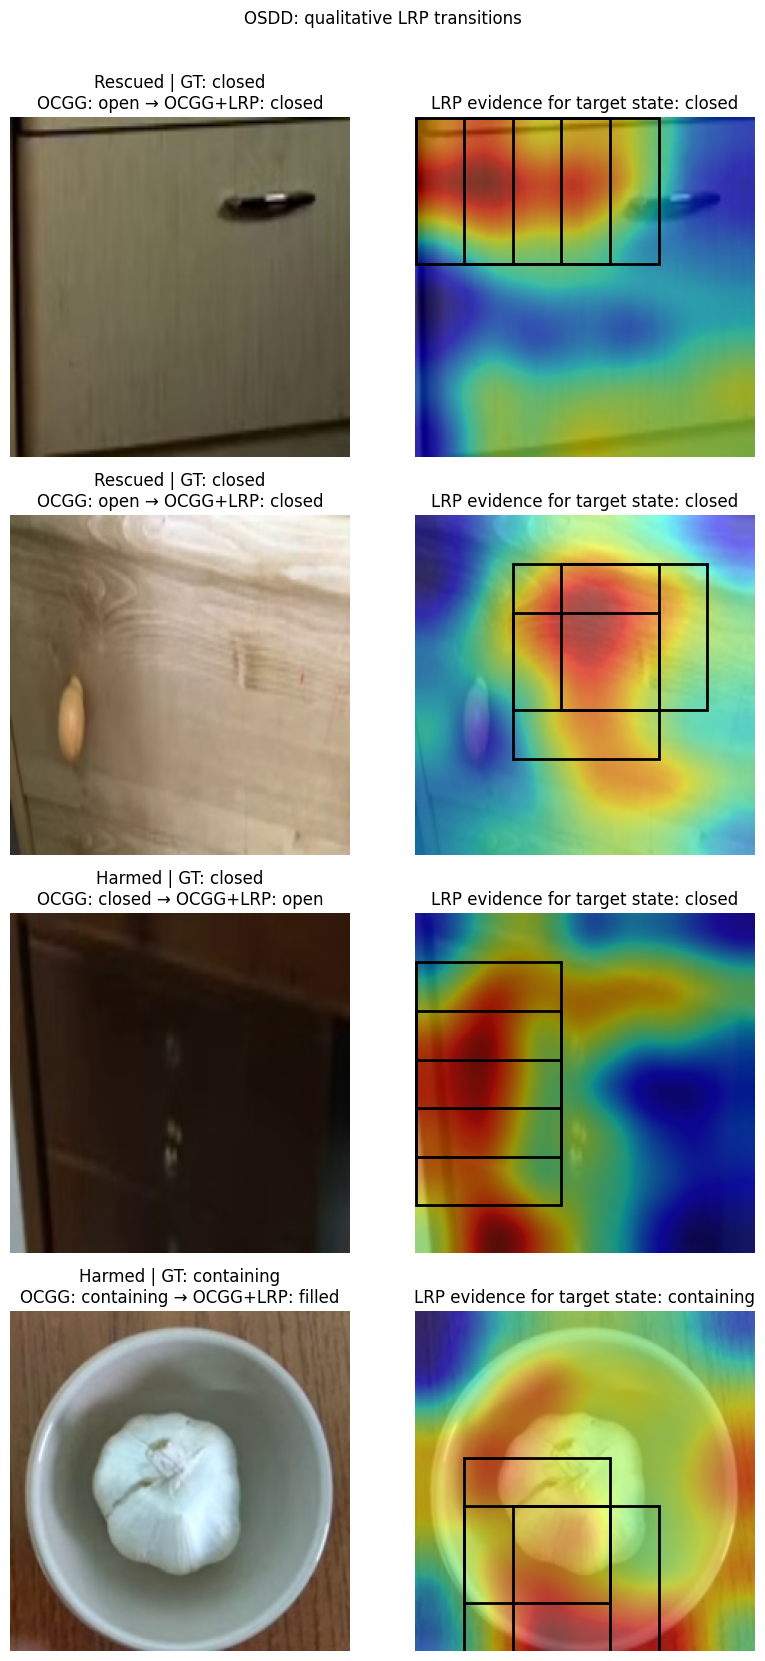

Saved: /kaggle/working/report_exports/figures/osdd_lrp_qualitative.png


In [ ]:
# ---- Original cell 46 ----
# ============================================================
# Shared qualitative LRP visualization helpers
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

REPORT_DIR = Path("/kaggle/working/report_exports")
FIG_DIR = REPORT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def calibrated_predictions(scores, gamma, unseen_ids):
    calibrated = scores.clone()
    calibrated[:, unseen_ids] += float(gamma)
    return calibrated.argmax(dim=1)


def fetch_images_by_index(loader, wanted_indices):
    wanted = set(int(i) for i in wanted_indices)
    found = {}
    cursor = 0
    for images, _ in loader:
        for j in range(len(images)):
            idx = cursor + j
            if idx in wanted:
                found[idx] = images[j].clone()
        cursor += len(images)
        if len(found) == len(wanted):
            break
    return found


def denormalize_image(x):
    img = x.detach().cpu() * IMAGENET_STD + IMAGENET_MEAN
    return img.clamp(0, 1).permute(1, 2, 0).numpy()


def lrp_heatmap_and_boxes(model, hook_cache, image_tensor, state_idx,
                          classifier_vectors, region_size=3, top_regions=3):
    device = next(model.parameters()).device
    x = image_tensor.unsqueeze(0).to(device)
    vectors = classifier_vectors.detach().to(device)
    w = vectors[state_idx, :-1]

    model.eval()
    with torch.inference_mode():
        _ = model(x)
        spatial = hook_cache["spatial"]
        patch = torch.einsum("bchw,c->bhw", spatial, w)[0]

    Hf, Wf = patch.shape
    region = F.avg_pool2d(
        patch[None, None], kernel_size=region_size, stride=1
    )[0, 0]
    flat = region.flatten()
    k = min(top_regions, flat.numel())
    top_idx = torch.topk(flat, k=k).indices

    # Positive evidence visualization; the quantitative LRP uses the raw scores.
    heat = torch.relu(patch)[None, None]
    heat = F.interpolate(
        heat,
        size=image_tensor.shape[-2:],
        mode="bicubic",
        align_corners=False,
    )[0, 0]
    heat = heat - heat.min()
    if heat.max() > 1e-8:
        heat = heat / heat.max()

    img_h, img_w = image_tensor.shape[-2:]
    boxes = []
    Wr = region.shape[1]
    for idx in top_idx.tolist():
        r, c = divmod(idx, Wr)
        boxes.append((
            c * img_w / Wf,
            r * img_h / Hf,
            region_size * img_w / Wf,
            region_size * img_h / Hf,
        ))

    return heat.cpu().numpy(), boxes


def plot_lrp_transition_examples(
    dataset_name,
    loader,
    model,
    hook_cache,
    class_names,
    classifier_vectors,
    targets,
    base_scores,
    lrp_scores,
    base_best,
    lrp_best,
    unseen_ids,
    output_path,
    max_rescued=2,
    max_harmed=2,
):
    base_pred = calibrated_predictions(
        base_scores, base_best["gamma"], unseen_ids
    )
    lrp_pred = calibrated_predictions(
        lrp_scores, lrp_best["gamma"], unseen_ids
    )

    rescued = torch.where((base_pred != targets) & (lrp_pred == targets))[0]
    harmed = torch.where((base_pred == targets) & (lrp_pred != targets))[0]

    chosen = []
    chosen += [(int(i), "Rescued") for i in rescued[:max_rescued]]
    chosen += [(int(i), "Harmed") for i in harmed[:max_harmed]]

    if not chosen:
        print(f"No transition examples found for {dataset_name}.")
        return None

    images = fetch_images_by_index(loader, [i for i, _ in chosen])
    fig, axes = plt.subplots(len(chosen), 2, figsize=(8.5, 4.1 * len(chosen)))
    if len(chosen) == 1:
        axes = np.array([axes])

    for row, (idx, effect) in enumerate(chosen):
        image_tensor = images[idx]
        gt_id = int(targets[idx])
        gt_name = class_names[gt_id]
        base_name = class_names[int(base_pred[idx])]
        lrp_name = class_names[int(lrp_pred[idx])]
        img_np = denormalize_image(image_tensor)
        heat, boxes = lrp_heatmap_and_boxes(
            model,
            hook_cache,
            image_tensor,
            gt_id,
            classifier_vectors,
            REGION_SIZE,
            TOP_REGIONS,
        )

        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title(
            f"{effect} | GT: {gt_name}\nOCGG: {base_name} → OCGG+LRP: {lrp_name}"
        )
        axes[row, 0].axis("off")

        axes[row, 1].imshow(img_np)
        axes[row, 1].imshow(heat, alpha=0.55, cmap="jet")
        for x0, y0, w0, h0 in boxes:
            axes[row, 1].add_patch(Rectangle(
                (x0, y0), w0, h0, fill=False, linewidth=2
            ))
        axes[row, 1].set_title(f"LRP evidence for target state: {gt_name}")
        axes[row, 1].axis("off")

    fig.suptitle(f"{dataset_name}: qualitative LRP transitions", y=1.01)
    plt.tight_layout()
    plt.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)
    return chosen

# ---- Original cell 47 ----
# OSDD qualitative examples
osdd_transition_examples = plot_lrp_transition_examples(
    dataset_name="OSDD",
    loader=osdd_test_loader,
    model=osdd_cnn,
    hook_cache=lrp_cache,
    class_names=OSDD_CLASSES,
    classifier_vectors=contrastive_vectors,
    targets=lrp_targets,
    base_scores=lrp_global_scores["OCGG"],
    lrp_scores=ocgg_lrp_locked_scores,
    base_best=contrastive_best,
    lrp_best=ocgg_lrp_locked_best,
    unseen_ids=osdd_unseen_ids,
    output_path=FIG_DIR / "osdd_lrp_qualitative.png",
)


## 6. MIT-States cross-dataset transfer

The same semantic pipeline is reused. The visual configuration is transferred directly from OSDD: **3×3 / top-3 / α = 0.20**.


In [ ]:
# ---- Original cell 49 ----
# ============================================================
# MIT-STATES — CHECK RELEASED FILES
# ============================================================

from pathlib import Path

MIT_ROOT = METHOD_DIR / "datasets/mit_states"
MIT_TEST_DIR = MIT_ROOT / "test"
MIT_TRAIN_DIR = MIT_ROOT / "train"
MIT_VAL_DIR = MIT_ROOT / "val"

MIT_EMB_PATH = METHOD_DIR / "embeddings/mit_emb.pred"
MIT_CKPT_DIR = METHOD_DIR / "saved_checkpoints/mit"

print("MIT root      :", MIT_ROOT, MIT_ROOT.exists())
print("MIT train     :", MIT_TRAIN_DIR, MIT_TRAIN_DIR.exists())
print("MIT val       :", MIT_VAL_DIR, MIT_VAL_DIR.exists())
print("MIT test      :", MIT_TEST_DIR, MIT_TEST_DIR.exists())
print("MIT embeddings:", MIT_EMB_PATH, MIT_EMB_PATH.exists())
print("MIT ckpt dir  :", MIT_CKPT_DIR, MIT_CKPT_DIR.exists())

print("\n===== CHECKPOINT FILES =====")

mit_checkpoint_candidates = [
    p for p in MIT_CKPT_DIR.rglob("*")
    if p.is_file()
]

for p in mit_checkpoint_candidates:
    print(p)

# ---- Original cell 50 ----
# ============================================================
# LOAD MIT OaSC STATE CLASSIFIERS
# ============================================================

import torch

GRAPH_TYPE = "conceptnet_wordnet_hop1_thresh_10"

def torch_load_compat(path, map_location="cpu"):
    try:
        return torch.load(
            path,
            map_location=map_location,
            weights_only=False
        )
    except TypeError:
        return torch.load(
            path,
            map_location=map_location
        )


MIT_CLASSES = [
    "closed",
    "empty",
    "filled",
    "folded",
    "open"
]

MIT_CLASS_TO_ID = {
    name: i
    for i, name in enumerate(MIT_CLASSES)
}


mit_emb_file = torch_load_compat(
    MIT_EMB_PATH
)

print("Embedding keys:")
print(mit_emb_file.keys())

raw_mit_vectors = (
    mit_emb_file[GRAPH_TYPE]
    .float()
)

print(
    "Raw released tensor:",
    raw_mit_vectors.shape
)


# Authors' test.py behavior
if len(raw_mit_vectors) > 5:

    MIT_FULL_VECTOR_INDICES = [
        0, 2, 3, 4, 5
    ]

    mit_state_vectors = (
        raw_mit_vectors[
            MIT_FULL_VECTOR_INDICES
        ]
    )

else:

    mit_state_vectors = (
        raw_mit_vectors
    )


print(
    "MIT classifier tensor:",
    mit_state_vectors.shape
)

assert mit_state_vectors.shape == (
    5,
    2049
)

for i, state in enumerate(MIT_CLASSES):
    print(
        i,
        state
    )

# ---- Original cell 51 ----
# ============================================================
# LOAD RELEASED MIT RESNET-101
# ============================================================

import torch.nn as nn
from torchvision.models import resnet101


preferred_ckpt = (
    MIT_CKPT_DIR
    / "finetuned_weights.pth"
)


if preferred_ckpt.exists():

    MIT_CKPT_PATH = preferred_ckpt

else:

    valid_candidates = [
        p
        for p in mit_checkpoint_candidates
        if p.suffix.lower()
        in {".pth", ".pt", ".ckpt"}
    ]

    if len(valid_candidates) != 1:

        print(
            "Please inspect these checkpoint candidates:"
        )

        for p in valid_candidates:
            print(p)

        raise RuntimeError(
            "Could not automatically choose MIT checkpoint."
        )

    MIT_CKPT_PATH = valid_candidates[0]


print(
    "Using checkpoint:",
    MIT_CKPT_PATH
)


try:

    cnn = resnet101(
        weights=None
    )

except TypeError:

    cnn = resnet101(
        pretrained=False
    )


cnn.fc = nn.Identity()


ckpt = torch_load_compat(
    MIT_CKPT_PATH
)


if (
    isinstance(ckpt, dict)
    and "state_dict" in ckpt
):

    ckpt = ckpt[
        "state_dict"
    ]


ckpt = {
    k.replace(
        "module.",
        ""
    ): v

    for k, v in ckpt.items()
}


ckpt.pop(
    "fc.weight",
    None
)

ckpt.pop(
    "fc.bias",
    None
)


missing, unexpected = (
    cnn.load_state_dict(
        ckpt,
        strict=False
    )
)


print(
    "Missing:",
    missing
)

print(
    "Unexpected:",
    unexpected
)


cnn = (
    cnn
    .to(DEVICE)
    .eval()
)

mit_state_vectors = (
    mit_state_vectors
    .to(DEVICE)
)

# ---- Original cell 52 ----
# ============================================================
# MIT-STATES DATASET + OFFICIAL GZSL SPLIT
# ============================================================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader


MIT_UNSEEN_NAMES = [
    "closed",
    "folded",
    "filled"
]


UNSEEN_IDS = [
    MIT_CLASS_TO_ID[x]
    for x in MIT_UNSEEN_NAMES
]


SEEN_IDS = [
    i
    for i in range(
        len(MIT_CLASSES)
    )
    if i not in UNSEEN_IDS
]


transform = transforms.Compose([
    transforms.Resize(
        [224, 224]
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


test_ds = datasets.ImageFolder(
    MIT_TEST_DIR,
    transform=transform
)


print(
    "ImageFolder classes:",
    test_ds.classes
)

print(
    "Test images:",
    len(test_ds)
)


folder_idx_to_global = {
    folder_idx:
        MIT_CLASS_TO_ID[state]

    for state, folder_idx
    in test_ds.class_to_idx.items()
}


print(
    "Seen:",
    [
        MIT_CLASSES[i]
        for i in SEEN_IDS
    ]
)

print(
    "Unseen:",
    [
        MIT_CLASSES[i]
        for i in UNSEEN_IDS
    ]
)

print(
    "Folder mapping:",
    folder_idx_to_global
)


test_loader = DataLoader(
    test_ds,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# ---- Original cell 53 ----
# Preserve MIT-specific objects for later cross-dataset figures.
mit_cnn = cnn
mit_test_ds = test_ds
mit_test_loader = test_loader
mit_folder_idx_to_global = dict(folder_idx_to_global)
mit_seen_ids = list(SEEN_IDS)
mit_unseen_ids = list(UNSEEN_IDS)

# ---- Original cell 54 ----
# ============================================================
# CACHE MIT TEST FEATURES
# ============================================================

import numpy as np
import pandas as pd
from tqdm.auto import tqdm


feature_batches = []
target_batches = []


cnn.eval()


with torch.inference_mode():

    for images, folder_labels in tqdm(
        test_loader,
        desc="Caching MIT-States features"
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        visual = cnn(
            images
        )


        visual_aug = torch.cat(
            [
                visual,

                torch.ones(
                    visual.shape[0],
                    1,
                    device=DEVICE
                )
            ],
            dim=1
        )


        targets = torch.tensor(
            [
                folder_idx_to_global[
                    int(x)
                ]
                for x in folder_labels
            ],
            dtype=torch.long
        )


        feature_batches.append(
            visual_aug.cpu()
        )

        target_batches.append(
            targets
        )


cached_test_features_aug = (
    torch.cat(
        feature_batches
    )
)

cached_test_targets = (
    torch.cat(
        target_batches
    )
)


print(
    cached_test_features_aug.shape
)

print(
    cached_test_targets.shape
)


MIT root      : /kaggle/working/OaSC_official/OaSC/datasets/mit_states True
MIT train     : /kaggle/working/OaSC_official/OaSC/datasets/mit_states/train True
MIT val       : /kaggle/working/OaSC_official/OaSC/datasets/mit_states/val True
MIT test      : /kaggle/working/OaSC_official/OaSC/datasets/mit_states/test True
MIT embeddings: /kaggle/working/OaSC_official/OaSC/embeddings/mit_emb.pred True
MIT ckpt dir  : /kaggle/working/OaSC_official/OaSC/saved_checkpoints/mit True

===== CHECKPOINT FILES =====
/kaggle/working/OaSC_official/OaSC/saved_checkpoints/mit/finetuned_weights.pth


Embedding keys:
dict_keys(['osdd2', 'osdd_ir_9_graph', 'osdd_wordnet_states', 'conceptnet_hop2_thresh_10', 'wordnet_states_hop2', 'conceptnet_hop1_thresh_10', 'conceptnet_hop1_thresh_0', 'conceptnet_wordnet_hop2_thresh_10', 'conceptnet_wordnet_hop1_thresh_0', 'conceptnet_wordnet_hop1_thresh_10', 'visualgenome_states_hops0', 'visualgenome_states_hops1', 'visualgenome_hops1'])
Raw released tensor: torch.Size([9, 2049])
MIT classifier tensor: torch.Size([5, 2049])
0 closed
1 empty
2 filled
3 folded
4 open


Using checkpoint: /kaggle/working/OaSC_official/OaSC/saved_checkpoints/mit/finetuned_weights.pth
Missing: []
Unexpected: []


ImageFolder classes: ['closed', 'empty', 'filled', 'folded', 'open']
Test images: 354
Seen: ['empty', 'open']
Unseen: ['closed', 'folded', 'filled']
Folder mapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}


torch.Size([354, 2049])
torch.Size([354])


In [ ]:
# ---- Original cell 55 ----
# ============================================================
# MIT GZSL EVALUATION
# ============================================================

gammas = np.arange(
    -5.0,
    15.125,
    0.5
)


def evaluate_gamma(
    scores,
    targets,
    gamma
):

    calibrated = (
        scores.clone()
    )

    calibrated[
        :,
        UNSEEN_IDS
    ] += float(gamma)


    pred = calibrated.argmax(
        dim=1
    )


    seen_mask = torch.tensor(
        [
            int(y) in SEEN_IDS
            for y in targets
        ],
        dtype=torch.bool
    )


    unseen_mask = (
        ~seen_mask
    )


    seen_acc = (
        (
            pred[seen_mask]
            ==
            targets[seen_mask]
        )
        .float()
        .mean()
        .item()
    )


    unseen_acc = (
        (
            pred[unseen_mask]
            ==
            targets[unseen_mask]
        )
        .float()
        .mean()
        .item()
    )


    hm = (
        0.0
        if seen_acc + unseen_acc == 0
        else
        2
        * seen_acc
        * unseen_acc
        /
        (
            seen_acc
            + unseen_acc
        )
    )


    total = (
        (pred == targets)
        .float()
        .mean()
        .item()
    )


    return (
        total,
        seen_acc,
        unseen_acc,
        hm
    )


def evaluate_score_matrix(
    score_matrix,
    targets,
    method
):

    rows = []


    for gamma in gammas:

        total, seen, unseen, hm = (
            evaluate_gamma(
                score_matrix,
                targets,
                gamma
            )
        )


        rows.append({
            "gamma": gamma,
            "total_acc": total,
            "seen_acc": seen,
            "unseen_acc": unseen,
            "harmonic_mean": hm
        })


    df = pd.DataFrame(
        rows
    )


    best = df.loc[
        df[
            "harmonic_mean"
        ].idxmax()
    ]


    try:

        auc = np.trapezoid(
            df["seen_acc"],
            df["unseen_acc"]
        )

    except AttributeError:

        auc = np.trapz(
            df["seen_acc"],
            df["unseen_acc"]
        )


    print(
        "\n=============================================="
    )

    print(method)

    print(
        "=============================================="
    )

    print(
        f"Best gamma       : "
        f"{best['gamma']:.2f}"
    )

    print(
        f"Seen @ best HM   : "
        f"{100*best['seen_acc']:.2f}%"
    )

    print(
        f"Unseen @ best HM : "
        f"{100*best['unseen_acc']:.2f}%"
    )

    print(
        f"Best HM          : "
        f"{100*best['harmonic_mean']:.2f}%"
    )

    print(
        f"Max seen acc     : "
        f"{100*df['seen_acc'].max():.2f}%"
    )

    print(
        f"Max unseen acc   : "
        f"{100*df['unseen_acc'].max():.2f}%"
    )

    print(
        f"AUC              : "
        f"{100*auc:.2f}"
    )


    return df, best, auc

# ---- Original cell 56 ----
# ============================================================
# RELEASED MIT OaSC BASELINE
# ============================================================

baseline_scores = (
    cached_test_features_aug.float()
    @
    mit_state_vectors.detach().cpu().float().T
)


mit_results, mit_best, mit_auc = (
    evaluate_score_matrix(
        baseline_scores,
        cached_test_targets,
        "ORIGINAL OaSC — MIT-STATES"
    )
)



ORIGINAL OaSC — MIT-STATES
Best gamma       : 0.00
Seen @ best HM   : 47.62%
Unseen @ best HM : 55.77%
Best HM          : 51.37%
Max seen acc     : 85.71%
Max unseen acc   : 69.87%
AUC              : 40.99


In [ ]:
# ---- Original cell 57 ----
required = [
    "g",
    "rw_adj_lists",
    "state_node_ids",
    "state_clip_features",
    "clip_node_features",
    "trgcn_predict_nodes",
]

for name in required:
    assert name in globals(), f"Missing: {name}"

print("✓ KG + CLIP + Tr-GCN setup ready")

# ---- Original cell 58 ----
# ============================================================
# MIT — SAME AMBIGUITY-ADAPTIVE WEIGHTS AS OSDD
# ============================================================

import copy
import math
import torch
import pandas as pd


REFERENCE_STATES = [
    "closed",
    "containing",
    "empty",
    "filled",
    "folded",
    "open",
    "plugged",
    "unfolded",
    "unplugged",
]


def deduplicate_neighbors(items):

    best = {}

    for item in items:

        nid = int(item[0])
        rw = float(item[-1])

        if nid not in best or rw > float(best[nid][-1]):
            best[nid] = item

    return list(best.values())


def minmax01(values):

    x = torch.tensor(
        values,
        dtype=torch.float32
    )

    if len(x) == 0:
        return x

    if x.max() > x.min():

        return (
            x - x.min()
        ) / (
            x.max() - x.min()
        )

    return torch.ones_like(x)


# ------------------------------------------------------------
# Same ambiguity definition used on OSDD
# ------------------------------------------------------------

neighbor_counts = {}

for state in REFERENCE_STATES:

    sid = state_node_ids[state]

    unique_items = deduplicate_neighbors(
        rw_adj_lists[sid]
    )

    neighbor_counts[state] = len(unique_items)


N_MAX = max(
    neighbor_counts.values()
)


state_ambiguity = {}
state_clip_weights = {}


LAMBDA_MIN = 0.40
LAMBDA_MAX = 0.90


for state in REFERENCE_STATES:

    sid = state_node_ids[state]

    items = deduplicate_neighbors(
        rw_adj_lists[sid]
    )

    n = len(items)


    if n <= 1:

        ambiguity = 0.0

    else:

        rw = torch.tensor(
            [
                max(
                    float(item[-1]),
                    0.0
                )
                for item in items
            ],
            dtype=torch.float32
        )


        if rw.sum() <= 0:

            entropy_norm = 0.0

        else:

            p = (
                rw
                /
                rw.sum()
            )

            entropy = -(
                p
                *
                torch.log(
                    p + 1e-12
                )
            ).sum().item()


            entropy_norm = (
                entropy
                /
                math.log(n)
            )


        size_factor = (
            math.log1p(n)
            /
            math.log1p(N_MAX)
        )


        ambiguity = (
            entropy_norm
            *
            size_factor
        )


    state_ambiguity[state] = ambiguity


    state_clip_weights[state] = (
        LAMBDA_MIN
        +
        ambiguity
        *
        (
            LAMBDA_MAX
            -
            LAMBDA_MIN
        )
    )


display(
    pd.DataFrame([
        {
            "State": s,
            "Neighbors": neighbor_counts[s],
            "Ambiguity": state_ambiguity[s],
            "Semantic weight": state_clip_weights[s],
        }
        for s in REFERENCE_STATES
    ]).round(3)
)

# ---- Original cell 59 ----
# ============================================================
# MIT — BUILD FIXED / ADAPTIVE / OCGG GRAPHS
# ============================================================

MIT_GRAPH_STATES = [
    "closed",
    "empty",
    "filled",
    "folded",
    "open",

    # auxiliary only; required as folded's opposite
    "unfolded",
]


OPPOSITE_STATE = {

    "open": "closed",
    "closed": "open",

    "empty": "filled",
    "filled": "empty",

    "folded": "unfolded",
    "unfolded": "folded",
}


def build_mit_semantic_graph(mode):

    """
    mode:
        fixed
        adaptive
        ocgg
    """

    modified_rw = copy.deepcopy(
        rw_adj_lists
    )


    for state in MIT_GRAPH_STATES:

        sid = state_node_ids[state]


        items = deduplicate_neighbors(
            rw_adj_lists[sid]
        )


        if len(items) == 0:
            continue


        # ====================================================
        # KG structural score
        # ====================================================

        rw_raw = [
            float(item[-1])
            for item in items
        ]

        rw_norm = minmax01(
            rw_raw
        )


        # ====================================================
        # CLIP semantic score
        # ====================================================

        target_feature = (
            state_clip_features[state]
            .cpu()
        )


        semantic_raw = []


        for item in items:

            nid = int(
                item[0]
            )

            neighbor_feature = (
                clip_node_features[nid]
                .cpu()
            )


            target_sim = torch.dot(
                target_feature,
                neighbor_feature
            ).item()


            # -----------------------------------------------
            # OCGG:
            # target similarity - opposite similarity
            # -----------------------------------------------

            if mode == "ocgg":

                opposite = (
                    OPPOSITE_STATE[state]
                )

                opposite_feature = (
                    state_clip_features[
                        opposite
                    ]
                    .cpu()
                )


                opposite_sim = torch.dot(
                    opposite_feature,
                    neighbor_feature
                ).item()


                semantic_raw.append(
                    target_sim
                    -
                    opposite_sim
                )


            # -----------------------------------------------
            # Fixed / adaptive:
            # absolute state similarity
            # -----------------------------------------------

            else:

                semantic_raw.append(
                    target_sim
                )


        semantic_norm = minmax01(
            semantic_raw
        )


        # ====================================================
        # Fusion weight
        # ====================================================

        if mode == "fixed":

            semantic_weight = 0.80

        else:

            semantic_weight = float(
                state_clip_weights[state]
            )


        kg_weight = (
            1.0
            -
            semantic_weight
        )


        combined = (
            kg_weight
            *
            rw_norm

            +

            semantic_weight
            *
            semantic_norm
        )


        # ====================================================
        # Replace ranking score
        # ====================================================

        reranked = []


        for item, score in zip(
            items,
            combined
        ):

            item_new = list(
                item
            )

            item_new[-1] = float(
                score
            )

            reranked.append(
                tuple(item_new)
            )


        reranked.sort(
            key=lambda x: x[-1],
            reverse=True
        )


        # IMPORTANT:
        # no pre-truncation
        modified_rw[
            sid
        ] = reranked


    graph = copy.deepcopy(g)

    graph[
        "rw_adj_lists"
    ] = modified_rw


    return graph


mit_fixed_graph = (
    build_mit_semantic_graph(
        "fixed"
    )
)

mit_adaptive_graph = (
    build_mit_semantic_graph(
        "adaptive"
    )
)

mit_ocgg_graph = (
    build_mit_semantic_graph(
        "ocgg"
    )
)


print("✓ MIT semantic graphs built")

# ---- Original cell 60 ----
# ============================================================
# MIT — generate Tr-GCN classifier variants
# ============================================================

MIT_STATE_NODE_IDS = [state_node_ids[state] for state in MIT_CLASSES]

with torch.inference_mode():
    mit_fixed_vectors = trgcn_predict_nodes(MIT_STATE_NODE_IDS, mit_fixed_graph)
    mit_adaptive_vectors = trgcn_predict_nodes(MIT_STATE_NODE_IDS, mit_adaptive_graph)
    mit_ocgg_vectors = trgcn_predict_nodes(MIT_STATE_NODE_IDS, mit_ocgg_graph)

print("Fixed   :", mit_fixed_vectors.shape)
print("Adaptive:", mit_adaptive_vectors.shape)
print("OCGG    :", mit_ocgg_vectors.shape)

# ---- Original cell 61 ----
# ============================================================
# MIT — EVALUATE ALL GRAPH VARIANTS
# Run this BEFORE the final table
# ============================================================

required_vectors = [
    "mit_fixed_vectors",
    "mit_adaptive_vectors",
    "mit_ocgg_vectors",
]

for name in required_vectors:
    assert name in globals(), (
        f"{name} is missing. "
        "Run the graph-building + Tr-GCN generation cells first."
    )


def scores_from_vectors_mit(vectors):
    return (
        cached_test_features_aug.float()
        @
        vectors.detach().cpu().float().T
    )


# ------------------------------------------------------------
# Fixed CLIP KG
# ------------------------------------------------------------

mit_fixed_scores = scores_from_vectors_mit(
    mit_fixed_vectors
)

mit_fixed_results, mit_fixed_best, mit_fixed_auc = (
    evaluate_score_matrix(
        mit_fixed_scores,
        cached_test_targets,
        "FIXED CLIP KG — MIT"
    )
)


# ------------------------------------------------------------
# Adaptive CLIP KG
# ------------------------------------------------------------

mit_adaptive_scores = scores_from_vectors_mit(
    mit_adaptive_vectors
)

mit_adaptive_results, mit_adaptive_best, mit_adaptive_auc = (
    evaluate_score_matrix(
        mit_adaptive_scores,
        cached_test_targets,
        "ADAPTIVE CLIP KG — MIT"
    )
)


# ------------------------------------------------------------
# OCGG
# ------------------------------------------------------------

mit_ocgg_scores = scores_from_vectors_mit(
    mit_ocgg_vectors
)

mit_ocgg_results, mit_ocgg_best, mit_ocgg_auc = (
    evaluate_score_matrix(
        mit_ocgg_scores,
        cached_test_targets,
        "OCGG — MIT"
    )
)


print("\n✓ All MIT graph variants evaluated")


✓ KG + CLIP + Tr-GCN setup ready


,State,Neighbors,Ambiguity,Semantic weight
0,closed,72,0.744,0.772
1,containing,28,0.622,0.711
2,empty,82,0.807,0.803
3,filled,21,0.574,0.687
4,folded,23,0.588,0.694
5,open,192,0.945,0.872
6,plugged,2,0.207,0.504
7,unfolded,1,0.000,0.400
8,unplugged,2,0.208,0.504


✓ MIT semantic graphs built


Fixed   : torch.Size([5, 2049])
Adaptive: torch.Size([5, 2049])
OCGG    : torch.Size([5, 2049])



FIXED CLIP KG — MIT
Best gamma       : -0.50
Seen @ best HM   : 57.14%
Unseen @ best HM : 52.24%
Best HM          : 54.58%
Max seen acc     : 85.71%
Max unseen acc   : 75.00%
AUC              : 45.57

ADAPTIVE CLIP KG — MIT
Best gamma       : -0.50
Seen @ best HM   : 57.14%
Unseen @ best HM : 51.92%
Best HM          : 54.41%
Max seen acc     : 85.71%
Max unseen acc   : 75.00%
AUC              : 45.50

OCGG — MIT
Best gamma       : -1.00
Seen @ best HM   : 66.67%
Unseen @ best HM : 44.87%
Best HM          : 53.64%
Max seen acc     : 83.33%
Max unseen acc   : 75.00%
AUC              : 43.47

✓ All MIT graph variants evaluated


In [ ]:
# ---- Original cell 62 ----
# ============================================================
# MIT — layer4 spatial feature hook + GAP verification
# ============================================================

if "mit_lrp_hook_handle" in globals():
    try:
        mit_lrp_hook_handle.remove()
    except Exception:
        pass

mit_lrp_cache = {}

def mit_lrp_hook(module, inp, out):
    mit_lrp_cache["spatial"] = out

backbone = cnn.module if hasattr(cnn, "module") else cnn
mit_lrp_hook_handle = backbone.layer4.register_forward_hook(mit_lrp_hook)

images, _ = next(iter(test_loader))
images = images.to(DEVICE)

with torch.inference_mode():
    pooled = cnn(images)
    spatial = mit_lrp_cache["spatial"]

spatial_mean = spatial.mean(dim=(-2, -1))
print("Spatial:", spatial.shape)
print("Mean cosine:", F.cosine_similarity(pooled, spatial_mean, dim=1).mean().item())
print("Mean absolute difference:", (pooled - spatial_mean).abs().mean().item())

# ---- Original cell 63 ----
# ============================================================
# MIT-STATES — LOCKED LOCAL REGION POOLING TRANSFER
#
# Hyperparameters FIXED from OSDD:
#   region size = 3x3
#   top regions = 3
#   alpha       = 0.20
#
# IMPORTANT:
# No alpha tuning on MIT-States.
#
# Evaluate:
#   1. Original OaSC
#   2. Original OaSC + LRP
#   3. OCGG
#   4. OCGG + LRP
# ============================================================

REGION_SIZE = 3
TOP_REGIONS = 3
LOCAL_ALPHA = FINAL_ALPHA


# ------------------------------------------------------------
# Classifiers
# ------------------------------------------------------------

mit_lrp_classifiers = {

    "OaSC":
        mit_state_vectors
        .detach()
        .to(DEVICE),

    "OCGG":
        mit_ocgg_vectors
        .detach()
        .to(DEVICE),
}


mit_lrp_global_batches = {
    name: []
    for name in mit_lrp_classifiers
}

mit_lrp_gain_batches = {
    name: []
    for name in mit_lrp_classifiers
}

mit_lrp_target_batches = []


cnn.eval()


with torch.inference_mode():

    for images, labels in tqdm(
        test_loader,
        desc="MIT locked LRP transfer"
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )


        # ====================================================
        # One backbone forward pass
        # ====================================================

        pooled = cnn(images)

        spatial = (
            mit_lrp_cache["spatial"]
        )


        # ====================================================
        # Apply both classifier sets
        # ====================================================

        for method_name, vectors in (
            mit_lrp_classifiers.items()
        ):

            weights = vectors[:, :-1]
            bias = vectors[:, -1]


            # -----------------------------------------------
            # Global classifier score
            # -----------------------------------------------

            global_scores = (
                pooled @ weights.T
                +
                bias.unsqueeze(0)
            )


            # -----------------------------------------------
            # Spatial state evidence
            #
            # [B,2048,7,7] x [S,2048]
            #          -> [B,S,7,7]
            # -----------------------------------------------

            patch_scores = torch.einsum(
                "bchw,sc->bshw",
                spatial,
                weights
            )


            B, S, H, W = patch_scores.shape


            # -----------------------------------------------
            # 3x3 coherent region pooling
            # -----------------------------------------------

            region_scores = F.avg_pool2d(

                patch_scores.reshape(
                    B * S,
                    1,
                    H,
                    W
                ),

                kernel_size=REGION_SIZE,
                stride=1
            )


            Hr, Wr = region_scores.shape[-2:]


            region_scores = (
                region_scores.reshape(
                    B,
                    S,
                    Hr * Wr
                )
            )


            k = min(
                TOP_REGIONS,
                Hr * Wr
            )


            local_score = torch.topk(
                region_scores,
                k=k,
                dim=-1
            ).values.mean(
                dim=-1
            )


            # -----------------------------------------------
            # Evidence already represented by GAP
            # -----------------------------------------------

            global_visual_score = (
                patch_scores.mean(
                    dim=(-2, -1)
                )
            )


            # -----------------------------------------------
            # LRP residual
            # -----------------------------------------------

            localization_gain = (
                local_score
                -
                global_visual_score
            )


            mit_lrp_global_batches[
                method_name
            ].append(
                global_scores.cpu()
            )


            mit_lrp_gain_batches[
                method_name
            ].append(
                localization_gain.cpu()
            )


        # ====================================================
        # Targets
        # ====================================================

        batch_targets = torch.tensor(
            [
                folder_idx_to_global[int(x)]
                for x in labels
            ],
            dtype=torch.long
        )


        mit_lrp_target_batches.append(
            batch_targets
        )


# ============================================================
# CONCATENATE
# ============================================================

mit_lrp_targets = torch.cat(
    mit_lrp_target_batches
)


mit_lrp_global_scores = {

    name: torch.cat(batches)

    for name, batches
    in mit_lrp_global_batches.items()
}


mit_lrp_gains = {

    name: torch.cat(batches)

    for name, batches
    in mit_lrp_gain_batches.items()
}


assert torch.equal(
    mit_lrp_targets,
    cached_test_targets
)


# ============================================================
# LOCKED alpha = 0.20
# ============================================================

mit_oasc_lrp_scores = (

    mit_lrp_global_scores["OaSC"]

    +

    LOCAL_ALPHA
    *
    mit_lrp_gains["OaSC"]
)


mit_ocgg_lrp_scores = (

    mit_lrp_global_scores["OCGG"]

    +

    LOCAL_ALPHA
    *
    mit_lrp_gains["OCGG"]
)


print("MIT LRP inference complete.")
print("Locked alpha:", LOCAL_ALPHA)

# ---- Original cell 64 ----
# ============================================================
# MIT — LOCKED TRANSFER EVALUATION
# ============================================================


# ------------------------------------------------------------
# Original OaSC
# ------------------------------------------------------------

mit_oasc_results, mit_oasc_best, mit_oasc_auc = (
    evaluate_score_matrix(
        mit_lrp_global_scores["OaSC"],
        mit_lrp_targets,
        "Original OaSC — MIT"
    )
)


# ------------------------------------------------------------
# Original OaSC + LRP
# ------------------------------------------------------------

mit_oasc_lrp_results, mit_oasc_lrp_best, mit_oasc_lrp_auc = (
    evaluate_score_matrix(
        mit_oasc_lrp_scores,
        mit_lrp_targets,
        "Original OaSC + LRP (alpha=0.20) — MIT"
    )
)


# ------------------------------------------------------------
# OCGG
# ------------------------------------------------------------

mit_ocgg_transfer_results, mit_ocgg_transfer_best, mit_ocgg_transfer_auc = (
    evaluate_score_matrix(
        mit_lrp_global_scores["OCGG"],
        mit_lrp_targets,
        "OCGG — MIT"
    )
)


# ------------------------------------------------------------
# OCGG + LRP
# ------------------------------------------------------------

mit_ocgg_lrp_results, mit_ocgg_lrp_best, mit_ocgg_lrp_auc = (
    evaluate_score_matrix(
        mit_ocgg_lrp_scores,
        mit_lrp_targets,
        "OCGG + LRP (alpha=0.20) — MIT"
    )
)

# ---- Original cell 65 ----
# ============================================================
# MIT — final locked four-way ablation
# ============================================================

mit_main_table = pd.DataFrame([
    {
        "Method": "Original OaSC",
        "Best Gamma": mit_oasc_best["gamma"],
        "Seen @ Best HM": 100 * mit_oasc_best["seen_acc"],
        "Unseen @ Best HM": 100 * mit_oasc_best["unseen_acc"],
        "Best HM": 100 * mit_oasc_best["harmonic_mean"],
        "Max Unseen": 100 * mit_oasc_results["unseen_acc"].max(),
        "AUC": 100 * mit_oasc_auc,
    },
    {
        "Method": f"OaSC + LRP (α={FINAL_ALPHA:.2f})",
        "Best Gamma": mit_oasc_lrp_best["gamma"],
        "Seen @ Best HM": 100 * mit_oasc_lrp_best["seen_acc"],
        "Unseen @ Best HM": 100 * mit_oasc_lrp_best["unseen_acc"],
        "Best HM": 100 * mit_oasc_lrp_best["harmonic_mean"],
        "Max Unseen": 100 * mit_oasc_lrp_results["unseen_acc"].max(),
        "AUC": 100 * mit_oasc_lrp_auc,
    },
    {
        "Method": "OCGG",
        "Best Gamma": mit_ocgg_transfer_best["gamma"],
        "Seen @ Best HM": 100 * mit_ocgg_transfer_best["seen_acc"],
        "Unseen @ Best HM": 100 * mit_ocgg_transfer_best["unseen_acc"],
        "Best HM": 100 * mit_ocgg_transfer_best["harmonic_mean"],
        "Max Unseen": 100 * mit_ocgg_transfer_results["unseen_acc"].max(),
        "AUC": 100 * mit_ocgg_transfer_auc,
    },
    {
        "Method": f"OCGG + LRP (α={FINAL_ALPHA:.2f})",
        "Best Gamma": mit_ocgg_lrp_best["gamma"],
        "Seen @ Best HM": 100 * mit_ocgg_lrp_best["seen_acc"],
        "Unseen @ Best HM": 100 * mit_ocgg_lrp_best["unseen_acc"],
        "Best HM": 100 * mit_ocgg_lrp_best["harmonic_mean"],
        "Max Unseen": 100 * mit_ocgg_lrp_results["unseen_acc"].max(),
        "AUC": 100 * mit_ocgg_lrp_auc,
    },
])

print("\nFINAL MIT-STATES ABLATION (OSDD-locked α=0.20)")
display(mit_main_table.round(2))


Spatial: torch.Size([128, 2048, 7, 7])
Mean cosine: 1.0
Mean absolute difference: 0.0


MIT LRP inference complete.
Locked alpha: 0.2



Original OaSC — MIT
Best gamma       : 0.00
Seen @ best HM   : 47.62%
Unseen @ best HM : 55.77%
Best HM          : 51.37%
Max seen acc     : 85.71%
Max unseen acc   : 69.87%
AUC              : 40.99

Original OaSC + LRP (alpha=0.20) — MIT
Best gamma       : 0.00
Seen @ best HM   : 47.62%
Unseen @ best HM : 54.17%
Best HM          : 50.68%
Max seen acc     : 88.10%
Max unseen acc   : 69.87%
AUC              : 39.87

OCGG — MIT
Best gamma       : -1.00
Seen @ best HM   : 66.67%
Unseen @ best HM : 44.87%
Best HM          : 53.64%
Max seen acc     : 83.33%
Max unseen acc   : 75.00%
AUC              : 43.47

OCGG + LRP (alpha=0.20) — MIT
Best gamma       : -0.50
Seen @ best HM   : 61.90%
Unseen @ best HM : 53.21%
Best HM          : 57.23%
Max seen acc     : 88.10%
Max unseen acc   : 75.64%
AUC              : 46.33



FINAL MIT-STATES ABLATION (OSDD-locked α=0.20)


,Method,Best Gamma,Seen @ Best HM,Unseen @ Best HM,Best HM,Max Unseen,AUC
0,Original OaSC,0.0,47.62,55.77,51.37,69.87,40.99
1,OaSC + LRP (α=0.20),0.0,47.62,54.17,50.68,69.87,39.87
2,OCGG,-1.0,66.67,44.87,53.64,75.00,43.47
3,OCGG + LRP (α=0.20),-0.5,61.90,53.21,57.23,75.64,46.33


### 6.1 MIT-States qualitative LRP analysis


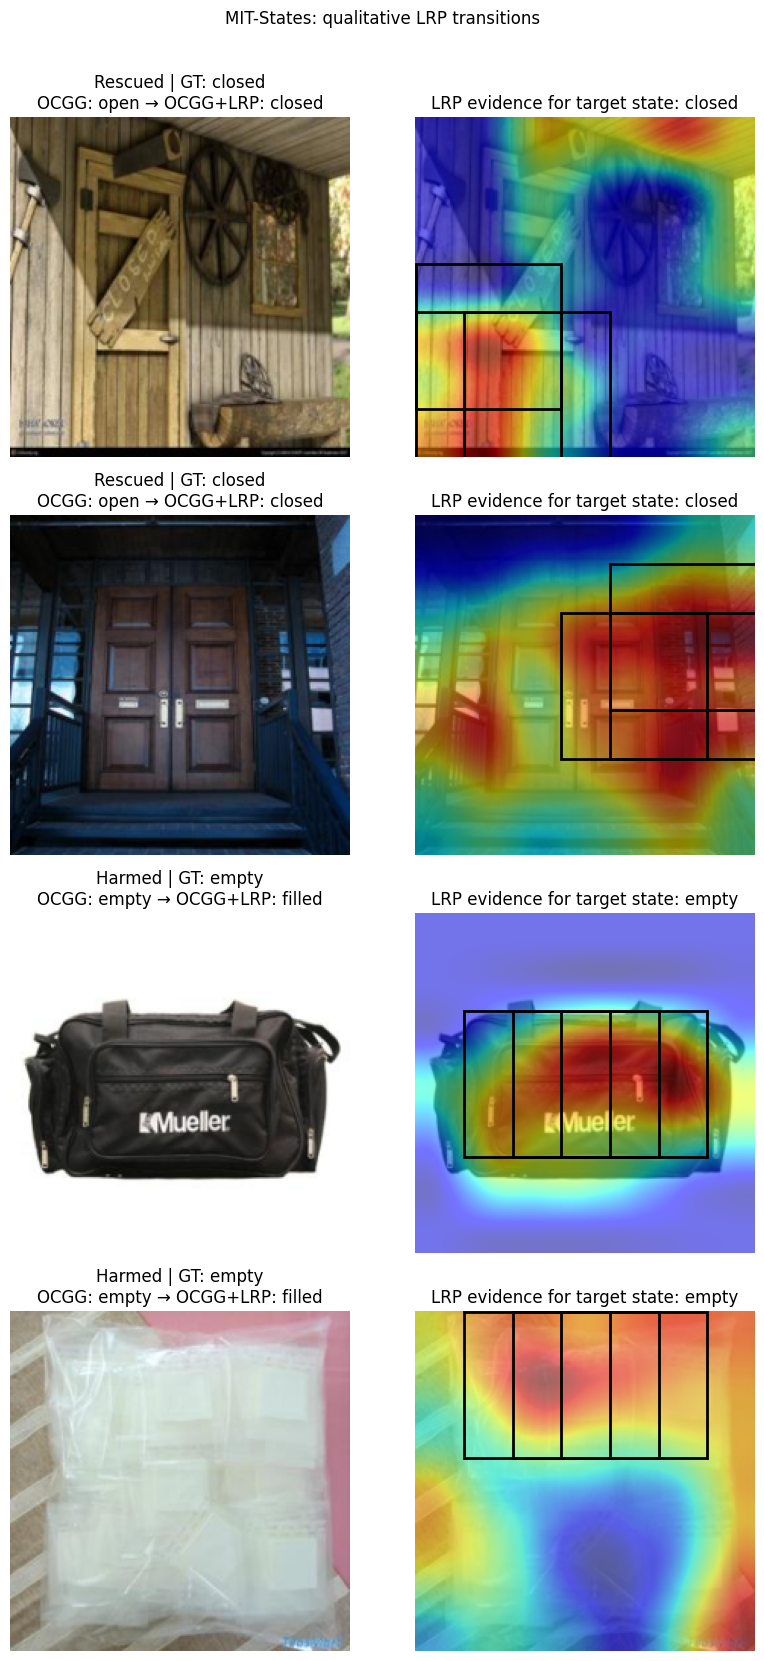

Saved: /kaggle/working/report_exports/figures/mit_lrp_qualitative.png


In [ ]:
# ---- Original cell 67 ----
mit_transition_examples = plot_lrp_transition_examples(
    dataset_name="MIT-States",
    loader=mit_test_loader,
    model=mit_cnn,
    hook_cache=mit_lrp_cache,
    class_names=MIT_CLASSES,
    classifier_vectors=mit_ocgg_vectors,
    targets=mit_lrp_targets,
    base_scores=mit_lrp_global_scores["OCGG"],
    lrp_scores=mit_ocgg_lrp_scores,
    base_best=mit_ocgg_transfer_best,
    lrp_best=mit_ocgg_lrp_best,
    unseen_ids=mit_unseen_ids,
    output_path=FIG_DIR / "mit_lrp_qualitative.png",
)


## 7. Final report tables and quantitative figures

This section contains the cross-dataset main table, deltas, semantic ablations, per-state effects, calibration curves, α sensitivity, metric comparisons, and OCGG–LRP interaction plots.


In [ ]:
# ---- Original cell 69 ----
# ============================================================
# Report helper tables
# ============================================================

def make_delta_table(df):
    base = df.iloc[0]
    rows = []
    for _, row in df.iterrows():
        rows.append({
            "Method": row["Method"],
            "Δ Best HM vs OaSC": row["Best HM"] - base["Best HM"],
            "Δ Max Unseen vs OaSC": row["Max Unseen"] - base["Max Unseen"],
            "Δ AUC vs OaSC": row["AUC"] - base["AUC"],
        })
    return pd.DataFrame(rows)

osdd_delta_table = make_delta_table(osdd_main_table)
mit_delta_table = make_delta_table(mit_main_table)


cross_dataset_main = pd.concat([
    osdd_main_table.assign(Dataset="OSDD"),
    mit_main_table.assign(Dataset="MIT-States"),
], ignore_index=True)

# Put Dataset first for report readability.
cross_dataset_main = cross_dataset_main[[
    "Dataset", "Method", "Best Gamma", "Seen @ Best HM",
    "Unseen @ Best HM", "Best HM", "Max Unseen", "AUC"
]]

print("CROSS-DATASET MAIN TABLE")
display(cross_dataset_main.round(2))

print("OSDD MAIN TABLE")
display(osdd_main_table.round(2))
print("OSDD DELTAS")
display(osdd_delta_table.round(2))

print("MIT-STATES MAIN TABLE")
display(mit_main_table.round(2))
print("MIT-STATES DELTAS")
display(mit_delta_table.round(2))

print("OSDD SEMANTIC GRAPH ABLATION")
display(kg_ablation.round(2))

mit_graph_table = pd.DataFrame([
    {
        "Method": "Original OaSC",
        "Best HM": 100 * mit_best["harmonic_mean"],
        "Max Unseen": 100 * mit_results["unseen_acc"].max(),
        "AUC": 100 * mit_auc,
    },
    {
        "Method": "Fixed CLIP KG",
        "Best HM": 100 * mit_fixed_best["harmonic_mean"],
        "Max Unseen": 100 * mit_fixed_results["unseen_acc"].max(),
        "AUC": 100 * mit_fixed_auc,
    },
    {
        "Method": "Adaptive CLIP KG",
        "Best HM": 100 * mit_adaptive_best["harmonic_mean"],
        "Max Unseen": 100 * mit_adaptive_results["unseen_acc"].max(),
        "AUC": 100 * mit_adaptive_auc,
    },
    {
        "Method": "OCGG",
        "Best HM": 100 * mit_ocgg_best["harmonic_mean"],
        "Max Unseen": 100 * mit_ocgg_results["unseen_acc"].max(),
        "AUC": 100 * mit_ocgg_auc,
    },
])
print("MIT-STATES SEMANTIC GRAPH ABLATION")
display(mit_graph_table.round(2))

# ---- Original cell 70 ----
# ============================================================
# Per-state OCGG -> OCGG+LRP analysis
# ============================================================

def per_state_comparison(class_names, targets, base_scores, base_best,
                         lrp_scores, lrp_best, unseen_ids):
    base_pred = calibrated_predictions(base_scores, base_best["gamma"], unseen_ids)
    lrp_pred = calibrated_predictions(lrp_scores, lrp_best["gamma"], unseen_ids)
    rows = []
    for sid, state in enumerate(class_names):
        mask = targets == sid
        n = int(mask.sum())
        base_acc = float((base_pred[mask] == targets[mask]).float().mean()) if n else float("nan")
        lrp_acc = float((lrp_pred[mask] == targets[mask]).float().mean()) if n else float("nan")
        rows.append({
            "State": state,
            "Count": n,
            "Split": "Unseen" if sid in unseen_ids else "Seen",
            "OCGG Accuracy": 100 * base_acc,
            "OCGG + LRP Accuracy": 100 * lrp_acc,
            "Δ Accuracy (pp)": 100 * (lrp_acc - base_acc),
        })
    return pd.DataFrame(rows)

osdd_per_state = per_state_comparison(
    OSDD_CLASSES, lrp_targets,
    lrp_global_scores["OCGG"], contrastive_best,
    ocgg_lrp_locked_scores, ocgg_lrp_locked_best,
    osdd_unseen_ids,
)

mit_per_state = per_state_comparison(
    MIT_CLASSES, mit_lrp_targets,
    mit_lrp_global_scores["OCGG"], mit_ocgg_transfer_best,
    mit_ocgg_lrp_scores, mit_ocgg_lrp_best,
    mit_unseen_ids,
)

print("OSDD PER-STATE")
display(osdd_per_state.sort_values("Δ Accuracy (pp)", ascending=False).round(2))
print("MIT-STATES PER-STATE")
display(mit_per_state.sort_values("Δ Accuracy (pp)", ascending=False).round(2))


CROSS-DATASET MAIN TABLE


,Dataset,Method,Best Gamma,Seen @ Best HM,Unseen @ Best HM,Best HM,Max Unseen,AUC
0,OSDD,Original OaSC,2.5,44.68,56.93,50.07,64.82,40.16
1,OSDD,OaSC + LRP (α=0.20),2.5,46.51,54.74,50.29,65.66,40.52
2,OSDD,OCGG,2.5,44.79,58.10,50.58,66.41,40.96
3,OSDD,OCGG + LRP (α=0.20),2.5,47.50,56.26,51.51,66.75,41.29
4,MIT-States,Original OaSC,0.0,47.62,55.77,51.37,69.87,40.99
5,MIT-States,OaSC + LRP (α=0.20),0.0,47.62,54.17,50.68,69.87,39.87
6,MIT-States,OCGG,-1.0,66.67,44.87,53.64,75.00,43.47
7,MIT-States,OCGG + LRP (α=0.20),-0.5,61.90,53.21,57.23,75.64,46.33


OSDD MAIN TABLE


,Method,Best Gamma,Seen @ Best HM,Unseen @ Best HM,Best HM,Max Unseen,AUC
0,Original OaSC,2.5,44.68,56.93,50.07,64.82,40.16
1,OaSC + LRP (α=0.20),2.5,46.51,54.74,50.29,65.66,40.52
2,OCGG,2.5,44.79,58.10,50.58,66.41,40.96
3,OCGG + LRP (α=0.20),2.5,47.50,56.26,51.51,66.75,41.29


OSDD DELTAS


...

,Method,Best HM,Max Unseen,AUC
0,Original OaSC,51.37,69.87,40.99
1,Fixed CLIP KG,54.58,75.00,45.57
2,Adaptive CLIP KG,54.41,75.00,45.50
3,OCGG,53.64,75.00,43.47


OSDD PER-STATE


,State,Count,Split,OCGG Accuracy,OCGG + LRP Accuracy,Δ Accuracy (pp)
7,unfolded,121,Seen,3.31,8.26,4.96
0,closed,559,Seen,10.73,15.56,4.83
8,unplugged,681,Seen,84.43,86.64,2.20
1,containing,297,Seen,21.55,23.23,1.68
6,plugged,260,Seen,60.00,59.62,-0.38
2,empty,647,Unseen,61.82,60.59,-1.24
5,open,207,Unseen,69.08,67.63,-1.45
4,folded,141,Unseen,82.27,80.14,-2.13
3,filled,196,Unseen,16.84,12.76,-4.08


MIT-STATES PER-STATE


,State,Count,Split,OCGG Accuracy,OCGG + LRP Accuracy,Δ Accuracy (pp)
0,closed,77,Unseen,11.69,22.08,10.39
2,filled,42,Unseen,11.90,21.43,9.52
3,folded,193,Unseen,65.28,72.54,7.25
4,open,17,Seen,29.41,35.29,5.88
1,empty,25,Seen,92.00,80.00,-12.00


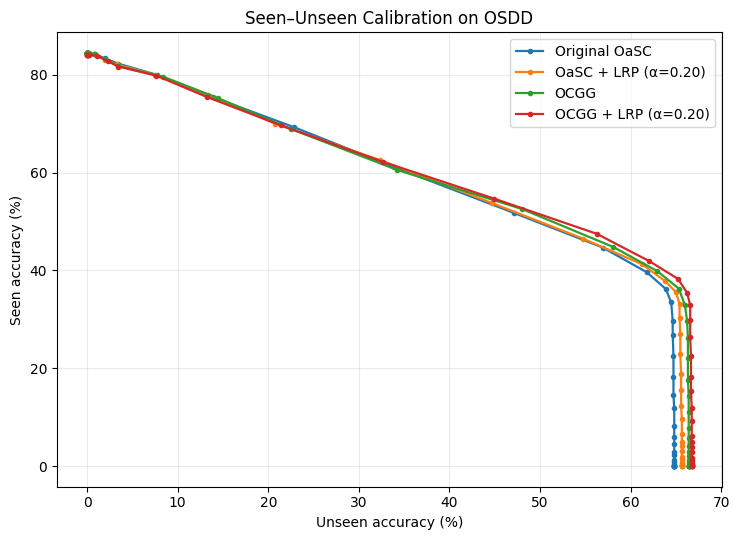

Saved: /kaggle/working/report_exports/figures/osdd_calibration_curve.png


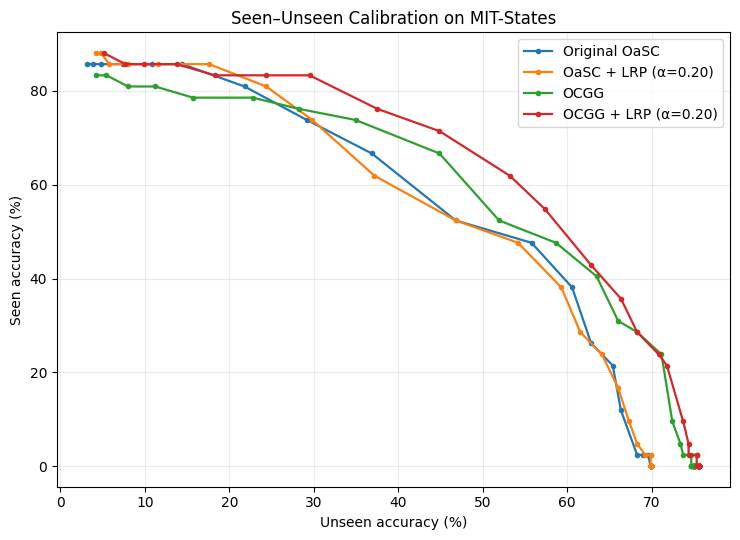

Saved: /kaggle/working/report_exports/figures/mit_calibration_curve.png


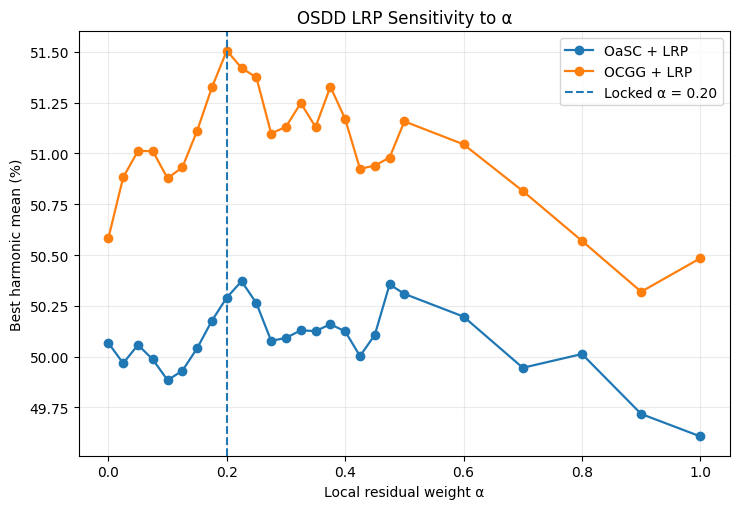

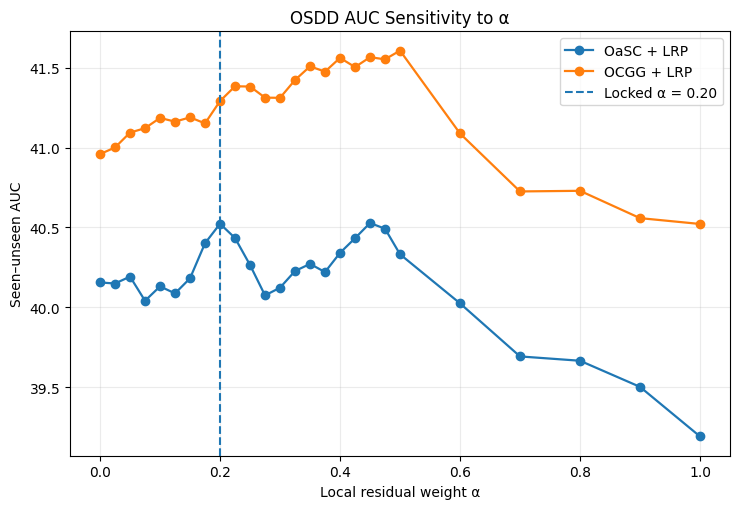

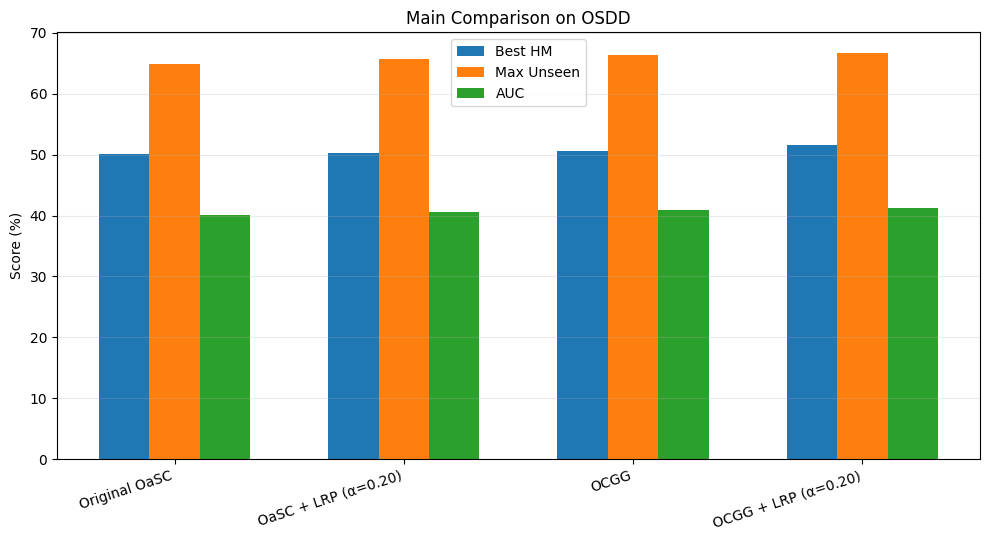

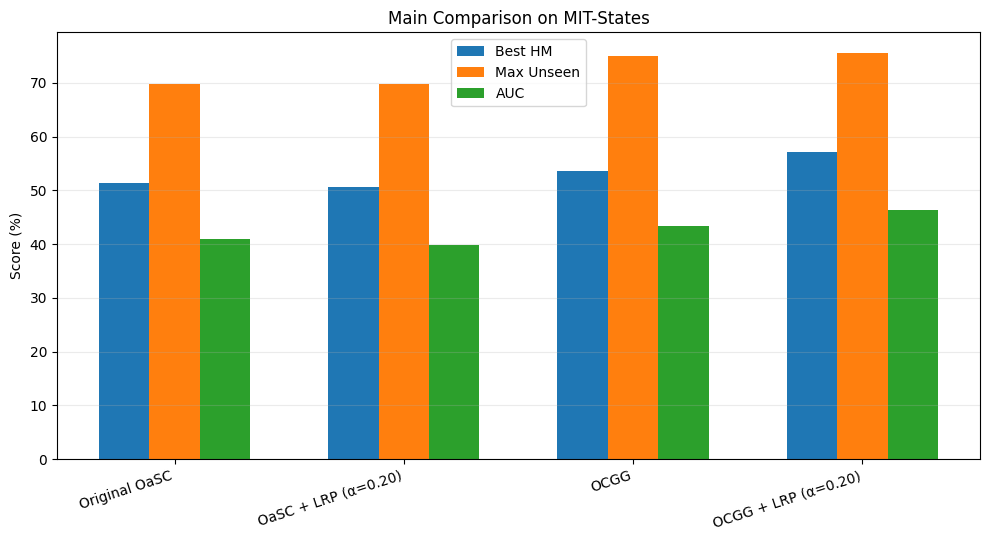

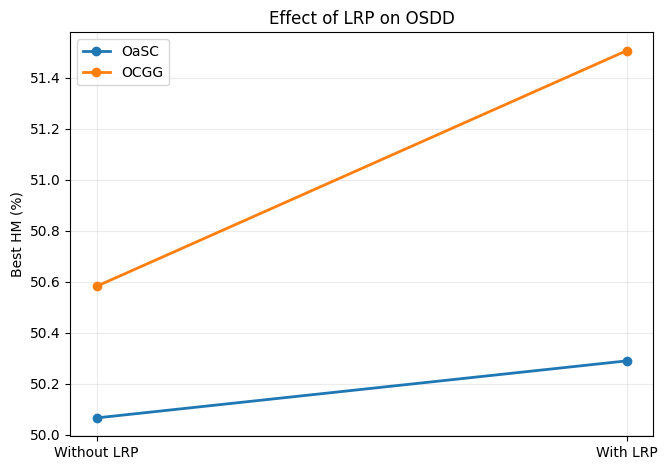

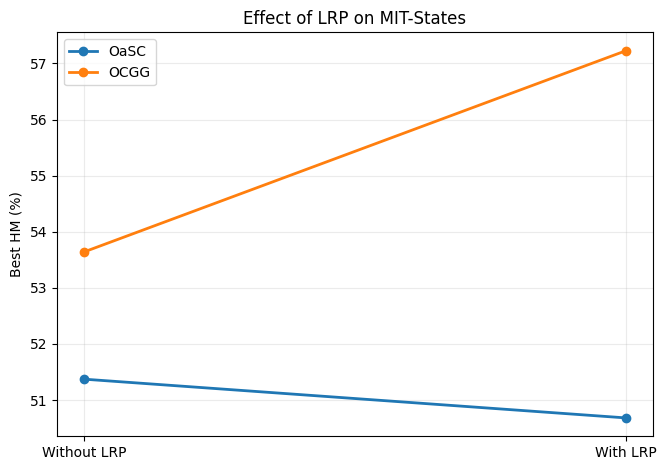

In [ ]:
# ---- Original cell 71 ----
# ============================================================
# Plot/export helpers
# ============================================================

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_calibration_plot(curves, title, filename):
    plt.figure(figsize=(7.5, 5.5))
    for label, df in curves:
        plt.plot(
            df["unseen_acc"] * 100,
            df["seen_acc"] * 100,
            marker="o",
            markersize=3,
            linewidth=1.6,
            label=label,
        )
    plt.xlabel("Unseen accuracy (%)")
    plt.ylabel("Seen accuracy (%)")
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    path = FIG_DIR / filename
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


save_calibration_plot(
    [
        ("Original OaSC", results),
        (f"OaSC + LRP (α={FINAL_ALPHA:.2f})", oasc_lrp_locked_results),
        ("OCGG", contrastive_results),
        (f"OCGG + LRP (α={FINAL_ALPHA:.2f})", ocgg_lrp_locked_results),
    ],
    "Seen–Unseen Calibration on OSDD",
    "osdd_calibration_curve.png",
)

save_calibration_plot(
    [
        ("Original OaSC", mit_oasc_results),
        (f"OaSC + LRP (α={FINAL_ALPHA:.2f})", mit_oasc_lrp_results),
        ("OCGG", mit_ocgg_transfer_results),
        (f"OCGG + LRP (α={FINAL_ALPHA:.2f})", mit_ocgg_lrp_results),
    ],
    "Seen–Unseen Calibration on MIT-States",
    "mit_calibration_curve.png",
)

# ---- Original cell 72 ----
# ============================================================
# OSDD alpha sensitivity figures
# ============================================================

plt.figure(figsize=(7.5, 5.2))
for method_name in ["OaSC", "OCGG"]:
    df_plot = alpha_sweep_df[alpha_sweep_df["Base Model"] == method_name]
    plt.plot(
        df_plot["Alpha"], df_plot["Best HM"],
        marker="o", linewidth=1.6, label=f"{method_name} + LRP"
    )
plt.axvline(FINAL_ALPHA, linestyle="--", linewidth=1.5,
            label=f"Locked α = {FINAL_ALPHA:.2f}")
plt.xlabel("Local residual weight α")
plt.ylabel("Best harmonic mean (%)")
plt.title("OSDD LRP Sensitivity to α")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "osdd_alpha_hm.png", dpi=220, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7.5, 5.2))
for method_name in ["OaSC", "OCGG"]:
    df_plot = alpha_sweep_df[alpha_sweep_df["Base Model"] == method_name]
    plt.plot(
        df_plot["Alpha"], df_plot["AUC"],
        marker="o", linewidth=1.6, label=f"{method_name} + LRP"
    )
plt.axvline(FINAL_ALPHA, linestyle="--", linewidth=1.5,
            label=f"Locked α = {FINAL_ALPHA:.2f}")
plt.xlabel("Local residual weight α")
plt.ylabel("Seen–unseen AUC")
plt.title("OSDD AUC Sensitivity to α")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "osdd_alpha_auc.png", dpi=220, bbox_inches="tight")
plt.show()

# ---- Original cell 73 ----
# ============================================================
# Main metric bars + LRP interaction figures
# ============================================================

def save_metric_bars(df, title, filename):
    methods = df["Method"].tolist()
    metric_names = ["Best HM", "Max Unseen", "AUC"]
    x = np.arange(len(methods))
    width = 0.22
    plt.figure(figsize=(10, 5.5))
    for j, metric in enumerate(metric_names):
        plt.bar(x + (j - 1) * width, df[metric], width=width, label=metric)
    plt.xticks(x, methods, rotation=18, ha="right")
    plt.ylabel("Score (%)")
    plt.title(title)
    plt.grid(axis="y", alpha=0.25)
    plt.legend()
    plt.tight_layout()
    path = FIG_DIR / filename
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()


def save_interaction_plot(df, title, filename):
    hm = dict(zip(df["Method"], df["Best HM"]))
    x = [0, 1]
    plt.figure(figsize=(6.8, 4.8))
    plt.plot(
        x,
        [hm["Original OaSC"], hm[f"OaSC + LRP (α={FINAL_ALPHA:.2f})"]],
        marker="o", linewidth=2, label="OaSC",
    )
    plt.plot(
        x,
        [hm["OCGG"], hm[f"OCGG + LRP (α={FINAL_ALPHA:.2f})"]],
        marker="o", linewidth=2, label="OCGG",
    )
    plt.xticks(x, ["Without LRP", "With LRP"])
    plt.ylabel("Best HM (%)")
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    path = FIG_DIR / filename
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()


save_metric_bars(osdd_main_table, "Main Comparison on OSDD", "osdd_main_bars.png")
save_metric_bars(mit_main_table, "Main Comparison on MIT-States", "mit_main_bars.png")
save_interaction_plot(osdd_main_table, "Effect of LRP on OSDD", "osdd_lrp_interaction.png")
save_interaction_plot(mit_main_table, "Effect of LRP on MIT-States", "mit_lrp_interaction.png")


In [ ]:
# ---- Original cell 75 ----
# ============================================================
# Auto-generated result statements for report drafting
# ============================================================

def row(df, method):
    return df[df["Method"] == method].iloc[0]

osdd_base = row(osdd_main_table, "Original OaSC")
osdd_ocgg = row(osdd_main_table, "OCGG")
osdd_final = row(osdd_main_table, f"OCGG + LRP (α={FINAL_ALPHA:.2f})")

mit_base = row(mit_main_table, "Original OaSC")
mit_oasc_lrp = row(mit_main_table, f"OaSC + LRP (α={FINAL_ALPHA:.2f})")
mit_ocgg = row(mit_main_table, "OCGG")
mit_final = row(mit_main_table, f"OCGG + LRP (α={FINAL_ALPHA:.2f})")

print("===== REPORT STARTER NOTES =====\n")
print(
    f"OSDD: OCGG + LRP improves Best HM from {osdd_base['Best HM']:.2f}% "
    f"to {osdd_final['Best HM']:.2f}% ({osdd_final['Best HM']-osdd_base['Best HM']:+.2f} pp), "
    f"Max Unseen from {osdd_base['Max Unseen']:.2f}% to {osdd_final['Max Unseen']:.2f}% "
    f"({osdd_final['Max Unseen']-osdd_base['Max Unseen']:+.2f} pp), and AUC from "
    f"{osdd_base['AUC']:.2f} to {osdd_final['AUC']:.2f} ({osdd_final['AUC']-osdd_base['AUC']:+.2f})."
)
print(
    f"OSDD complementarity: adding LRP to OCGG changes HM from {osdd_ocgg['Best HM']:.2f}% "
    f"to {osdd_final['Best HM']:.2f}% ({osdd_final['Best HM']-osdd_ocgg['Best HM']:+.2f} pp)."
)
print(
    f"MIT-States transfer: with α={FINAL_ALPHA:.2f} frozen from OSDD, OCGG + LRP improves "
    f"HM from {mit_ocgg['Best HM']:.2f}% to {mit_final['Best HM']:.2f}% "
    f"({mit_final['Best HM']-mit_ocgg['Best HM']:+.2f} pp), Max Unseen from "
    f"{mit_ocgg['Max Unseen']:.2f}% to {mit_final['Max Unseen']:.2f}% "
    f"({mit_final['Max Unseen']-mit_ocgg['Max Unseen']:+.2f} pp), and AUC from "
    f"{mit_ocgg['AUC']:.2f} to {mit_final['AUC']:.2f} ({mit_final['AUC']-mit_ocgg['AUC']:+.2f})."
)
print(
    f"Interaction: on MIT-States, LRP changes Original OaSC HM from {mit_base['Best HM']:.2f}% "
    f"to {mit_oasc_lrp['Best HM']:.2f}%, while the same locked LRP improves OCGG from "
    f"{mit_ocgg['Best HM']:.2f}% to {mit_final['Best HM']:.2f}%."
)

# ---- Original cell 76 ----
# ============================================================
# Final reproducibility checks
# ============================================================

assert abs(FINAL_ALPHA - 0.20) < 1e-12
assert REGION_SIZE == 3
assert TOP_REGIONS == 3
assert set(osdd_main_table["Method"]) == {
    "Original OaSC",
    f"OaSC + LRP (α={FINAL_ALPHA:.2f})",
    "OCGG",
    f"OCGG + LRP (α={FINAL_ALPHA:.2f})",
}
assert set(mit_main_table["Method"]) == set(osdd_main_table["Method"])

print("✓ Final architecture locked: OCGG + LRP")
print(f"✓ LRP: {REGION_SIZE}x{REGION_SIZE}, top-{TOP_REGIONS}, alpha={FINAL_ALPHA:.2f}")
print("✓ Same alpha transferred from OSDD to MIT-States")
print("✓ Report artifacts directory:", REPORT_DIR)


===== REPORT STARTER NOTES =====

OSDD: OCGG + LRP improves Best HM from 50.07% to 51.51% (+1.44 pp), Max Unseen from 64.82% to 66.75% (+1.93 pp), and AUC from 40.16 to 41.29 (+1.14).
OSDD complementarity: adding LRP to OCGG changes HM from 50.58% to 51.51% (+0.92 pp).
MIT-States transfer: with α=0.20 frozen from OSDD, OCGG + LRP improves HM from 53.64% to 57.23% (+3.59 pp), Max Unseen from 75.00% to 75.64% (+0.64 pp), and AUC from 43.47 to 46.33 (+2.86).
Interaction: on MIT-States, LRP changes Original OaSC HM from 51.37% to 50.68%, while the same locked LRP improves OCGG from 53.64% to 57.23%.


✓ Final architecture locked: OCGG + LRP
✓ LRP: 3x3, top-3, alpha=0.20
✓ Same alpha transferred from OSDD to MIT-States
✓ Report artifacts directory: /kaggle/working/report_exports


## 8. Paper-ready mechanism and qualitative figures


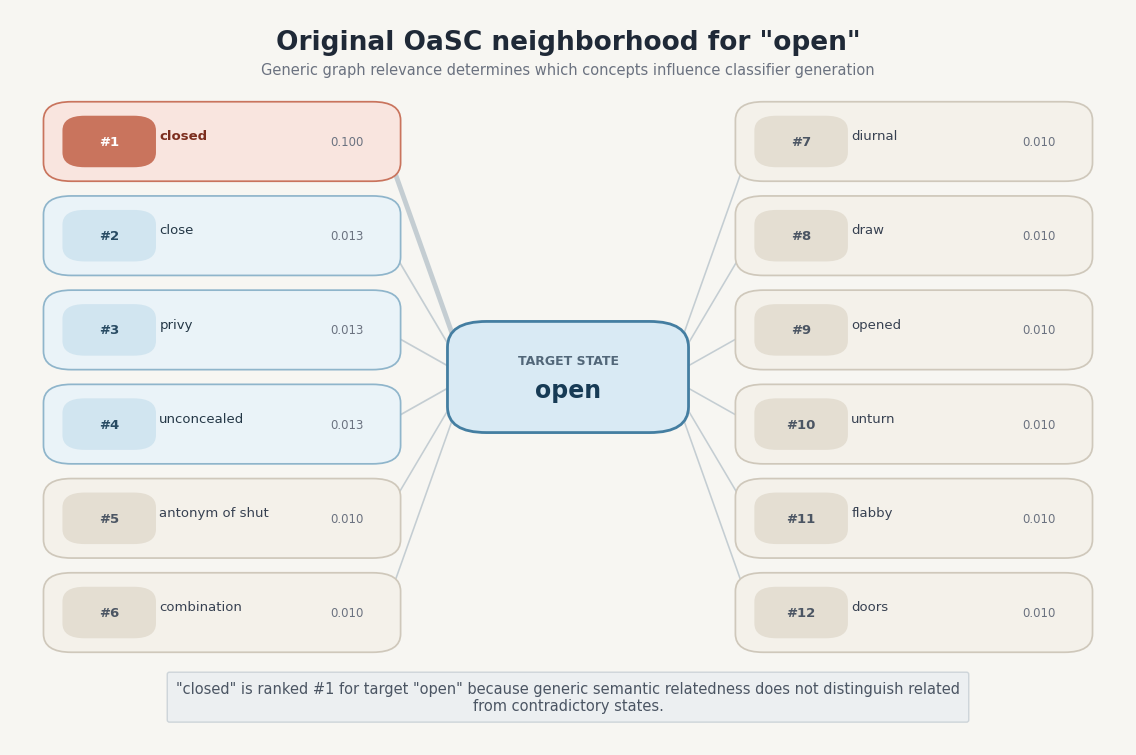

Saved: /kaggle/working/report_exports/qualitative/01_original_oasc_open_clean.png


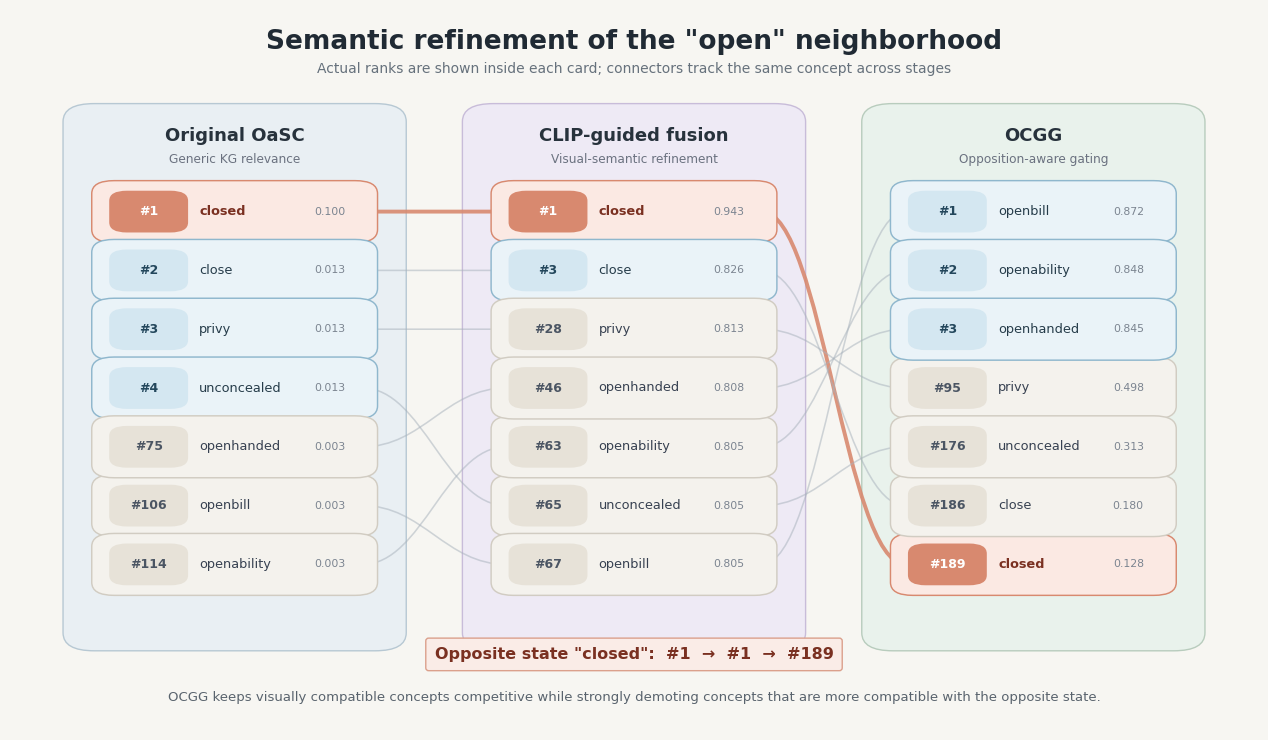

Saved: /kaggle/working/report_exports/qualitative/02_rank_evolution_open_clean.png


In [ ]:
# ---- Original cell 78 ----
# ============================================================
# QUALITATIVE FIGURE 1 — PAPER-READY VERSION
# Original OaSC generic neighborhood
#
# Clean rounded cards:
#   Rank | Concept | Graph relevance
#
# No circles, no X marks, no oversized annotations.
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from pathlib import Path
import numpy as np
import textwrap

QUAL_DIR = Path("/kaggle/working/report_exports/qualitative")
QUAL_DIR.mkdir(parents=True, exist_ok=True)


def get_ranked_neighbors(graph_rw, state, top_k=12):

    sid = state_node_ids[state]

    items = deduplicate_neighbors(
        graph_rw[sid]
    )

    items = sorted(
        items,
        key=lambda x: float(x[-1]),
        reverse=True
    )

    rows = []

    for rank, item in enumerate(
        items[:top_k],
        start=1
    ):

        nid = int(item[0])

        rows.append({
            "rank": rank,
            "node_id": nid,
            "name": str(nodes[nid]),
            "score": float(item[-1]),
        })

    return rows


def clean_concept_name(name):

    # Make KG strings readable in the figure
    name = str(name)

    name = name.replace(
        "_",
        " "
    )

    # Prevent very long labels from destroying the layout
    if len(name) > 18:
        name = "\n".join(
            textwrap.wrap(
                name,
                width=16
            )
        )

    return name


def draw_neighbor_card(
    ax,
    x,
    y,
    width,
    height,
    rank,
    name,
    score,
    highlight=False
):

    if highlight:
        face = "#F9E5DF"
        edge = "#C9745D"
        rank_face = "#C9745D"
        rank_text = "white"
        concept_color = "#7C2D1D"

    elif rank <= 4:
        face = "#EAF3F8"
        edge = "#8FB5CB"
        rank_face = "#D1E5F0"
        rank_text = "#284B63"
        concept_color = "#243746"

    else:
        face = "#F4F1EA"
        edge = "#CFC8BB"
        rank_face = "#E4DED2"
        rank_text = "#4B5563"
        concept_color = "#374151"


    # --------------------------------------------------------
    # Main rounded card
    # --------------------------------------------------------

    card = FancyBboxPatch(
        (
            x - width / 2,
            y - height / 2
        ),
        width,
        height,

        boxstyle=(
            "round,pad=0.015,"
            "rounding_size=0.025"
        ),

        transform=ax.transAxes,

        facecolor=face,
        edgecolor=edge,
        linewidth=1.25,
        zorder=5
    )

    ax.add_patch(card)


    # --------------------------------------------------------
    # Rank pill
    # --------------------------------------------------------

    rank_w = width * 0.22

    rank_box = FancyBboxPatch(
        (
            x - width / 2 + 0.012,
            y - height / 2 + 0.014
        ),
        rank_w,
        height - 0.028,

        boxstyle=(
            "round,pad=0.01,"
            "rounding_size=0.02"
        ),

        transform=ax.transAxes,

        facecolor=rank_face,
        edgecolor="none",
        zorder=6
    )

    ax.add_patch(rank_box)


    ax.text(
        x - width / 2
        + 0.012
        + rank_w / 2,

        y,

        f"#{rank}",

        transform=ax.transAxes,
        ha="center",
        va="center",

        fontsize=9.5,
        fontweight="bold",
        color=rank_text,
        zorder=7
    )


    # --------------------------------------------------------
    # Concept name
    # --------------------------------------------------------

    readable_name = (
        clean_concept_name(name)
    )


    ax.text(
        x - width / 2
        + rank_w
        + 0.025,

        y + 0.008,

        readable_name,

        transform=ax.transAxes,

        ha="left",
        va="center",

        fontsize=9.5,
        fontweight=(
            "bold"
            if highlight
            else "medium"
        ),

        color=concept_color,
        zorder=7
    )


    # --------------------------------------------------------
    # Score on right
    # --------------------------------------------------------

    ax.text(
        x + width / 2 - 0.018,
        y,

        f"{score:.3f}",

        transform=ax.transAxes,

        ha="right",
        va="center",

        fontsize=8.5,
        color="#6B7280",
        zorder=7
    )


def plot_original_oasc_neighborhood_clean(
    state="open",
    top_k=12
):

    neighbors = get_ranked_neighbors(
        rw_adj_lists,
        state,
        top_k=top_k
    )


    opposite = (
        OPPOSITE_STATE.get(
            state
        )
    )


    # ========================================================
    # Figure
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(12, 8)
    )

    fig.patch.set_facecolor(
        "#F7F6F2"
    )

    ax.set_facecolor(
        "#F7F6F2"
    )

    ax.set_xlim(
        0,
        1
    )

    ax.set_ylim(
        0,
        1
    )

    ax.axis(
        "off"
    )


    # ========================================================
    # TITLE
    # ========================================================

    ax.text(
        0.5,
        0.955,

        f'Original OaSC neighborhood for "{state}"',

        transform=ax.transAxes,

        ha="center",
        va="center",

        fontsize=19,
        fontweight="bold",
        color="#1F2937"
    )


    ax.text(
        0.5,
        0.918,

        "Generic graph relevance determines which concepts influence classifier generation",

        transform=ax.transAxes,

        ha="center",
        va="center",

        fontsize=10.5,
        color="#6B7280"
    )


    # ========================================================
    # CENTER TARGET CARD
    # ========================================================

    center_x = 0.5
    center_y = 0.50

    target_w = 0.18
    target_h = 0.115


    target = FancyBboxPatch(
        (
            center_x
            - target_w / 2,

            center_y
            - target_h / 2
        ),

        target_w,
        target_h,

        boxstyle=(
            "round,pad=0.018,"
            "rounding_size=0.035"
        ),

        transform=ax.transAxes,

        facecolor="#D9EAF4",
        edgecolor="#447EA1",
        linewidth=2.0,
        zorder=10
    )

    ax.add_patch(
        target
    )


    ax.text(
        center_x,
        center_y + 0.022,

        "TARGET STATE",

        transform=ax.transAxes,

        ha="center",
        va="center",

        fontsize=9,
        color="#526779",
        fontweight="bold",
        zorder=11
    )


    ax.text(
        center_x,
        center_y - 0.018,

        state,

        transform=ax.transAxes,

        ha="center",
        va="center",

        fontsize=17,
        color="#173B55",
        fontweight="bold",
        zorder=11
    )


    # ========================================================
    # FIXED PAPER-FRIENDLY POSITIONS
    #
    # 6 on left / 6 on right
    # Rank order goes from top to bottom.
    # ========================================================

    n_left = (
        top_k + 1
    ) // 2

    left_neighbors = (
        neighbors[:n_left]
    )

    right_neighbors = (
        neighbors[n_left:]
    )


    left_ys = np.linspace(
        0.82,
        0.18,
        len(left_neighbors)
    )

    right_ys = np.linspace(
        0.82,
        0.18,
        len(right_neighbors)
    )


    left_x = 0.19
    right_x = 0.81

    card_w = 0.29
    card_h = 0.078


    # ========================================================
    # DRAW LEFT CARDS
    # ========================================================

    for item, y in zip(
        left_neighbors,
        left_ys
    ):

        # connection first
        ax.plot(
            [
                center_x
                - target_w / 2,
                left_x
                + card_w / 2
            ],

            [
                center_y,
                y
            ],

            transform=ax.transAxes,

            color="#A9B8C2",
            linewidth=(
                0.9
                +
                2.6
                * (
                    item["score"]
                    / max(
                        x["score"]
                        for x in neighbors
                    )
                )
            ),

            alpha=0.65,
            zorder=1
        )


        is_opposite = (
            opposite is not None
            and item[
                "name"
            ].lower()
            ==
            opposite.lower()
        )


        draw_neighbor_card(
            ax,
            left_x,
            y,
            card_w,
            card_h,

            item["rank"],
            item["name"],
            item["score"],

            highlight=is_opposite
        )


    # ========================================================
    # DRAW RIGHT CARDS
    # ========================================================

    for item, y in zip(
        right_neighbors,
        right_ys
    ):

        ax.plot(
            [
                center_x
                + target_w / 2,
                right_x
                - card_w / 2
            ],

            [
                center_y,
                y
            ],

            transform=ax.transAxes,

            color="#A9B8C2",
            linewidth=(
                0.9
                +
                2.6
                * (
                    item["score"]
                    / max(
                        x["score"]
                        for x in neighbors
                    )
                )
            ),

            alpha=0.65,
            zorder=1
        )


        is_opposite = (
            opposite is not None
            and item[
                "name"
            ].lower()
            ==
            opposite.lower()
        )


        draw_neighbor_card(
            ax,
            right_x,
            y,
            card_w,
            card_h,

            item["rank"],
            item["name"],
            item["score"],

            highlight=is_opposite
        )


    # ========================================================
    # SMALL EXPLANATION
    # ========================================================

    if opposite is not None:

        opposite_row = next(
            (
                x
                for x in neighbors
                if x["name"].lower()
                == opposite.lower()
            ),
            None
        )

        if opposite_row is not None:

            statement = (
                f'"{opposite}" is ranked '
                f'#{opposite_row["rank"]} '
                f'for target "{state}" '
                "because generic semantic relatedness does "
                "not distinguish related from contradictory states."
            )

        else:

            statement = (
                "Generic semantic relevance may preserve "
                "concepts that are related but visually "
                "incompatible with the target state."
            )

    else:

        statement = (
            "Generic semantic relevance does not explicitly "
            "model state-level visual compatibility."
        )


    ax.text(
        0.5,
        0.065,

        "\n".join(
            textwrap.wrap(
                statement,
                width=105
            )
        ),

        transform=ax.transAxes,

        ha="center",
        va="center",

        fontsize=10.5,
        color="#4B5563",

        bbox=dict(
            boxstyle=(
                "round,pad=0.6,"
                "rounding_size=0.15"
            ),
            facecolor="#ECEFF1",
            edgecolor="#CDD4D9",
            linewidth=1.0
        )
    )


    # ========================================================
    # SAVE
    # ========================================================

    plt.subplots_adjust(
        left=0.035,
        right=0.965,
        top=0.96,
        bottom=0.04
    )


    out = (
        QUAL_DIR
        /
        f"01_original_oasc_{state}_clean.png"
    )


    plt.savefig(
        out,
        dpi=300,
        facecolor=fig.get_facecolor()
    )

    plt.show()

    print("Saved:", out)


plot_original_oasc_neighborhood_clean(
    state="open",
    top_k=12
)

# ---- Original cell 79 ----
# ============================================================
# QUALITATIVE FIGURE 2 — PAPER-READY RANK EVOLUTION
#
# Original OaSC  ->  Adaptive CLIP  ->  OCGG
#
# IMPORTANT:
# - Actual ranks are shown numerically inside the cards.
# - Vertical position is only for clean layout, NOT rank scale.
# - Only a small set of representative concepts is tracked.
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.path import Path as MplPath
from matplotlib.patches import FancyBboxPatch, PathPatch
import numpy as np
import textwrap


QUAL_DIR = Path("/kaggle/working/report_exports/qualitative")
QUAL_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Rank dictionary
# ------------------------------------------------------------

def rank_dictionary(graph_rw, state):

    sid = state_node_ids[state]

    items = deduplicate_neighbors(
        graph_rw[sid]
    )

    items = sorted(
        items,
        key=lambda x: float(x[-1]),
        reverse=True
    )

    return {
        int(item[0]): {
            "rank": rank,
            "score": float(item[-1]),
            "name": str(nodes[int(item[0])]),
        }
        for rank, item in enumerate(
            items,
            start=1
        )
    }


def pretty_name(name):

    name = str(name).replace("_", " ")

    if len(name) > 18:
        name = "\n".join(
            textwrap.wrap(name, width=17)
        )

    return name


# ------------------------------------------------------------
# Curved connector
# ------------------------------------------------------------

def draw_curve(
    ax,
    x1, y1,
    x2, y2,
    color="#AAB4BE",
    linewidth=1.3,
    alpha=0.55,
    zorder=1
):

    dx = x2 - x1

    verts = [
        (x1, y1),
        (x1 + dx * 0.42, y1),
        (x2 - dx * 0.42, y2),
        (x2, y2),
    ]

    codes = [
        MplPath.MOVETO,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.CURVE4,
    ]

    curve_path = MplPath(
        verts,
        codes
    )

    patch = PathPatch(
        curve_path,
        facecolor="none",
        edgecolor=color,
        linewidth=linewidth,
        alpha=alpha,
        zorder=zorder
    )

    ax.add_patch(patch)


# ------------------------------------------------------------
# Concept card
# ------------------------------------------------------------

def draw_rank_card(
    ax,
    x,
    y,
    width,
    height,
    rank,
    name,
    score=None,
    highlight=False,
    strong=False
):

    if highlight:
        face = "#FBE9E3"
        edge = "#D8896F"
        rank_face = "#D8896F"
        rank_color = "white"
        text_color = "#7A3021"

    elif strong:
        face = "#EAF3F8"
        edge = "#8FB7CD"
        rank_face = "#D4E7F1"
        rank_color = "#23475C"
        text_color = "#263C4A"

    else:
        face = "#F4F2ED"
        edge = "#D1CCC2"
        rank_face = "#E7E2D8"
        rank_color = "#4B5563"
        text_color = "#374151"


    card = FancyBboxPatch(
        (
            x - width / 2,
            y - height / 2
        ),
        width,
        height,

        boxstyle="round,pad=0.012,rounding_size=0.018",

        facecolor=face,
        edgecolor=edge,
        linewidth=1.05,
        zorder=5
    )

    ax.add_patch(card)


    # rank pill
    rank_w = width * 0.24

    pill = FancyBboxPatch(
        (
            x - width / 2 + 0.009,
            y - height / 2 + 0.009
        ),
        rank_w,
        height - 0.018,

        boxstyle="round,pad=0.007,rounding_size=0.014",

        facecolor=rank_face,
        edgecolor="none",
        zorder=6
    )

    ax.add_patch(pill)


    ax.text(
        x - width / 2 + 0.009 + rank_w / 2,
        y,

        f"#{rank}",

        ha="center",
        va="center",

        fontsize=9,
        fontweight="bold",
        color=rank_color,
        zorder=7
    )


    ax.text(
        x - width / 2 + rank_w + 0.025,
        y,

        pretty_name(name),

        ha="left",
        va="center",

        fontsize=9.3,
        fontweight="bold" if highlight else "medium",
        color=text_color,
        zorder=7
    )


    if score is not None:

        ax.text(
            x + width / 2 - 0.014,
            y,

            f"{score:.3f}",

            ha="right",
            va="center",

            fontsize=7.8,
            color="#7B8490",
            zorder=7
        )


# ------------------------------------------------------------
# Main figure
# ------------------------------------------------------------

def plot_rank_evolution_clean(
    state="open",
    n_original=3,
    n_final=3
):

    original = rank_dictionary(
        rw_adj_lists,
        state
    )

    adaptive = rank_dictionary(
        adaptive_clip_graph["rw_adj_lists"],
        state
    )

    ocgg = rank_dictionary(
        contrastive_graph["rw_adj_lists"],
        state
    )


    opposite = OPPOSITE_STATE.get(state)

    opposite_id = (
        state_node_ids.get(opposite)
        if opposite is not None
        else None
    )


    # ========================================================
    # SELECT A SMALL, MEANINGFUL SET
    #
    # 1. opposite state
    # 2. top-N from original
    # 3. top-N from OCGG
    #
    # This keeps the figure readable.
    # ========================================================

    shared = (
        set(original)
        & set(adaptive)
        & set(ocgg)
    )


    original_top = [
        nid
        for nid in sorted(
            shared,
            key=lambda n: original[n]["rank"]
        )
        if nid != opposite_id
    ][:n_original]


    final_top = [
        nid
        for nid in sorted(
            shared,
            key=lambda n: ocgg[n]["rank"]
        )
        if nid != opposite_id
    ][:n_final]


    selected = []

    if opposite_id in shared:
        selected.append(opposite_id)

    for nid in original_top + final_top:
        if nid not in selected:
            selected.append(nid)


    # Keep figure compact
    selected = selected[:7]


    # ========================================================
    # FIGURE
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(13, 7.5)
    )

    bg = "#F7F6F2"

    fig.patch.set_facecolor(bg)
    ax.set_facecolor(bg)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")


    # ========================================================
    # TITLE
    # ========================================================

    ax.text(
        0.5,
        0.955,

        f'Semantic refinement of the "{state}" neighborhood',

        ha="center",
        va="center",

        fontsize=19,
        fontweight="bold",
        color="#202A34"
    )


    ax.text(
        0.5,
        0.918,

        "Actual ranks are shown inside each card; connectors track the same concept across stages",

        ha="center",
        va="center",

        fontsize=10,
        color="#66717C"
    )


    # ========================================================
    # STAGE PANELS
    # ========================================================

    stage_x = [
        0.18,
        0.50,
        0.82
    ]

    stage_titles = [
        "Original OaSC",
        "CLIP-guided fusion",
        "OCGG"
    ]

    stage_subtitles = [
        "Generic KG relevance",
        "Visual-semantic refinement",
        "Opposition-aware gating"
    ]

    stage_colors = [
        "#E9EFF3",
        "#EEEAF5",
        "#E9F2EC"
    ]

    stage_edges = [
        "#B7C8D3",
        "#C8BCD9",
        "#B8CCBD"
    ]


    panel_y = 0.49
    panel_w = 0.245
    panel_h = 0.73


    for x, title, subtitle, fc, ec in zip(
        stage_x,
        stage_titles,
        stage_subtitles,
        stage_colors,
        stage_edges
    ):

        panel = FancyBboxPatch(
            (
                x - panel_w / 2,
                panel_y - panel_h / 2
            ),
            panel_w,
            panel_h,

            boxstyle="round,pad=0.015,rounding_size=0.025",

            facecolor=fc,
            edgecolor=ec,
            linewidth=1.0,
            zorder=0
        )

        ax.add_patch(panel)


        ax.text(
            x,
            0.825,

            title,

            ha="center",
            va="center",

            fontsize=13,
            fontweight="bold",
            color="#27323C"
        )


        ax.text(
            x,
            0.792,

            subtitle,

            ha="center",
            va="center",

            fontsize=8.7,
            color="#6B7280"
        )


    # ========================================================
    # DETERMINE CARD ORDER WITHIN EACH STAGE
    #
    # Sort only selected concepts by actual rank.
    # ========================================================

    stage_dicts = [
        original,
        adaptive,
        ocgg
    ]


    card_positions = {}


    card_top = 0.72
    card_bottom = 0.23

    n_cards = len(selected)

    ys = np.linspace(
        card_top,
        card_bottom,
        n_cards
    )

    card_w = 0.205
    card_h = 0.062


    for stage_idx, data in enumerate(stage_dicts):

        x = stage_x[stage_idx]

        ordered = sorted(
            selected,
            key=lambda nid: data[nid]["rank"]
        )


        card_positions[stage_idx] = {}


        for row_idx, nid in enumerate(ordered):

            y = ys[row_idx]

            card_positions[
                stage_idx
            ][nid] = (
                x,
                y
            )


    # ========================================================
    # CONNECTORS FIRST
    # ========================================================

    for nid in selected:

        name = original[nid]["name"]

        is_opposite = (
            opposite is not None
            and name.lower()
            == opposite.lower()
        )


        connector_color = (
            "#D8896F"
            if is_opposite
            else "#A8B2BC"
        )

        connector_width = (
            2.8
            if is_opposite
            else 1.15
        )

        connector_alpha = (
            0.9
            if is_opposite
            else 0.52
        )


        x1, y1 = card_positions[0][nid]
        x2, y2 = card_positions[1][nid]
        x3, y3 = card_positions[2][nid]


        draw_curve(
            ax,
            x1 + card_w / 2,
            y1,
            x2 - card_w / 2,
            y2,

            color=connector_color,
            linewidth=connector_width,
            alpha=connector_alpha
        )


        draw_curve(
            ax,
            x2 + card_w / 2,
            y2,
            x3 - card_w / 2,
            y3,

            color=connector_color,
            linewidth=connector_width,
            alpha=connector_alpha
        )


    # ========================================================
    # DRAW CARDS
    # ========================================================

    for stage_idx, data in enumerate(stage_dicts):

        for nid in selected:

            x, y = card_positions[
                stage_idx
            ][nid]


            name = data[nid]["name"]

            is_opposite = (
                opposite is not None
                and name.lower()
                == opposite.lower()
            )


            strong = (
                data[nid]["rank"] <= 5
                and not is_opposite
            )


            draw_rank_card(
                ax,

                x,
                y,

                card_w,
                card_h,

                rank=data[nid]["rank"],
                name=name,
                score=data[nid]["score"],

                highlight=is_opposite,
                strong=strong
            )


    # ========================================================
    # OPPOSITE-STATE CALLOUT
    # ========================================================

    if (
        opposite_id is not None
        and opposite_id in shared
    ):

        original_rank = original[
            opposite_id
        ]["rank"]

        adaptive_rank = adaptive[
            opposite_id
        ]["rank"]

        ocgg_rank = ocgg[
            opposite_id
        ]["rank"]


        callout = (
            f'Opposite state "{opposite}":  '
            f'#{original_rank}  →  '
            f'#{adaptive_rank}  →  '
            f'#{ocgg_rank}'
        )


        ax.text(
            0.5,
            0.105,

            callout,

            ha="center",
            va="center",

            fontsize=11.5,
            fontweight="bold",
            color="#7A3021",

            bbox=dict(
                boxstyle="round,pad=0.55,rounding_size=0.18",
                facecolor="#FAECE7",
                edgecolor="#DBA08C",
                linewidth=1.0
            )
        )


    # ========================================================
    # BOTTOM INTERPRETATION
    # ========================================================

    ax.text(
        0.5,
        0.045,

        "OCGG keeps visually compatible concepts competitive while strongly demoting concepts "
        "that are more compatible with the opposite state.",

        ha="center",
        va="center",

        fontsize=9.5,
        color="#59636D"
    )


    plt.subplots_adjust(
        left=0.02,
        right=0.98,
        top=0.98,
        bottom=0.02
    )


    out = (
        QUAL_DIR
        /
        f"02_rank_evolution_{state}_clean.png"
    )


    plt.savefig(
        out,
        dpi=300,
        facecolor=bg
    )

    plt.show()

    print("Saved:", out)


plot_rank_evolution_clean(
    state="open",
    n_original=3,
    n_final=3
)


In [ ]:
# ---- Original cell 80 ----
%pip install -q adjustText


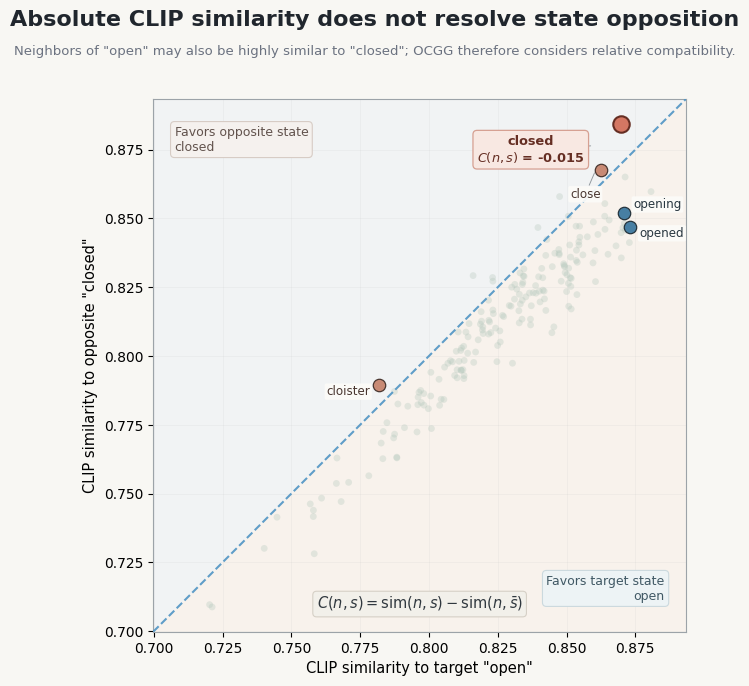

Saved: /kaggle/working/report_exports/qualitative/03_clip_target_vs_opposite_open_final.png

Target-favoring concepts shown:


,name,target_sim,opposite_sim,margin
73,opened,0.8731,0.8468,0.0263
87,opening,0.8708,0.8521,0.0187



Opposite-favoring concepts shown:


,name,target_sim,opposite_sim,margin
36,close,0.8626,0.8675,-0.0049
131,cloister,0.7817,0.7896,-0.0079



Main opposite state:


,name,target_sim,opposite_sim,margin
56,closed,0.8698,0.8844,-0.0147



OPEN — MOST DEMOTED BY OCGG


,Neighbor,Adaptive Rank,OCGG Rank,Rank Drop,Contrastive Margin
0,closed,1,189,188,-0.0147
1,close,3,186,183,-0.0049
2,mean_not_shut,16,167,151,0.0062
3,closet,54,188,134,-0.0071
4,unclosed,58,191,133,-0.0105
5,door,52,184,132,-0.0002
6,clopen,25,157,132,0.0076
7,reclose,44,166,122,0.0063



OPEN — MOST PROMOTED BY OCGG


,Neighbor,Adaptive Rank,OCGG Rank,Rank Drop,Contrastive Margin
0,openbsd,187,10,-177,0.0302
1,opensightly,174,23,-151,0.0254
2,cephalotomy,175,24,-151,0.0251
3,hymenotomy,179,36,-143,0.0217
4,opencast,155,13,-142,0.0273
5,campania,183,43,-140,0.0210
6,cart,168,31,-137,0.0233
7,stomacher,170,46,-124,0.0206


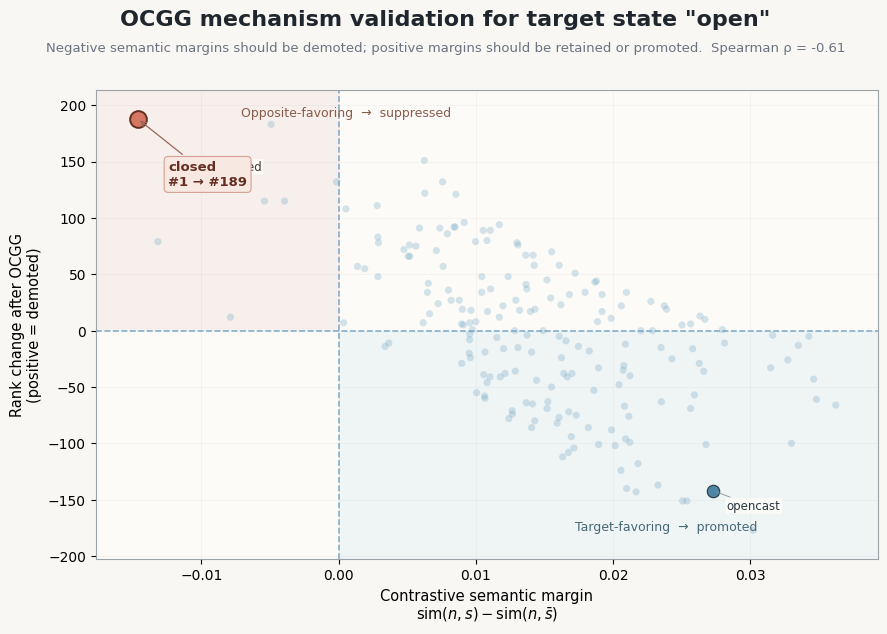

Saved: /kaggle/working/report_exports/qualitative/04_ocgg_mechanism_open_clean.png

Spearman correlation: -0.6084

Suppression examples:


,Neighbor,Contrastive Margin,Adaptive Rank,OCGG Rank,Rank Drop
57,unclosed,-0.0105,58,191,133



Promotion examples:


,Neighbor,Contrastive Margin,Adaptive Rank,OCGG Rank,Rank Drop
154,opencast,0.0273,155,13,-142


In [ ]:
# ---- Original cell 81 ----
# ============================================================
# QUALITATIVE FIGURE 3 — FINAL CLEAN VERSION
#
# Why absolute CLIP similarity is insufficient
#
# - Actual CLIP coordinates are preserved.
# - Readable concepts are preferred.
# - Labels repel automatically using adjustText.
# - "closed" receives a dedicated callout.
# - Nearby "close" remains visible without overlapping.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from pathlib import Path
from adjustText import adjust_text


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

QUAL_DIR = Path(
    "/kaggle/working/report_exports/qualitative"
)

QUAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# HELPER — find preferred readable concepts
# ============================================================

def find_preferred_concepts(
    df,
    preferred_names,
    margin_sign=None,
    max_items=2,
    exclude_names=None
):
    """
    Select readable concepts from the actual graph.

    margin_sign:
        "positive" -> target-favoring
        "negative" -> opposite-favoring
        None       -> no margin restriction
    """

    if exclude_names is None:
        exclude_names = set()

    work = df.copy()

    work["name_lower"] = (
        work["name"]
        .astype(str)
        .str.lower()
    )

    # --------------------------------------------------------
    # Margin restriction
    # --------------------------------------------------------

    if margin_sign == "positive":

        work = work[
            work["margin"] > 0
        ]

    elif margin_sign == "negative":

        work = work[
            work["margin"] < 0
        ]


    # --------------------------------------------------------
    # Remove explicitly excluded concepts
    # --------------------------------------------------------

    work = work[
        ~work["name_lower"].isin(
            {
                str(x).lower()
                for x in exclude_names
            }
        )
    ]


    selected = []
    used_ids = set()


    # ========================================================
    # First: exact preferred names
    # ========================================================

    for preferred in preferred_names:

        exact = work[
            work["name_lower"]
            ==
            preferred.lower()
        ]

        if len(exact) > 0:

            row = exact.iloc[0]

            if int(row["nid"]) not in used_ids:

                selected.append(row)

                used_ids.add(
                    int(row["nid"])
                )

        if len(selected) >= max_items:
            break


    # ========================================================
    # Second: substring matches
    # ========================================================

    if len(selected) < max_items:

        for preferred in preferred_names:

            matches = work[
                work["name_lower"]
                .str.contains(
                    preferred.lower(),
                    regex=False
                )
            ]

            # stronger margin first
            matches = matches.assign(
                abs_margin=
                    matches["margin"].abs()
            ).sort_values(
                "abs_margin",
                ascending=False
            )

            for _, row in matches.iterrows():

                nid = int(
                    row["nid"]
                )

                if nid in used_ids:
                    continue

                selected.append(row)

                used_ids.add(nid)

                if len(selected) >= max_items:
                    break

            if len(selected) >= max_items:
                break


    # ========================================================
    # Fallback: strongest clean margins
    # ========================================================

    if len(selected) < max_items:

        fallback = (
            work.assign(
                abs_margin=
                    work["margin"].abs()
            )
            .sort_values(
                "abs_margin",
                ascending=False
            )
        )

        ugly_tokens = [
            "bsd",
            "bill",
            "ability",
            "diurnal",
            "cephal",
            "privy",
            "flabby",
            "combination",
        ]

        for _, row in fallback.iterrows():

            name = str(
                row["name"]
            ).lower()

            if any(
                token in name
                for token in ugly_tokens
            ):
                continue

            nid = int(
                row["nid"]
            )

            if nid in used_ids:
                continue

            selected.append(row)

            used_ids.add(nid)

            if len(selected) >= max_items:
                break


    if len(selected) == 0:

        return pd.DataFrame(
            columns=df.columns
        )


    return pd.DataFrame(
        selected[:max_items]
    )


# ============================================================
# MAIN FUNCTION
# ============================================================

def plot_target_vs_opposite_similarity_final(
    state="open"
):

    opposite = (
        OPPOSITE_STATE[state]
    )

    sid = (
        state_node_ids[state]
    )


    # ========================================================
    # ORIGINAL GRAPH NEIGHBORHOOD
    # ========================================================

    items = deduplicate_neighbors(
        rw_adj_lists[sid]
    )


    target_feat = (
        state_clip_features[state]
    )

    opposite_feat = (
        state_clip_features[opposite]
    )


    # ========================================================
    # BUILD DATAFRAME
    # ========================================================

    rows = []


    for item in items:

        nid = int(
            item[0]
        )

        feat = (
            clip_node_features[nid]
        )


        target_sim = (
            torch.dot(
                target_feat,
                feat
            )
            .item()
        )


        opposite_sim = (
            torch.dot(
                opposite_feat,
                feat
            )
            .item()
        )


        rows.append({

            "nid":
                nid,

            "name":
                str(
                    nodes[nid]
                ),

            "target_sim":
                target_sim,

            "opposite_sim":
                opposite_sim,

            "margin":
                target_sim
                -
                opposite_sim
        })


    df = pd.DataFrame(
        rows
    )


    # ========================================================
    # LITERAL OPPOSITE STATE
    # ========================================================

    opposite_row = (
        df[
            df["name"]
            .astype(str)
            .str.lower()
            ==
            opposite.lower()
        ]
    )


    # ========================================================
    # SELECT READABLE REPRESENTATIVE CONCEPTS
    # ========================================================

    if (
        state.lower() == "open"
        and
        opposite.lower() == "closed"
    ):

        # ----------------------------------------------------
        # Prefer concrete visual/object concepts
        # ----------------------------------------------------

        target_examples = (
            find_preferred_concepts(

                df,

                preferred_names=[
                    "doors",
                    "door",
                    "opened",
                    "opening",
                    "openable",
                    "entrance",
                    "hatch",
                    "lid",
                ],

                margin_sign="positive",

                max_items=2
            )
        )


        # ----------------------------------------------------
        # Prefer concepts genuinely related to CLOSED
        # ----------------------------------------------------

        opposite_examples = (
            find_preferred_concepts(

                df,

                preferred_names=[
                    "close",
                    "shut",
                    "closing",
                    "closure",
                    "sealed",
                    "locked",
                    "cloister",
                ],

                margin_sign="negative",

                max_items=2,

                exclude_names=[
                    "closed"
                ]
            )
        )


    else:

        target_examples = (
            find_preferred_concepts(

                df,

                preferred_names=[
                    state
                ],

                margin_sign="positive",

                max_items=2
            )
        )


        opposite_examples = (
            find_preferred_concepts(

                df,

                preferred_names=[
                    opposite
                ],

                margin_sign="negative",

                max_items=2,

                exclude_names=[
                    opposite
                ]
            )
        )


    # ========================================================
    # FIGURE
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(9.0, 7.4)
    )


    PAPER_BG = "#F8F7F3"
    AX_BG = "#FCFBF8"


    fig.patch.set_facecolor(
        PAPER_BG
    )

    ax.set_facecolor(
        AX_BG
    )


    plt.subplots_adjust(
        left=0.13,
        right=0.97,
        bottom=0.12,
        top=0.84
    )


    # ========================================================
    # TITLE + SUBTITLE
    # ========================================================

    fig.text(
        0.5,
        0.947,

        (
            "Absolute CLIP similarity "
            "does not resolve state opposition"
        ),

        ha="center",
        va="center",

        fontsize=16,
        fontweight="bold",

        color="#20262D"
    )


    fig.text(
        0.5,
        0.905,

        (
            f'Neighbors of "{state}" may also be highly similar '
            f'to "{opposite}"; OCGG therefore considers '
            "relative compatibility."
        ),

        ha="center",
        va="center",

        fontsize=9.5,

        color="#6B7280"
    )


    # ========================================================
    # LIMITS
    # ========================================================

    all_values = np.concatenate([
        df["target_sim"].to_numpy(),
        df["opposite_sim"].to_numpy()
    ])


    padding = 0.009


    low = (
        all_values.min()
        -
        padding
    )


    high = (
        all_values.max()
        +
        padding
    )


    ax.set_xlim(
        low,
        high
    )


    ax.set_ylim(
        low,
        high
    )


    ax.set_aspect(
        "equal",
        adjustable="box"
    )


    # ========================================================
    # SEMANTIC REGIONS
    # ========================================================

    xs = np.linspace(
        low,
        high,
        400
    )


    # opposite side
    ax.fill_between(
        xs,
        xs,
        high,

        facecolor="#EEF2F4",
        alpha=0.78,

        zorder=0
    )


    # target side
    ax.fill_between(
        xs,
        low,
        xs,

        facecolor="#F7F0E8",
        alpha=0.74,

        zorder=0
    )


    # ========================================================
    # ALL CONCEPTS
    # ========================================================

    ax.scatter(
        df["target_sim"],
        df["opposite_sim"],

        s=24,

        facecolor="#AFC4B8",
        edgecolor="none",

        alpha=0.30,

        zorder=2
    )


    # ========================================================
    # DIAGONAL
    # ========================================================

    ax.plot(
        [low, high],
        [low, high],

        linestyle="--",

        linewidth=1.5,

        color="#4F94C4",

        alpha=0.90,

        zorder=3
    )


    # ========================================================
    # TEXT OBJECTS FOR adjustText
    # ========================================================

    movable_texts = []


    # ========================================================
    # TARGET-SUPPORTING CONCEPTS
    # ========================================================

    for _, row in (
        target_examples.iterrows()
    ):

        name = (
            str(
                row["name"]
            )
            .replace(
                "_",
                " "
            )
        )


        ax.scatter(
            row["target_sim"],
            row["opposite_sim"],

            s=80,

            facecolor="#477FA3",
            edgecolor="#26343D",

            linewidth=0.9,

            zorder=6
        )


        txt = ax.text(

            row["target_sim"]
            + 0.002,

            row["opposite_sim"],

            name,

            fontsize=8.6,

            ha="left",
            va="center",

            color="#293740",

            bbox=dict(
                boxstyle="round,pad=0.14",
                facecolor="#FCFBF8",
                edgecolor="none",
                alpha=0.94
            ),

            zorder=8
        )


        movable_texts.append(
            txt
        )


    # ========================================================
    # OPPOSITE-SUPPORTING CONCEPTS
    # ========================================================

    for _, row in (
        opposite_examples.iterrows()
    ):

        name = (
            str(
                row["name"]
            )
            .replace(
                "_",
                " "
            )
        )


        ax.scatter(
            row["target_sim"],
            row["opposite_sim"],

            s=80,

            facecolor="#C88A75",
            edgecolor="#493630",

            linewidth=0.9,

            zorder=6
        )


        txt = ax.text(

            row["target_sim"]
            - 0.002,

            row["opposite_sim"],

            name,

            fontsize=8.6,

            ha="right",
            va="center",

            color="#493630",

            bbox=dict(
                boxstyle="round,pad=0.14",
                facecolor="#FCFBF8",
                edgecolor="none",
                alpha=0.94
            ),

            zorder=8
        )


        movable_texts.append(
            txt
        )


    # ========================================================
    # MAIN CLOSED CALLOUT
    # ========================================================

    closed_text = None


    if len(
        opposite_row
    ) > 0:

        row = (
            opposite_row.iloc[0]
        )


        ax.scatter(
            row["target_sim"],
            row["opposite_sim"],

            s=140,

            facecolor="#D47763",
            edgecolor="#652E23",

            linewidth=1.5,

            zorder=10
        )


        # ----------------------------------------------------
        # Put initial text safely to the LEFT of the point
        # ----------------------------------------------------

        closed_text = ax.text(

            row["target_sim"]
            - 0.010,

            row["opposite_sim"]
            - 0.008,

            (
                f'{opposite}\n'
                f'$C(n,s)$ = '
                f'{row["margin"]:+.3f}'
            ),

            fontsize=9.3,
            fontweight="bold",

            ha="right",
            va="center",

            color="#652E23",

            bbox=dict(
                boxstyle="round,pad=0.32",
                facecolor="#F8E8E2",
                edgecolor="#D6A092",
                linewidth=0.9
            ),

            zorder=11
        )


        movable_texts.append(
            closed_text
        )


    # ========================================================
    # AUTOMATIC NON-OVERLAPPING LABEL PLACEMENT
    # ========================================================

    if len(
        movable_texts
    ) > 0:

        adjust_text(

            movable_texts,

            ax=ax,

            # move labels, never data
            only_move={
                "text": "xy",
                "static": "xy",
                "explode": "xy",
                "pull": "xy",
            },

            expand=(
                1.15,
                1.25
            ),

            force_text=(
                0.7,
                0.9
            ),

            force_static=(
                0.4,
                0.5
            ),

            force_pull=(
                0.02,
                0.02
            ),

            min_arrow_len=5,

            arrowprops=dict(
                arrowstyle="-",
                color="#7D858B",
                linewidth=0.65,
                alpha=0.85
            )
        )


    # ========================================================
    # REGION LABELS
    # ========================================================

    ax.text(
        0.04,
        0.95,

        (
            "Favors opposite state\n"
            f"{opposite}"
        ),

        transform=ax.transAxes,

        ha="left",
        va="top",

        fontsize=9,

        color="#62534D",

        bbox=dict(
            boxstyle="round,pad=0.32",
            facecolor="#F5F1EE",
            edgecolor="#D7CCC5",
            linewidth=0.8
        ),

        zorder=20
    )


    ax.text(
        0.96,
        0.055,

        (
            "Favors target state\n"
            f"{state}"
        ),

        transform=ax.transAxes,

        ha="right",
        va="bottom",

        fontsize=9,

        color="#415965",

        bbox=dict(
            boxstyle="round,pad=0.32",
            facecolor="#EDF3F5",
            edgecolor="#CBD9DE",
            linewidth=0.8
        ),

        zorder=20
    )


    # ========================================================
    # FORMULA
    # ========================================================

    ax.text(
        0.5,
        0.035,

        (
            r"$C(n,s)="
            r"\mathrm{sim}(n,s)"
            r"-"
            r"\mathrm{sim}(n,\bar{s})$"
        ),

        transform=ax.transAxes,

        ha="center",
        va="bottom",

        fontsize=10.5,

        color="#30383F",

        bbox=dict(
            boxstyle="round,pad=0.26",
            facecolor="#F2F0EA",
            edgecolor="#D6D0C6",
            linewidth=0.8
        ),

        zorder=20
    )


    # ========================================================
    # AXIS LABELS
    # ========================================================

    ax.set_xlabel(
        f'CLIP similarity to target "{state}"',
        fontsize=10.5
    )


    ax.set_ylabel(
        f'CLIP similarity to opposite "{opposite}"',
        fontsize=10.5
    )


    # ========================================================
    # GRID / SPINES
    # ========================================================

    ax.grid(
        alpha=0.10,
        linewidth=0.7
    )


    for spine in (
        ax.spines.values()
    ):

        spine.set_color(
            "#9CA3A8"
        )

        spine.set_linewidth(
            0.8
        )


    # ========================================================
    # SAVE
    # ========================================================

    out = (
        QUAL_DIR
        /
        f"03_clip_target_vs_opposite_{state}_final.png"
    )


    plt.savefig(
        out,
        dpi=300,
        facecolor=fig.get_facecolor()
    )


    plt.show()


    print(
        "Saved:",
        out
    )


    # ========================================================
    # DEBUG / CONFIRM LABELS USED
    # ========================================================

    print(
        "\nTarget-favoring concepts shown:"
    )

    display(
        target_examples[
            [
                "name",
                "target_sim",
                "opposite_sim",
                "margin"
            ]
        ].round(4)
    )


    print(
        "\nOpposite-favoring concepts shown:"
    )

    display(
        opposite_examples[
            [
                "name",
                "target_sim",
                "opposite_sim",
                "margin"
            ]
        ].round(4)
    )


    if len(opposite_row) > 0:

        print(
            "\nMain opposite state:"
        )

        display(
            opposite_row[
                [
                    "name",
                    "target_sim",
                    "opposite_sim",
                    "margin"
                ]
            ].round(4)
        )


    return df


# ============================================================
# GENERATE FIGURE
# ============================================================

open_semantic_scatter = (
    plot_target_vs_opposite_similarity_final(
        state="open"
    )
)

# ---- Original cell 82 ----
# ============================================================
# QUALITATIVE FIGURE 4 — CLEAN OCGG MECHANISM VALIDATION
#
# x-axis:
#   contrastive semantic margin
#   sim(target) - sim(opposite)
#
# y-axis:
#   rank drop after OCGG
#   positive = demoted
#   negative = promoted
#
# Expected OCGG behavior:
#
#   x < 0, y > 0
#       concept favors opposite
#       -> should be demoted
#
#   x > 0, y < 0
#       concept favors target
#       -> should be promoted / retained
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path


QUAL_DIR = Path(
    "/kaggle/working/report_exports/qualitative"
)

QUAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# HELPER — choose a few readable concepts
# ============================================================

def choose_readable_mechanism_examples(
    comparison,
    state,
    opposite,
    n_each=2
):
    """
    Pick a few readable examples from the two expected quadrants.

    We always handle the literal opposite state separately.
    """

    df = comparison.copy()

    df["name_lower"] = (
        df["Neighbor"]
        .astype(str)
        .str.lower()
    )


    # --------------------------------------------------------
    # Hide ugly / low-value labels from annotations only.
    # Points still remain in the scatter.
    # --------------------------------------------------------

    bad_tokens = [
        "bsd",
        "cephal",
        "diurnal",
        "combination",
        "privy",
        "flabby",
        "antonym_",
        "mean_not",
        "openbill",
    ]


    def readable(name):

        name = str(name).lower()

        return not any(
            token in name
            for token in bad_tokens
        )


    clean = df[
        df["Neighbor"]
        .apply(readable)
    ].copy()


    # --------------------------------------------------------
    # Expected suppression quadrant:
    # negative margin + positive rank drop
    # --------------------------------------------------------

    suppression = clean[
        (clean["Contrastive Margin"] < 0)
        &
        (clean["Rank Drop"] > 0)
        &
        (
            clean["name_lower"]
            != opposite.lower()
        )
    ].copy()


    suppression["strength"] = (
        suppression[
            "Contrastive Margin"
        ].abs()
        *
        suppression[
            "Rank Drop"
        ].abs()
    )


    suppression = (
        suppression
        .sort_values(
            "strength",
            ascending=False
        )
        .head(n_each)
    )


    # --------------------------------------------------------
    # Expected promotion quadrant:
    # positive margin + negative rank drop
    # --------------------------------------------------------

    promotion = clean[
        (clean["Contrastive Margin"] > 0)
        &
        (clean["Rank Drop"] < 0)
    ].copy()


    promotion["strength"] = (
        promotion[
            "Contrastive Margin"
        ].abs()
        *
        promotion[
            "Rank Drop"
        ].abs()
    )


    promotion = (
        promotion
        .sort_values(
            "strength",
            ascending=False
        )
        .head(n_each)
    )


    return (
        suppression,
        promotion
    )


# ============================================================
# MAIN FIGURE
# ============================================================

def plot_margin_vs_rank_shift_clean(
    state="open",
    n_each=2
):

    # --------------------------------------------------------
    # Existing notebook helper returns:
    # full_df, most_demoted, most_promoted
    # --------------------------------------------------------

    comparison, _, _ = (
        compare_neighbor_ranks(
            state,
            top_show=8
        )
    )


    opposite = (
        OPPOSITE_STATE.get(
            state
        )
    )


    # ========================================================
    # CLEAN NUMERIC DATA
    # ========================================================

    comparison = (
        comparison
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna(
            subset=[
                "Contrastive Margin",
                "Rank Drop"
            ]
        )
        .copy()
    )


    # ========================================================
    # CORRELATION
    #
    # Negative correlation is what we expect:
    # more positive margin -> more upward/promoted rank
    # ========================================================

    spearman = (
        comparison[
            [
                "Contrastive Margin",
                "Rank Drop"
            ]
        ]
        .corr(
            method="spearman"
        )
        .iloc[0, 1]
    )


    # ========================================================
    # REPRESENTATIVE POINTS
    # ========================================================

    suppression_examples, promotion_examples = (
        choose_readable_mechanism_examples(
            comparison,
            state=state,
            opposite=opposite,
            n_each=n_each
        )
    )


    # literal opposite state
    opposite_row = (
        comparison[
            comparison["Neighbor"]
            .astype(str)
            .str.lower()
            ==
            str(opposite).lower()
        ]
    )


    # ========================================================
    # FIGURE
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(9.2, 6.7)
    )


    PAPER_BG = "#F8F7F3"
    AX_BG = "#FCFBF8"


    fig.patch.set_facecolor(
        PAPER_BG
    )

    ax.set_facecolor(
        AX_BG
    )


    plt.subplots_adjust(
        left=0.12,
        right=0.97,
        bottom=0.14,
        top=0.84
    )


    # ========================================================
    # TITLE
    # ========================================================

    fig.text(
        0.5,
        0.945,

        f'OCGG mechanism validation for target state "{state}"',

        ha="center",
        va="center",

        fontsize=16,
        fontweight="bold",

        color="#20262D"
    )


    fig.text(
        0.5,
        0.902,

        (
            "Negative semantic margins should be demoted; "
            "positive margins should be retained or promoted.  "
            f"Spearman ρ = {spearman:.2f}"
        ),

        ha="center",
        va="center",

        fontsize=9.5,

        color="#6B7280"
    )


    # ========================================================
    # AXIS LIMITS
    # ========================================================

    x_min = (
        comparison[
            "Contrastive Margin"
        ].min()
    )

    x_max = (
        comparison[
            "Contrastive Margin"
        ].max()
    )

    y_min = (
        comparison[
            "Rank Drop"
        ].min()
    )

    y_max = (
        comparison[
            "Rank Drop"
        ].max()
    )


    x_pad = (
        0.06
        *
        (x_max - x_min)
    )

    y_pad = (
        0.07
        *
        (y_max - y_min)
    )


    ax.set_xlim(
        x_min - x_pad,
        x_max + x_pad
    )

    ax.set_ylim(
        y_min - y_pad,
        y_max + y_pad
    )


    # ========================================================
    # SHADE ONLY THE TWO EXPECTED QUADRANTS
    # ========================================================

    # --------------------------------------------------------
    # Top-left:
    # favors opposite -> demoted
    # --------------------------------------------------------

    ax.axvspan(
        x_min - x_pad,
        0,

        ymin=(
            (0 - (y_min - y_pad))
            /
            (
                (y_max + y_pad)
                -
                (y_min - y_pad)
            )
        ),

        ymax=1,

        facecolor="#F3E9E5",
        alpha=0.65,

        zorder=0
    )


    # --------------------------------------------------------
    # Bottom-right:
    # favors target -> promoted
    # --------------------------------------------------------

    ax.axvspan(
        0,
        x_max + x_pad,

        ymin=0,

        ymax=(
            (0 - (y_min - y_pad))
            /
            (
                (y_max + y_pad)
                -
                (y_min - y_pad)
            )
        ),

        facecolor="#EAF1F3",
        alpha=0.68,

        zorder=0
    )


    # ========================================================
    # BACKGROUND CONCEPTS
    # ========================================================

    ax.scatter(
        comparison[
            "Contrastive Margin"
        ],

        comparison[
            "Rank Drop"
        ],

        s=27,

        facecolor="#76A9C7",

        edgecolor="none",

        alpha=0.30,

        zorder=2
    )


    # ========================================================
    # ZERO LINES
    # ========================================================

    ax.axvline(
        0,

        linestyle="--",

        color="#6FA3C5",

        linewidth=1.15,

        alpha=0.9,

        zorder=1
    )


    ax.axhline(
        0,

        linestyle="--",

        color="#6FA3C5",

        linewidth=1.15,

        alpha=0.9,

        zorder=1
    )

    # ========================================================
    # QUADRANT CAPTION — SUPPRESSION
    # Keep it away from the extreme top-left points
    # ========================================================
    
    ax.text(
        0.32,
        0.965,
    
        "Opposite-favoring  →  suppressed",
    
        transform=ax.transAxes,
    
        ha="center",
        va="top",
    
        fontsize=9,
        fontweight="medium",
    
        color="#8A5A4B",
    
        zorder=4
    )


    # ========================================================
    # QUADRANT CAPTION — PROMOTION
    # ========================================================
    
    ax.text(
        0.73,
        0.055,
    
        "Target-favoring  →  promoted",
    
        transform=ax.transAxes,
    
        ha="center",
        va="bottom",
    
        fontsize=9,
        fontweight="medium",
    
        color="#476879",
    
        zorder=4
    )


    # ========================================================
    # SUPPRESSION EXAMPLES
    # ========================================================

    suppress_offsets = [
        (10, 10),
        (-10, 12),
        (12, -12),
    ]


    for i, (_, row) in enumerate(
        suppression_examples.iterrows()
    ):

        ax.scatter(
            row[
                "Contrastive Margin"
            ],

            row[
                "Rank Drop"
            ],

            s=80,

            facecolor="#C88672",

            edgecolor="#513B34",

            linewidth=0.8,

            zorder=6
        )


        dx, dy = (
            suppress_offsets[
                i % len(
                    suppress_offsets
                )
            ]
        )


        ax.annotate(
            str(
                row[
                    "Neighbor"
                ]
            ).replace(
                "_",
                " "
            ),

            xy=(
                row[
                    "Contrastive Margin"
                ],

                row[
                    "Rank Drop"
                ]
            ),

            xytext=(
                dx,
                dy
            ),

            textcoords="offset points",

            fontsize=8.5,

            ha=(
                "left"
                if dx > 0
                else "right"
            ),

            va="center",

            color="#493630",

            arrowprops=dict(
                arrowstyle="-",
                linewidth=0.6,
                color="#9C8B84"
            ),

            bbox=dict(
                boxstyle="round,pad=0.12",
                facecolor=AX_BG,
                edgecolor="none",
                alpha=0.92
            ),

            zorder=8
        )


    # ========================================================
    # PROMOTION EXAMPLES
    # ========================================================

    promote_offsets = [
        (10, -11),
        (-10, -12),
        (12, 10),
    ]


    for i, (_, row) in enumerate(
        promotion_examples.iterrows()
    ):

        ax.scatter(
            row[
                "Contrastive Margin"
            ],

            row[
                "Rank Drop"
            ],

            s=80,

            facecolor="#4F86A6",

            edgecolor="#253942",

            linewidth=0.8,

            zorder=6
        )


        dx, dy = (
            promote_offsets[
                i % len(
                    promote_offsets
                )
            ]
        )


        ax.annotate(
            str(
                row[
                    "Neighbor"
                ]
            ).replace(
                "_",
                " "
            ),

            xy=(
                row[
                    "Contrastive Margin"
                ],

                row[
                    "Rank Drop"
                ]
            ),

            xytext=(
                dx,
                dy
            ),

            textcoords="offset points",

            fontsize=8.5,

            ha=(
                "left"
                if dx > 0
                else "right"
            ),

            va="center",

            color="#293740",

            arrowprops=dict(
                arrowstyle="-",
                linewidth=0.6,
                color="#84939C"
            ),

            bbox=dict(
                boxstyle="round,pad=0.12",
                facecolor=AX_BG,
                edgecolor="none",
                alpha=0.92
            ),

            zorder=8
        )


    # ========================================================
    # MAIN OPPOSITE-STATE CALLOUT
    # ========================================================

    if len(
        opposite_row
    ) > 0:

        row = (
            opposite_row
            .iloc[0]
        )


        ax.scatter(
            row[
                "Contrastive Margin"
            ],

            row[
                "Rank Drop"
            ],

            s=145,

            facecolor="#D47763",

            edgecolor="#652E23",

            linewidth=1.4,

            zorder=10
        )


        ax.annotate(
        (
            f'{opposite}\n'
            f'#{int(row["Adaptive Rank"])}'
            f' → '
            f'#{int(row["OCGG Rank"])}'
        ),
    
        xy=(
            row["Contrastive Margin"],
            row["Rank Drop"]
        ),
    
        # Move label RIGHT and DOWN from the actual point
        xytext=(
            22,
            -30
        ),
    
        textcoords="offset points",
    
        ha="left",
        va="top",
    
        fontsize=9.5,
        fontweight="bold",
    
        color="#652E23",
    
        arrowprops=dict(
            arrowstyle="->",
            linewidth=0.9,
            color="#9A6658"
        ),
    
        bbox=dict(
            boxstyle="round,pad=0.30",
            facecolor="#F8E8E2",
            edgecolor="#D6A092",
            linewidth=0.8
        ),
    
        zorder=11
    )


    # ========================================================
    # AXES
    # ========================================================

    ax.set_xlabel(
        (
            "Contrastive semantic margin\n"
            r"$\mathrm{sim}(n,s)-"
            r"\mathrm{sim}(n,\bar{s})$"
        ),

        fontsize=10.5
    )


    ax.set_ylabel(
        (
            "Rank change after OCGG\n"
            "(positive = demoted)"
        ),

        fontsize=10.5
    )


    # ========================================================
    # GRID / SPINES
    # ========================================================

    ax.grid(
        alpha=0.10,
        linewidth=0.7
    )


    for spine in (
        ax.spines.values()
    ):

        spine.set_color(
            "#9CA3A8"
        )

        spine.set_linewidth(
            0.8
        )


    # ========================================================
    # SAVE
    # ========================================================

    out = (
        QUAL_DIR
        /
        f"04_ocgg_mechanism_{state}_clean.png"
    )


    plt.savefig(
        out,

        dpi=300,

        facecolor=fig.get_facecolor()
    )


    plt.show()


    print(
        "Saved:",
        out
    )


    # useful report diagnostics
    print(
        f"\nSpearman correlation: "
        f"{spearman:.4f}"
    )


    print(
        "\nSuppression examples:"
    )

    display(
        suppression_examples[
            [
                "Neighbor",
                "Contrastive Margin",
                "Adaptive Rank",
                "OCGG Rank",
                "Rank Drop"
            ]
        ].round(4)
    )


    print(
        "\nPromotion examples:"
    )

    display(
        promotion_examples[
            [
                "Neighbor",
                "Contrastive Margin",
                "Adaptive Rank",
                "OCGG Rank",
                "Rank Drop"
            ]
        ].round(4)
    )


    return comparison


# ============================================================
# GENERATE
# ============================================================

open_ocgg_mechanism = (
    plot_margin_vs_rank_shift_clean(
        state="open",
        n_each=1
    )
)


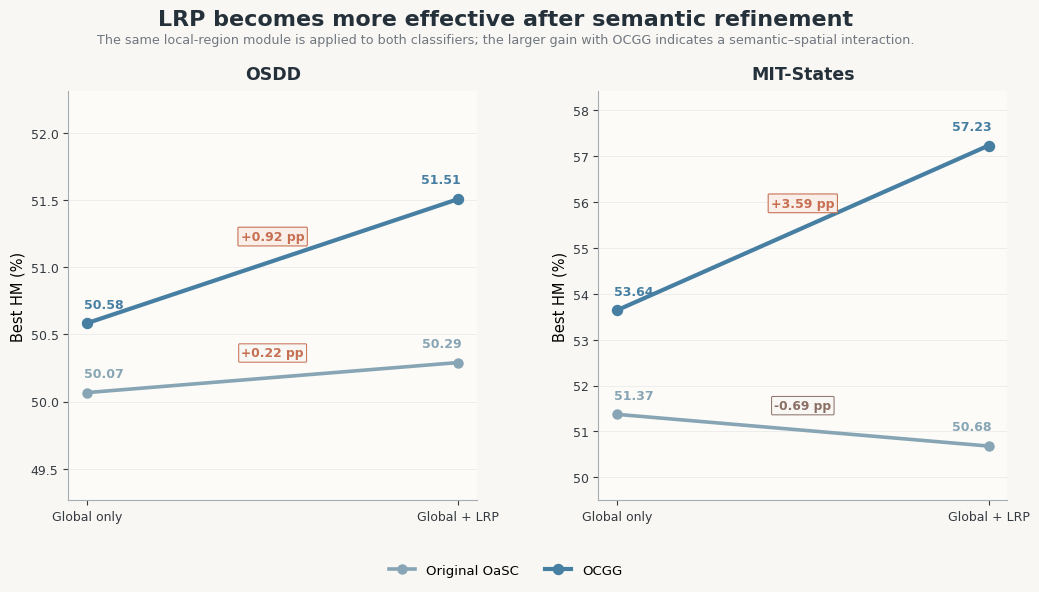

Saved: /kaggle/working/report_exports/lrp_story/L2_lrp_interaction_final.png


In [ ]:
# ---- Original cell 86 ----
# ============================================================
# FIGURE L2 — FINAL CLEAN OCGG × LRP INTERACTION
#
# Improvements:
# - each panel is a true square
# - delta labels sit ABOVE their corresponding lines
# - cleaner spacing / typography
# - gains shown explicitly in percentage points
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


LRP_FIG_DIR = Path(
    "/kaggle/working/report_exports/lrp_story"
)

LRP_FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# HELPER
# ============================================================

def get_metric(
    df,
    method,
    metric="Best HM"
):
    row = df[
        df["Method"] == method
    ]

    if len(row) != 1:
        raise ValueError(
            f'Could not uniquely find method "{method}"'
        )

    return float(
        row.iloc[0][metric]
    )


# ============================================================
# MAIN FIGURE
# ============================================================

def plot_lrp_interaction_final(
    metric="Best HM"
):

    # --------------------------------------------------------
    # Method names
    # --------------------------------------------------------

    oasc_name = "Original OaSC"

    oasc_lrp_name = (
        f"OaSC + LRP (α={FINAL_ALPHA:.2f})"
    )

    ocgg_name = "OCGG"

    ocgg_lrp_name = (
        f"OCGG + LRP (α={FINAL_ALPHA:.2f})"
    )


    datasets = {
        "OSDD": osdd_main_table,
        "MIT-States": mit_main_table
    }


    # ========================================================
    # STYLE
    # ========================================================

    PAPER_BG = "#F8F7F3"
    AX_BG = "#FCFBF8"

    OASC_COLOR = "#87A5B4"
    OCGG_COLOR = "#477FA3"

    NEGATIVE_COLOR = "#8B6F65"
    POSITIVE_COLOR = "#C66F52"

    TEXT = "#25313A"
    MUTED = "#707780"
    GRID = "#DADDDC"


    # ========================================================
    # FIGURE
    #
    # Slightly taller to leave room for title + legend,
    # but individual AXES are forced square below.
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10.8, 6.1)
    )

    fig.patch.set_facecolor(
        PAPER_BG
    )


    # ========================================================
    # DATASET PANELS
    # ========================================================

    for ax, (
        dataset_name,
        table
    ) in zip(
        axes,
        datasets.items()
    ):

        ax.set_facecolor(
            AX_BG
        )

        # ----------------------------------------------------
        # FORCE EACH PLOT PANEL TO BE SQUARE
        # ----------------------------------------------------

        ax.set_box_aspect(1)


        # ====================================================
        # VALUES
        # ====================================================

        oasc = get_metric(
            table,
            oasc_name,
            metric
        )

        oasc_lrp = get_metric(
            table,
            oasc_lrp_name,
            metric
        )

        ocgg = get_metric(
            table,
            ocgg_name,
            metric
        )

        ocgg_lrp = get_metric(
            table,
            ocgg_lrp_name,
            metric
        )


        delta_oasc = (
            oasc_lrp
            -
            oasc
        )

        delta_ocgg = (
            ocgg_lrp
            -
            ocgg
        )


        x0 = 0
        x1 = 1


        # ====================================================
        # OaSC LINE
        # ====================================================

        ax.plot(
            [x0, x1],
            [oasc, oasc_lrp],

            color=OASC_COLOR,

            linewidth=2.6,

            marker="o",
            markersize=6.5,

            markerfacecolor=OASC_COLOR,
            markeredgecolor=OASC_COLOR,

            label="Original OaSC",

            zorder=4
        )


        # ====================================================
        # OCGG LINE
        # ====================================================

        ax.plot(
            [x0, x1],
            [ocgg, ocgg_lrp],

            color=OCGG_COLOR,

            linewidth=3.0,

            marker="o",
            markersize=7.2,

            markerfacecolor=OCGG_COLOR,
            markeredgecolor=OCGG_COLOR,

            label="OCGG",

            zorder=5
        )


        # ====================================================
        # POINT VALUE LABELS
        # ====================================================

        point_specs = [

            (
                x0,
                oasc,
                OASC_COLOR,
                "left"
            ),

            (
                x1,
                oasc_lrp,
                OASC_COLOR,
                "right"
            ),

            (
                x0,
                ocgg,
                OCGG_COLOR,
                "left"
            ),

            (
                x1,
                ocgg_lrp,
                OCGG_COLOR,
                "right"
            ),
        ]


        for x, y, color, side in point_specs:

            x_offset = (
                -2
                if side == "left"
                else 2
            )

            ha = (
                "left"
                if side == "left"
                else "right"
            )


            ax.annotate(
                f"{y:.2f}",

                xy=(
                    x,
                    y
                ),

                xytext=(
                    x_offset,
                    9
                ),

                textcoords="offset points",

                ha=ha,
                va="bottom",

                fontsize=9,

                fontweight="bold",

                color=color,

                zorder=10
            )


        # ====================================================
        # DELTA LABEL — OaSC
        #
        # Actual anchor is ON the middle of the line.
        # xytext moves the label UP in screen coordinates.
        # ====================================================

        mid_oasc = (
            oasc
            +
            oasc_lrp
        ) / 2


        oasc_delta_color = (
            POSITIVE_COLOR
            if delta_oasc >= 0
            else NEGATIVE_COLOR
        )


        ax.annotate(
            f"{delta_oasc:+.2f} pp",

            xy=(
                0.50,
                mid_oasc
            ),

            xytext=(
                0,
                13
            ),

            textcoords="offset points",

            ha="center",
            va="bottom",

            fontsize=8.8,
            fontweight="bold",

            color=oasc_delta_color,

            bbox=dict(
                boxstyle=(
                    "round,pad=0.22,"
                    "rounding_size=0.08"
                ),

                facecolor=PAPER_BG,

                edgecolor=oasc_delta_color,

                linewidth=0.75,

                alpha=0.96
            ),

            zorder=20
        )


        # ====================================================
        # DELTA LABEL — OCGG
        # ====================================================

        mid_ocgg = (
            ocgg
            +
            ocgg_lrp
        ) / 2


        ocgg_delta_color = (
            POSITIVE_COLOR
            if delta_ocgg >= 0
            else NEGATIVE_COLOR
        )


        ax.annotate(
            f"{delta_ocgg:+.2f} pp",

            xy=(
                0.50,
                mid_ocgg
            ),

            xytext=(
                0,
                13
            ),

            textcoords="offset points",

            ha="center",
            va="bottom",

            fontsize=9,
            fontweight="bold",

            color=ocgg_delta_color,

            bbox=dict(
                boxstyle=(
                    "round,pad=0.23,"
                    "rounding_size=0.08"
                ),

                facecolor="#FAEEE8"
                if delta_ocgg >= 0
                else PAPER_BG,

                edgecolor=ocgg_delta_color,

                linewidth=0.8,

                alpha=0.97
            ),

            zorder=20
        )


        # ====================================================
        # AXIS
        # ====================================================

        ax.set_xlim(
            -0.05,
            1.05
        )


        ax.set_xticks(
            [
                0,
                1
            ]
        )


        ax.set_xticklabels(
            [
                "Global only",
                "Global + LRP"
            ],

            fontsize=10
        )


        ax.set_ylabel(
            f"{metric} (%)",

            fontsize=10.5
        )


        ax.set_title(
            dataset_name,

            fontsize=12.5,

            fontweight="bold",

            color=TEXT,

            pad=9
        )


        # ====================================================
        # Y LIMITS
        # ====================================================

        vals = np.array([
            oasc,
            oasc_lrp,
            ocgg,
            ocgg_lrp
        ])


        data_range = (
            vals.max()
            -
            vals.min()
        )


        # enough space for annotations
        vertical_pad = max(
            0.8,
            0.18 * data_range
        )


        ax.set_ylim(
            vals.min()
            -
            vertical_pad,

            vals.max()
            +
            vertical_pad
        )


        # ====================================================
        # GRID
        # ====================================================

        ax.grid(
            axis="y",

            color=GRID,

            linewidth=0.7,

            alpha=0.45
        )


        # ====================================================
        # SPINES
        # ====================================================

        ax.spines[
            "top"
        ].set_visible(
            False
        )

        ax.spines[
            "right"
        ].set_visible(
            False
        )


        ax.spines[
            "left"
        ].set_color(
            "#A6ADB2"
        )

        ax.spines[
            "bottom"
        ].set_color(
            "#A6ADB2"
        )


        ax.tick_params(
            colors="#343A40",
            labelsize=9
        )


    # ========================================================
    # MAIN TITLE
    # ========================================================

    fig.suptitle(
        "LRP becomes more effective after semantic refinement",

        fontsize=16,

        fontweight="bold",

        color=TEXT,

        y=0.975
    )


    # ========================================================
    # SUBTITLE
    # ========================================================

    fig.text(
        0.5,
        0.925,

        (
            "The same local-region module is applied to both classifiers; "
            "the larger gain with OCGG indicates a semantic–spatial interaction."
        ),

        ha="center",
        va="center",

        fontsize=9.2,

        color=MUTED
    )


    # ========================================================
    # SHARED LEGEND
    # ========================================================

    handles, labels = (
        axes[0]
        .get_legend_handles_labels()
    )


    fig.legend(
        handles,
        labels,

        loc="lower center",

        ncol=2,

        frameon=False,

        fontsize=9.5,

        bbox_to_anchor=(
            0.5,
            0.025
        )
    )


    # ========================================================
    # LAYOUT
    # ========================================================

    plt.subplots_adjust(
        left=0.08,
        right=0.98,

        top=0.84,
        bottom=0.17,

        wspace=0.20
    )


    # ========================================================
    # SAVE
    # ========================================================

    out = (
        LRP_FIG_DIR
        /
        "L2_lrp_interaction_final.png"
    )


    plt.savefig(
        out,

        dpi=300,

        facecolor=fig.get_facecolor(),

        bbox_inches="tight"
    )


    plt.show()


    print(
        "Saved:",
        out
    )


# ============================================================
# RUN
# ============================================================

plot_lrp_interaction_final(
    metric="Best HM"
)


Total rescued OSDD examples: 78

Selected rescued examples:


,index,GT,OCGG,OCGG+LRP,Base Margin,LRP Margin,Margin Gain,LRP Residual
0,2481,unplugged,open,unplugged,-0.892,0.428,1.320,10.848
1,2140,plugged,empty,plugged,-0.061,0.822,0.882,5.561
2,397,closed,open,closed,-0.368,0.244,0.612,6.529


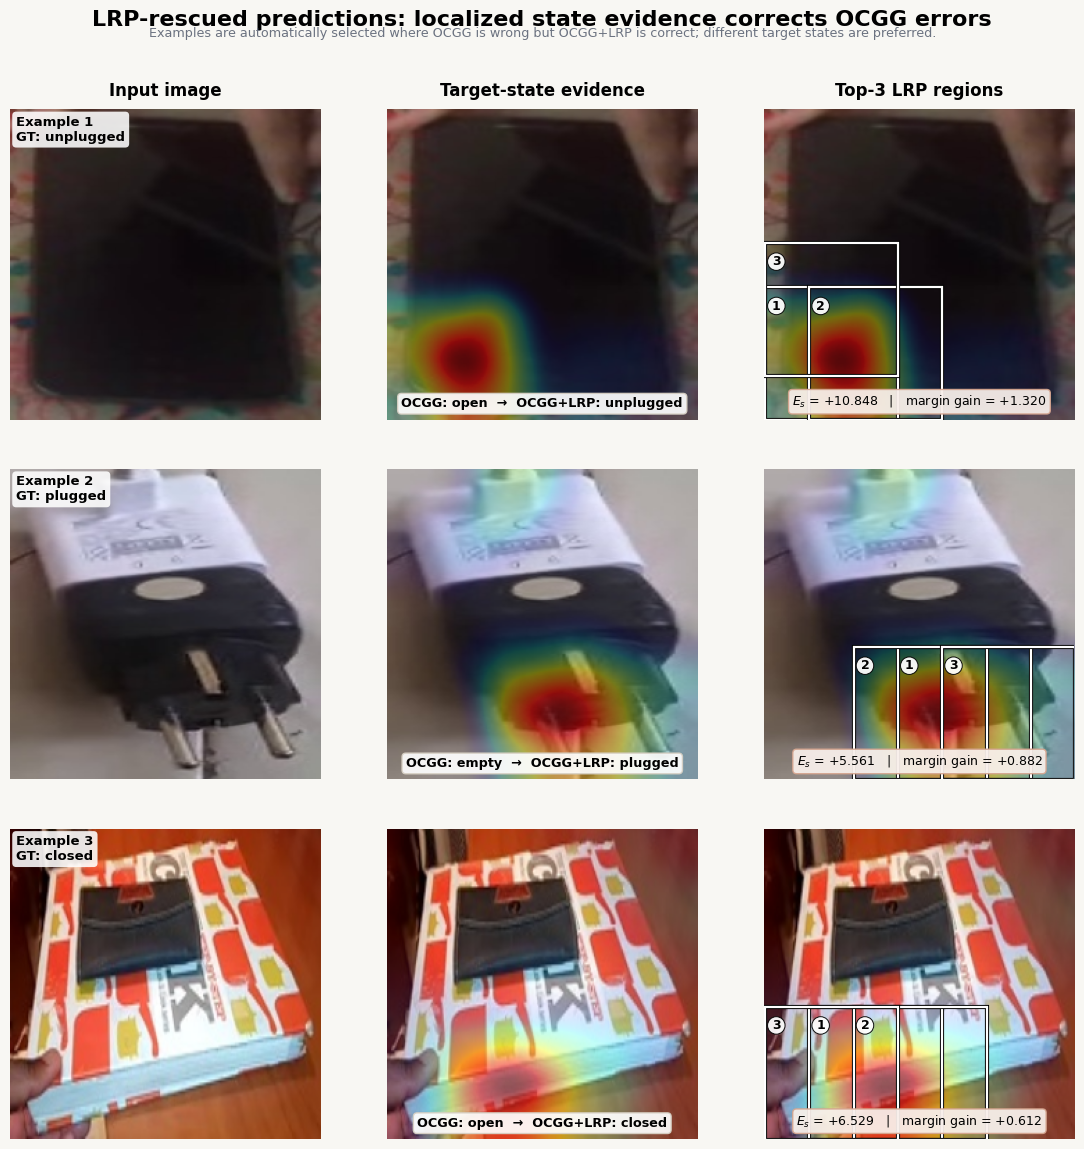

Saved: /kaggle/working/report_exports/lrp_story/L4_three_lrp_rescued_gradcam_style.png


In [ ]:
# ---- Original cell 89 ----
# ============================================================
# QUALITATIVE LRP — 3 AUTOMATICALLY SELECTED RESCUED EXAMPLES
#
# Rescued:
#     OCGG prediction     != Ground Truth
#     OCGG + LRP prediction == Ground Truth
#
# Visualization:
#     Column 1 — input image
#     Column 2 — Grad-CAM-style OCGG state-evidence overlay
#     Column 3 — same overlay + actual Top-3 LRP regions
#
# Examples are ranked by improvement in the GT decision margin.
# Different GT states are preferred when possible.
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import cv2

from pathlib import Path


# ============================================================
# OUTPUT
# ============================================================

LRP_FIG_DIR = Path(
    "/kaggle/working/report_exports/lrp_story"
)

LRP_FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 1. CALIBRATION — EXACTLY MATCH NOTEBOOK EVALUATION
# ============================================================

def calibrate_score_matrix(
    scores,
    gamma,
    unseen_ids
):
    out = (
        scores
        .detach()
        .cpu()
        .clone()
    )

    out[
        :,
        list(unseen_ids)
    ] += float(gamma)

    return out


# ============================================================
# 2. CLASSIFICATION MARGIN
#
# margin =
#     score(GT)
#     -
#     highest score among all non-GT states
#
# Negative margin -> GT loses
# Positive margin -> GT wins
# ============================================================

def true_class_margin(
    calibrated_scores,
    targets
):
    scores = (
        calibrated_scores
        .detach()
        .cpu()
    )

    targets = (
        targets
        .detach()
        .cpu()
        .long()
    )

    n = scores.shape[0]

    true_score = scores[
        torch.arange(n),
        targets
    ]

    other_scores = scores.clone()

    other_scores[
        torch.arange(n),
        targets
    ] = -float("inf")

    strongest_other = (
        other_scores.max(
            dim=1
        ).values
    )

    return (
        true_score
        -
        strongest_other
    )


# ============================================================
# 3. FIND RESCUED EXAMPLES
# ============================================================

def find_best_lrp_rescues(
    n_examples=3,
    prefer_distinct_states=True
):
    """
    Find OSDD examples where:

        OCGG       = wrong
        OCGG + LRP = correct

    Rank by improvement in GT classification margin.
    """

    # --------------------------------------------------------
    # Original OCGG
    # --------------------------------------------------------

    base_cal = calibrate_score_matrix(
        lrp_global_scores["OCGG"],
        contrastive_best["gamma"],
        osdd_unseen_ids
    )


    # --------------------------------------------------------
    # OCGG + locked LRP
    # --------------------------------------------------------

    lrp_cal = calibrate_score_matrix(
        ocgg_lrp_locked_scores,
        ocgg_lrp_locked_best["gamma"],
        osdd_unseen_ids
    )


    targets = (
        lrp_targets
        .detach()
        .cpu()
        .long()
    )


    base_pred = (
        base_cal.argmax(
            dim=1
        )
    )

    lrp_pred = (
        lrp_cal.argmax(
            dim=1
        )
    )


    # --------------------------------------------------------
    # Rescued:
    # OCGG wrong, OCGG+LRP correct
    # --------------------------------------------------------

    rescued_mask = (
        (base_pred != targets)
        &
        (lrp_pred == targets)
    )


    rescued_idx = (
        torch.where(
            rescued_mask
        )[0]
    )


    print(
        "Total rescued OSDD examples:",
        len(rescued_idx)
    )


    if len(rescued_idx) == 0:

        raise RuntimeError(
            "No OCGG -> OCGG+LRP rescued examples were found."
        )


    # --------------------------------------------------------
    # Classification-margin improvement
    # --------------------------------------------------------

    base_margin = true_class_margin(
        base_cal,
        targets
    )

    lrp_margin = true_class_margin(
        lrp_cal,
        targets
    )

    margin_gain = (
        lrp_margin
        -
        base_margin
    )


    # --------------------------------------------------------
    # LRP residual for each example's true state
    # --------------------------------------------------------

    gains = (
        lrp_gains["OCGG"]
        .detach()
        .cpu()
    )


    rows = []


    for idx_t in rescued_idx:

        idx = int(
            idx_t
        )

        gt_id = int(
            targets[idx]
        )

        old_id = int(
            base_pred[idx]
        )

        new_id = int(
            lrp_pred[idx]
        )


        rows.append({

            "index":
                idx,

            "gt_id":
                gt_id,

            "GT":
                OSDD_CLASSES[
                    gt_id
                ],

            "OCGG":
                OSDD_CLASSES[
                    old_id
                ],

            "OCGG+LRP":
                OSDD_CLASSES[
                    new_id
                ],

            "Base Margin":
                float(
                    base_margin[idx]
                ),

            "LRP Margin":
                float(
                    lrp_margin[idx]
                ),

            "Margin Gain":
                float(
                    margin_gain[idx]
                ),

            "LRP Residual":
                float(
                    gains[
                        idx,
                        gt_id
                    ]
                ),

            "LRP Score Addition":
                float(
                    FINAL_ALPHA
                    *
                    gains[
                        idx,
                        gt_id
                    ]
                ),
        })


    rescued_df = (
        pd.DataFrame(
            rows
        )
        .sort_values(
            "Margin Gain",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


    # ========================================================
    # Prefer different states
    # ========================================================

    chosen_rows = []
    used_states = set()


    if prefer_distinct_states:

        for _, row in rescued_df.iterrows():

            state = row["GT"]

            if state in used_states:
                continue

            chosen_rows.append(
                row
            )

            used_states.add(
                state
            )

            if len(chosen_rows) == n_examples:
                break


    # --------------------------------------------------------
    # Fill remaining slots if not enough unique states
    # --------------------------------------------------------

    chosen_indices = {
        int(row["index"])
        for row in chosen_rows
    }


    if len(chosen_rows) < n_examples:

        for _, row in rescued_df.iterrows():

            idx = int(
                row["index"]
            )

            if idx in chosen_indices:
                continue

            chosen_rows.append(
                row
            )

            chosen_indices.add(
                idx
            )

            if len(chosen_rows) == n_examples:
                break


    chosen_df = (
        pd.DataFrame(
            chosen_rows
        )
        .reset_index(
            drop=True
        )
    )


    return (
        chosen_df,
        rescued_df
    )


# ============================================================
# 4. DEDICATED OSDD LAYER4 HOOK
# ============================================================

if "rescued_lrp_hook_handle" in globals():

    try:
        rescued_lrp_hook_handle.remove()

    except Exception:
        pass


rescued_lrp_cache = {}


def rescued_lrp_hook(
    module,
    inp,
    out
):
    rescued_lrp_cache[
        "spatial"
    ] = out.detach()


rescued_backbone = (
    osdd_cnn.module
    if hasattr(
        osdd_cnn,
        "module"
    )
    else osdd_cnn
)


rescued_lrp_hook_handle = (
    rescued_backbone.layer4
    .register_forward_hook(
        rescued_lrp_hook
    )
)


# ============================================================
# 5. BUILD STATE EVIDENCE + TOP-3 REGIONS
# ============================================================

@torch.no_grad()
def get_lrp_visual_data(
    dataset_index,
    state_idx,
    region_size=3,
    top_regions=3,
    blur_ksize=31
):
    """
    Returns:
        image RGB
        smooth positive state evidence heatmap
        top-region image-space boxes
        global evidence
        local evidence
        residual
    """

    # --------------------------------------------------------
    # Image
    # --------------------------------------------------------

    image_tensor, _ = (
        osdd_test_ds[
            int(dataset_index)
        ]
    )


    device = next(
        osdd_cnn.parameters()
    ).device


    x = (
        image_tensor
        .unsqueeze(0)
        .to(device)
    )


    # --------------------------------------------------------
    # OCGG classifier vector
    # --------------------------------------------------------

    vectors = (
        lrp_classifiers["OCGG"]
        .detach()
        .to(device)
    )


    w = (
        vectors[
            int(state_idx),
            :-1
        ]
    )


    # --------------------------------------------------------
    # Forward pass -> layer4 spatial features
    # --------------------------------------------------------

    osdd_cnn.eval()


    _ = osdd_cnn(
        x
    )


    spatial = (
        rescued_lrp_cache[
            "spatial"
        ]
    )


    # [1, C, Hf, Wf]
    patch = torch.einsum(
        "bchw,c->bhw",
        spatial,
        w
    )[0]


    Hf, Wf = (
        patch.shape
    )


    # ========================================================
    # LRP REGION SCORES
    # ========================================================

    region = F.avg_pool2d(
        patch[
            None,
            None
        ],

        kernel_size=region_size,

        stride=1
    )[0, 0]


    flat = (
        region.flatten()
    )


    k = min(
        top_regions,
        flat.numel()
    )


    top_vals, top_idx = torch.topk(
        flat,
        k=k
    )


    global_mean = float(
        patch.mean()
    )

    local_mean = float(
        top_vals.mean()
    )

    residual = (
        local_mean
        -
        global_mean
    )


    # ========================================================
    # POSITIVE EVIDENCE MAP
    #
    # Similar interpretation to Grad-CAM:
    # show positive target-state support.
    # ========================================================

    heat = torch.relu(
        patch
    )


    heat = (
        F.interpolate(
            heat[
                None,
                None
            ],

            size=image_tensor.shape[-2:],

            mode="bicubic",

            align_corners=False
        )[0, 0]
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )


    # --------------------------------------------------------
    # Gaussian smoothing
    # --------------------------------------------------------

    if blur_ksize % 2 == 0:
        blur_ksize += 1


    heat = cv2.GaussianBlur(
        heat,

        (
            blur_ksize,
            blur_ksize
        ),

        0
    )


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    heat = (
        heat
        -
        heat.min()
    )


    if heat.max() > 1e-8:

        heat = (
            heat
            /
            heat.max()
        )


    # ========================================================
    # IMAGE-SPACE REGION BOXES
    # ========================================================

    img_h, img_w = (
        image_tensor.shape[-2:]
    )


    Wr = (
        region.shape[1]
    )


    boxes = []


    for rank, idx in enumerate(
        top_idx.tolist()
    ):

        r, c = divmod(
            idx,
            Wr
        )


        boxes.append({

            "rank":
                rank + 1,

            "score":
                float(
                    top_vals[
                        rank
                    ]
                ),

            "x":
                c
                *
                img_w
                /
                Wf,

            "y":
                r
                *
                img_h
                /
                Hf,

            "w":
                region_size
                *
                img_w
                /
                Wf,

            "h":
                region_size
                *
                img_h
                /
                Hf,
        })


    # --------------------------------------------------------
    # Denormalize
    # --------------------------------------------------------

    img_np = denormalize_image(
        image_tensor
    )


    return {
        "image":
            img_np,

        "heat":
            heat,

        "boxes":
            boxes,

        "global":
            global_mean,

        "local":
            local_mean,

        "residual":
            residual,
    }


# ============================================================
# 6. GRAD-CAM-STYLE ALPHA BLENDING
# ============================================================

def gradcam_style_overlay(
    image,
    heat,
    alpha=0.60,
    cmap_name="jet",
    activation_floor=0.12
):
    """
    Heat affects the image proportionally to activation strength.
    Low-evidence regions remain close to the original image.
    """

    # suppress very weak heat
    visible_heat = np.clip(
        (
            heat
            -
            activation_floor
        )
        /
        (
            1.0
            -
            activation_floor
        ),
        0,
        1
    )


    cmap = plt.get_cmap(
        cmap_name
    )


    heat_rgb = (
        cmap(
            visible_heat
        )[
            ...,
            :3
        ]
    )


    local_alpha = (
        alpha
        *
        visible_heat[
            ...,
            None
        ]
    )


    overlay = (
        image
        *
        (
            1
            -
            local_alpha
        )
        +
        heat_rgb
        *
        local_alpha
    )


    return np.clip(
        overlay,
        0,
        1
    )


# ============================================================
# 7. PLOT TOP RESCUED EXAMPLES
# ============================================================

def plot_best_lrp_rescues(
    n_examples=3,
    blur_ksize=31,
    overlay_alpha=0.60
):

    chosen_df, all_rescued_df = (
        find_best_lrp_rescues(
            n_examples=n_examples,
            prefer_distinct_states=True
        )
    )


    print(
        "\nSelected rescued examples:"
    )

    display(
        chosen_df[
            [
                "index",
                "GT",
                "OCGG",
                "OCGG+LRP",
                "Base Margin",
                "LRP Margin",
                "Margin Gain",
                "LRP Residual"
            ]
        ].round(3)
    )


    # ========================================================
    # FIGURE
    # ========================================================

    fig, axes = plt.subplots(
        len(chosen_df),
        3,

        figsize=(
            11.6,
            3.9 * len(chosen_df)
        )
    )


    if len(chosen_df) == 1:

        axes = np.array([
            axes
        ])


    fig.patch.set_facecolor(
        "#F8F7F3"
    )


    # --------------------------------------------------------
    # Column headings
    # --------------------------------------------------------

    column_titles = [
        "Input image",
        "Target-state evidence",
        "Top-3 LRP regions"
    ]


    for c, title in enumerate(
        column_titles
    ):

        axes[
            0,
            c
        ].set_title(
            title,

            fontsize=12,
            fontweight="bold",

            pad=10
        )


    # ========================================================
    # EACH RESCUED EXAMPLE
    # ========================================================

    for row_idx, row in (
        chosen_df.iterrows()
    ):

        dataset_idx = int(
            row["index"]
        )

        gt_name = str(
            row["GT"]
        )

        gt_id = int(
            OSDD_CLASSES.index(
                gt_name
            )
        )


        vis = get_lrp_visual_data(
            dataset_index=dataset_idx,
            state_idx=gt_id,
            region_size=REGION_SIZE,
            top_regions=TOPK,
            blur_ksize=blur_ksize
        )


        image = vis[
            "image"
        ]

        heat = vis[
            "heat"
        ]


        overlay = gradcam_style_overlay(
            image,
            heat,

            alpha=overlay_alpha,

            cmap_name="jet"
        )


        # ====================================================
        # A — INPUT
        # ====================================================

        ax = axes[
            row_idx,
            0
        ]


        ax.imshow(
            image
        )

        ax.axis(
            "off"
        )


        ax.text(
            0.02,
            0.98,

            f'Example {row_idx + 1}\n'
            f'GT: {gt_name}',

            transform=ax.transAxes,

            ha="left",
            va="top",

            fontsize=9.5,
            fontweight="bold",

            bbox=dict(
                boxstyle="round,pad=0.30",
                facecolor="white",
                edgecolor="none",
                alpha=0.88
            )
        )


        # ====================================================
        # B — SMOOTH HEATMAP OVERLAY
        # ====================================================

        ax = axes[
            row_idx,
            1
        ]


        ax.imshow(
            overlay
        )

        ax.axis(
            "off"
        )


        ax.text(
            0.5,
            0.03,

            f'OCGG: {row["OCGG"]}  →  '
            f'OCGG+LRP: {row["OCGG+LRP"]}',

            transform=ax.transAxes,

            ha="center",
            va="bottom",

            fontsize=9.2,
            fontweight="bold",

            bbox=dict(
                boxstyle="round,pad=0.30",
                facecolor="white",
                edgecolor="#D7D0C4",
                alpha=0.92
            )
        )


        # ====================================================
        # C — OVERLAY + ACTUAL TOP-3 REGIONS
        # ====================================================

        ax = axes[
            row_idx,
            2
        ]


        ax.imshow(
            overlay
        )


        for box in vis[
            "boxes"
        ]:

            # dark outer border
            ax.add_patch(
                patches.Rectangle(
                    (
                        box["x"],
                        box["y"]
                    ),

                    box["w"],
                    box["h"],

                    fill=False,

                    linewidth=3.0,

                    edgecolor="black"
                )
            )


            # light inner border
            ax.add_patch(
                patches.Rectangle(
                    (
                        box["x"],
                        box["y"]
                    ),

                    box["w"],
                    box["h"],

                    fill=False,

                    linewidth=1.6,

                    edgecolor="white"
                )
            )


            ax.text(
                box["x"] + 5,
                box["y"] + 16,

                str(
                    box["rank"]
                ),

                fontsize=9,

                fontweight="bold",

                color="black",

                bbox=dict(
                    boxstyle="circle,pad=0.18",
                    facecolor="white",
                    edgecolor="black",
                    linewidth=0.7,
                    alpha=0.94
                )
            )


        ax.axis(
            "off"
        )


        ax.text(
            0.5,
            0.03,

            (
                f'$E_s$ = '
                f'{vis["residual"]:+.3f}'
                f'   |   margin gain = '
                f'{row["Margin Gain"]:+.3f}'
            ),

            transform=ax.transAxes,

            ha="center",
            va="bottom",

            fontsize=9,

            bbox=dict(
                boxstyle="round,pad=0.30",
                facecolor="#F8EFEA",
                edgecolor="#D5A58F",
                alpha=0.94
            )
        )


    # ========================================================
    # OVERALL TITLE
    # ========================================================

    fig.suptitle(
        (
            "LRP-rescued predictions: localized state evidence "
            "corrects OCGG errors"
        ),

        fontsize=16,
        fontweight="bold",

        y=0.995
    )


    fig.text(
        0.5,
        0.972,

        (
            "Examples are automatically selected where "
            "OCGG is wrong but OCGG+LRP is correct; "
            "different target states are preferred."
        ),

        ha="center",

        fontsize=9.2,

        color="#6B7280"
    )


    plt.subplots_adjust(
        top=0.91,
        bottom=0.03,
        left=0.02,
        right=0.98,

        hspace=0.16,
        wspace=0.05
    )


    # ========================================================
    # SAVE
    # ========================================================

    out = (
        LRP_FIG_DIR
        /
        "L4_three_lrp_rescued_gradcam_style.png"
    )


    plt.savefig(
        out,

        dpi=300,

        facecolor=fig.get_facecolor(),

        bbox_inches="tight"
    )


    plt.show()


    print(
        "Saved:",
        out
    )


    return (
        chosen_df,
        all_rescued_df
    )


# ============================================================
# RUN — 3 RESCUED EXAMPLES
# ============================================================

selected_lrp_rescues, all_lrp_rescues = (
    plot_best_lrp_rescues(
        n_examples=3,
        blur_ksize=31,
        overlay_alpha=0.60
    )
)


## Appendix — corrected optional LRP explainer

The original late L1/L3 explainer code referenced the generic `cnn` variable after it had been rebound to the MIT model.  
Below, that code is patched to use `LRP_VIS_MODEL = osdd_cnn`.

**Saved outputs are intentionally removed. Rerun this appendix on Kaggle before using these optional explainer figures.**


In [ ]:
# ---- Original cell 83 ----
# ============================================================
# LRP STORY — OSDD-SAFE SETUP
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path


LRP_FIG_DIR = Path(
    "/kaggle/working/report_exports/lrp_story"
)
LRP_FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# IMPORTANT — LOCK VISUALIZATION TO OSDD
# ============================================================

LRP_VIS_MODEL = osdd_cnn
LRP_VIS_DATASET = osdd_test_ds
LRP_VIS_LOADER = osdd_test_loader


# ============================================================
# EXAMPLE
# ============================================================

EXAMPLE_STATE = "open"
EXAMPLE_INDEX = 1842


# ============================================================
# LRP CONFIG
# ============================================================

REGION_SIZE = 3
TOPK = 3

OPPOSITE_MAP = OPPOSITE_STATE


# ============================================================
# SANITY CHECK
# ============================================================

print(
    "Visualization dataset:",
    type(LRP_VIS_DATASET).__name__
)

print(
    "Number of OSDD test images:",
    len(LRP_VIS_DATASET)
)

print(
    "Requested index:",
    EXAMPLE_INDEX
)

assert 0 <= EXAMPLE_INDEX < len(LRP_VIS_DATASET), (
    f"EXAMPLE_INDEX={EXAMPLE_INDEX} is outside the OSDD test set "
    f"(size={len(LRP_VIS_DATASET)})."
)

# ------------------------------------------------------------
# IMPORTANT:
# You must connect these two functions to your notebook.
# They should return a 2048-D classifier weight vector.
#
# method = "oasc" or "ocgg"
# state  = e.g. "open"
# ------------------------------------------------------------

def get_state_weight_vector(method, state):
    """
    Return a 2048-D torch tensor on DEVICE.

    EDIT THIS FUNCTION TO MATCH YOUR NOTEBOOK VARIABLES.
    """

    # ========================================================
    # EXAMPLE PATTERNS — replace one of these with your real one
    # ========================================================

    # ---- Pattern A: if you already have dicts ----
    # if method == "oasc":
    #     return original_state_weight_dict[state].to(DEVICE).float()
    # elif method == "ocgg":
    #     return ocgg_state_weight_dict[state].to(DEVICE).float()

    # ---- Pattern B: if you have matrices + state order ----
    # idx = state_name_to_idx[state]
    # if method == "oasc":
    #     return original_weight_matrix[idx].to(DEVICE).float()
    # elif method == "ocgg":
    #     return ocgg_weight_matrix[idx].to(DEVICE).float()

    # ---- Pattern C: if your notebook stores generated weights in DataFrames / dicts ----
    # if method == "oasc":
    #     return torch.tensor(base_state_weights[state], device=DEVICE).float()
    # elif method == "ocgg":
    #     return torch.tensor(contrastive_state_weights[state], device=DEVICE).float()

    raise NotImplementedError(
        "Edit get_state_weight_vector(method, state) to return the "
        "2048-D classifier weight vector from your notebook."
    )


# ------------------------------------------------------------
# Utility: denormalize ImageNet-style input
# ------------------------------------------------------------

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize_image(img):
    x = img.detach().cpu()
    x = x * IMAGENET_STD + IMAGENET_MEAN
    x = x.clamp(0, 1)
    return x.permute(1, 2, 0).numpy()


# ------------------------------------------------------------
# Get one sample by global index from a loader
# ------------------------------------------------------------

def get_sample_from_loader(loader, global_index=0):
    """
    Returns image_tensor [3,H,W], target (optional)
    Assumes loader.dataset supports indexing.
    """
    item = loader.dataset[global_index]

    if isinstance(item, (tuple, list)):
        image = item[0]
        target = item[1] if len(item) > 1 else None
    else:
        image = item
        target = None

    return image, target


# ------------------------------------------------------------
# layer4 hook to capture spatial feature map
# ------------------------------------------------------------

if "lrp_vis_hook_handle" in globals():
    try:
        lrp_vis_hook_handle.remove()
    except Exception:
        pass

lrp_vis_cache = {}

def lrp_vis_layer4_hook(module, inp, out):
    lrp_vis_cache["spatial"] = out.detach()

backbone = LRP_VIS_MODEL.module if hasattr(LRP_VIS_MODEL, "module") else LRP_VIS_MODEL
lrp_vis_hook_handle = backbone.layer4.register_forward_hook(lrp_vis_layer4_hook)


# ------------------------------------------------------------
# Capture pooled + spatial features for one image
# ------------------------------------------------------------

@torch.no_grad()
def extract_pooled_and_spatial(image_tensor):
    """
    image_tensor: [3,H,W]
    returns:
        pooled  : [2048]
        spatial : [2048,7,7]
    """
    x = image_tensor.unsqueeze(0).to(DEVICE)

    pooled = LRP_VIS_MODEL(x)                      # [1,2048]
    spatial = lrp_vis_cache["spatial"]   # [1,2048,7,7]

    pooled = pooled.squeeze(0)
    spatial = spatial.squeeze(0)

    return pooled, spatial


# ------------------------------------------------------------
# Build state evidence map P_s(h,w) = w_s^T F(h,w)
# ------------------------------------------------------------

def compute_state_evidence_map(spatial_feature, weight_vector):
    """
    spatial_feature: [C,H,W]
    weight_vector  : [C]
    returns:
        state_map   : [H,W]
    """
    return torch.einsum("c,chw->hw", weight_vector, spatial_feature)


# ------------------------------------------------------------
# Local region pooling stats
# ------------------------------------------------------------

def compute_lrp_statistics(state_map, region_size=3, topk=3):
    """
    state_map: [H,W]
    returns:
        pooled_map  : [H-r+1, W-r+1]
        top_vals    : [topk]
        top_idx     : [topk]
        mean_global : scalar
        local_mean  : scalar
        residual    : scalar
    """
    pooled_map = F.avg_pool2d(
        state_map.unsqueeze(0).unsqueeze(0),
        kernel_size=region_size,
        stride=1
    ).squeeze(0).squeeze(0)

    flat = pooled_map.flatten()
    top_vals, top_idx = torch.topk(flat, k=min(topk, flat.numel()))

    mean_global = state_map.mean().item()
    local_mean = top_vals.mean().item()
    residual = local_mean - mean_global

    return pooled_map, top_vals, top_idx, mean_global, local_mean, residual


# ------------------------------------------------------------
# Convert pooled-map flat index to 2D
# ------------------------------------------------------------

def unravel_top_idx(flat_idx, width):
    row = int(flat_idx) // width
    col = int(flat_idx) % width
    return row, col

# ---- Original cell 84 ----
# ============================================================
# EXACT OSDD CLASSIFIER-WEIGHT ACCESSOR
# ============================================================

def get_state_weight_vector(
    method,
    state
):
    """
    Return the 2048-D classifier weight vector for one OSDD state.

    method:
        "oasc" -> released OaSC Tr-GCN classifier
        "ocgg" -> OCGG-refined Tr-GCN classifier
    """

    if state not in OSDD_CLASSES:
        raise ValueError(
            f'Unknown OSDD state "{state}". '
            f"Available states: {OSDD_CLASSES}"
        )

    state_idx = OSDD_CLASSES.index(state)

    if method.lower() == "oasc":

        vector_2049 = (
            state_vectors[
                state_idx
            ]
        )

    elif method.lower() == "ocgg":

        vector_2049 = (
            contrastive_vectors[
                state_idx
            ]
        )

    else:

        raise ValueError(
            'method must be either "oasc" or "ocgg"'
        )

    # 2049 = 2048 classifier weights + 1 bias
    weight = (
        vector_2049[:-1]
        .detach()
        .to(DEVICE)
        .float()
    )

    assert weight.numel() == 2048, (
        f"Expected a 2048-D classifier weight, "
        f"got shape {tuple(weight.shape)}"
    )

    return weight

# ---- Original cell 85 ----
# ============================================================
# FIGURE L1 — GRAD-CAM STYLE LRP VISUALIZATION
# OaSC vs OCGG spatial evidence for one image/state
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn.functional as F
import cv2


# ------------------------------------------------------------
# Helper: normalize map to [0, 1]
# ------------------------------------------------------------

def normalize_map(x):
    x = x.astype(np.float32)
    x_min = x.min()
    x_max = x.max()
    if x_max - x_min < 1e-8:
        return np.zeros_like(x, dtype=np.float32)
    return (x - x_min) / (x_max - x_min)


# ------------------------------------------------------------
# Helper: resize + Gaussian blur
# ------------------------------------------------------------

def upsample_and_blur_map(
    heatmap_2d,
    out_h,
    out_w,
    blur_ksize=31,
    blur_sigma=0
):
    """
    heatmap_2d: small 2D map (e.g. 7x7)
    returns: smoothed heatmap resized to image resolution
    """

    heatmap = heatmap_2d.astype(np.float32)

    heatmap_up = cv2.resize(
        heatmap,
        (out_w, out_h),
        interpolation=cv2.INTER_CUBIC
    )

    # kernel size must be odd
    if blur_ksize % 2 == 0:
        blur_ksize += 1

    heatmap_blur = cv2.GaussianBlur(
        heatmap_up,
        (blur_ksize, blur_ksize),
        blur_sigma
    )

    heatmap_blur = normalize_map(heatmap_blur)
    return heatmap_blur


# ------------------------------------------------------------
# Helper: make colored overlay like Grad-CAM
# ------------------------------------------------------------

def make_overlay(
    image_rgb,
    heatmap_2d,
    alpha=0.42,
    cmap_name="jet"
):
    """
    image_rgb: H x W x 3 in [0,1]
    heatmap_2d: H x W in [0,1]
    """
    cmap = plt.get_cmap(cmap_name)
    heat_rgb = cmap(heatmap_2d)[..., :3]   # drop alpha
    overlay = (1 - alpha) * image_rgb + alpha * heat_rgb
    overlay = np.clip(overlay, 0, 1)
    return overlay


# ------------------------------------------------------------
# Helper: draw top-k pooled windows on the original image
# ------------------------------------------------------------

def draw_topk_windows_on_image(
    ax,
    topidx,
    pooled_map_shape,
    image_h,
    image_w,
    region_size=3,
    color="cyan",
    linewidth=2.0
):
    """
    pooled_map_shape corresponds to the output of 3x3 avg pooling
    on a 7x7 map => typically 5x5 if stride=1.
    """
    pooled_h, pooled_w = pooled_map_shape

    # original evidence map size is inferred:
    map_h = pooled_h + region_size - 1
    map_w = pooled_w + region_size - 1

    cell_h = image_h / map_h
    cell_w = image_w / map_w

    for i, idx in enumerate(topidx):
        idx = int(idx.item())
        r = idx // pooled_w
        c = idx % pooled_w

        # region covers region_size x region_size cells in the original 7x7 map
        x0 = c * cell_w
        y0 = r * cell_h
        box_w = region_size * cell_w
        box_h = region_size * cell_h

        rect = patches.Rectangle(
            (x0, y0),
            box_w,
            box_h,
            linewidth=linewidth,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)

        ax.text(
            x0 + 4,
            y0 + 16,
            f"{i+1}",
            color="black",
            fontsize=10,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="none",
                alpha=0.9
            )
        )


# ------------------------------------------------------------
# Main figure
# ------------------------------------------------------------

def plot_lrp_story_example_overlay(
    example_index=EXAMPLE_INDEX,
    state=EXAMPLE_STATE,
    region_size=REGION_SIZE,
    topk=TOPK,
    alpha_overlay=0.42,
    blur_ksize=31
):
    opposite = OPPOSITE_MAP[state]

    # --------------------------------------------------------
    # Sample + features
    # --------------------------------------------------------

    image_tensor, target = get_sample_from_loader(
        LRP_VIS_LOADER,
        global_index=example_index
    )

    pooled_feature, spatial_feature = extract_pooled_and_spatial(image_tensor)

    # --------------------------------------------------------
    # Weights
    # --------------------------------------------------------

    w_oasc = get_state_weight_vector("oasc", state)
    w_ocgg = get_state_weight_vector("ocgg", state)

    # --------------------------------------------------------
    # Raw evidence maps (7x7)
    # --------------------------------------------------------

    map_oasc = compute_state_evidence_map(
        spatial_feature,
        w_oasc
    ).detach().cpu()

    map_ocgg = compute_state_evidence_map(
        spatial_feature,
        w_ocgg
    ).detach().cpu()

    # --------------------------------------------------------
    # LRP stats
    # --------------------------------------------------------

    pooled_oasc, topvals_oasc, topidx_oasc, mean_oasc, local_oasc, residual_oasc = (
        compute_lrp_statistics(
            map_oasc,
            region_size=region_size,
            topk=topk
        )
    )

    pooled_ocgg, topvals_ocgg, topidx_ocgg, mean_ocgg, local_ocgg, residual_ocgg = (
        compute_lrp_statistics(
            map_ocgg,
            region_size=region_size,
            topk=topk
        )
    )

    # --------------------------------------------------------
    # Image prep
    # --------------------------------------------------------

    img_np = denormalize_image(image_tensor)   # H x W x 3 in [0,1]
    H, W, _ = img_np.shape

    # --------------------------------------------------------
    # Upsample + blur
    # --------------------------------------------------------

    oasc_heat = upsample_and_blur_map(
        normalize_map(map_oasc.numpy()),
        H,
        W,
        blur_ksize=blur_ksize
    )

    ocgg_heat = upsample_and_blur_map(
        normalize_map(map_ocgg.numpy()),
        H,
        W,
        blur_ksize=blur_ksize
    )

    # --------------------------------------------------------
    # Overlay images
    # --------------------------------------------------------

    oasc_overlay = make_overlay(
        img_np,
        oasc_heat,
        alpha=alpha_overlay,
        cmap_name="jet"
    )

    ocgg_overlay = make_overlay(
        img_np,
        ocgg_heat,
        alpha=alpha_overlay,
        cmap_name="jet"
    )

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(2, 3, figsize=(15, 8.8))
    fig.patch.set_facecolor("#F8F7F3")

    # ========== Panel 1 ==========
    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title("Input image", fontsize=12, fontweight="bold")
    axes[0, 0].axis("off")

    # ========== Panel 2 ==========
    axes[0, 1].imshow(oasc_overlay)
    axes[0, 1].set_title(
        f'OaSC evidence overlay for "{state}"',
        fontsize=12,
        fontweight="bold"
    )
    axes[0, 1].axis("off")
    draw_topk_windows_on_image(
        axes[0, 1],
        topidx_oasc,
        pooled_oasc.shape,
        H, W,
        region_size=region_size,
        color="cyan"
    )

    # ========== Panel 3 ==========
    axes[0, 2].imshow(ocgg_overlay)
    axes[0, 2].set_title(
        f'OCGG evidence overlay for "{state}"',
        fontsize=12,
        fontweight="bold"
    )
    axes[0, 2].axis("off")
    draw_topk_windows_on_image(
        axes[0, 2],
        topidx_ocgg,
        pooled_ocgg.shape,
        H, W,
        region_size=region_size,
        color="cyan"
    )

    # ========== Panel 4 ==========
    im4 = axes[1, 0].imshow(map_oasc.numpy(), cmap="RdYlBu_r")
    axes[1, 0].set_title(
        f'OaSC raw 7×7 state evidence map\n'
        f'global={mean_oasc:.3f}, local={local_oasc:.3f}, residual={residual_oasc:.3f}',
        fontsize=11,
        fontweight="bold"
    )
    axes[1, 0].set_xticks([])
    axes[1, 0].set_yticks([])
    plt.colorbar(im4, ax=axes[1, 0], fraction=0.046, pad=0.04)

    # ========== Panel 5 ==========
    im5 = axes[1, 1].imshow(map_ocgg.numpy(), cmap="RdYlBu_r")
    axes[1, 1].set_title(
        f'OCGG raw 7×7 state evidence map\n'
        f'global={mean_ocgg:.3f}, local={local_ocgg:.3f}, residual={residual_ocgg:.3f}',
        fontsize=11,
        fontweight="bold"
    )
    axes[1, 1].set_xticks([])
    axes[1, 1].set_yticks([])
    plt.colorbar(im5, ax=axes[1, 1], fraction=0.046, pad=0.04)

    # ========== Panel 6 ==========
    axes[1, 2].axis("off")
    story_text = (
        "LRP keeps the global classifier score and adds only a residual from the strongest local regions.\n"
        "This emphasizes spatially concentrated state evidence without retraining the backbone."
    )
    axes[1, 2].text(
        0.02, 0.98,
        story_text,
        ha="left",
        va="top",
        fontsize=10.8,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="#F3F1EA",
            edgecolor="#D7D0C4"
        )
    )

    fig.suptitle(
        f'LRP motivation — localized state evidence for "{state}"',
        fontsize=16,
        fontweight="bold",
        y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    out = LRP_FIG_DIR / f"l1_lrp_story_overlay_{state}_idx{example_index}.png"
    plt.savefig(out, dpi=300, facecolor=fig.get_facecolor())
    plt.show()

    print("Saved:", out)

    return {
        "image": img_np,
        "map_oasc": map_oasc,
        "map_ocgg": map_ocgg,
        "pooled_oasc": pooled_oasc,
        "pooled_ocgg": pooled_ocgg,
        "residual_oasc": residual_oasc,
        "residual_ocgg": residual_ocgg,
        "oasc_overlay": oasc_overlay,
        "ocgg_overlay": ocgg_overlay
    }


# Run this
lrp_example_artifacts = plot_lrp_story_example_overlay(
    example_index=1843,
    state=EXAMPLE_STATE,
    region_size=REGION_SIZE,
    topk=TOPK,
    alpha_overlay=0.42,
    blur_ksize=31
)

# ---- Original cell 88 ----
# ============================================================
# FIGURE L3 — INTERPRETABLE LRP EXPLAINER
#
# Panel A: input image
# Panel B: 7x7 state evidence map with selected 3x3 windows
# Panel C: pooled 5x5 region scores with top-3 highlighted
# Panel D: explicit residual decomposition
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np


def plot_lrp_residual_explainer_clear(
    example_index=EXAMPLE_INDEX,
    state=EXAMPLE_STATE,
    method="ocgg",
    region_size=REGION_SIZE,
    topk=TOPK
):

    # ========================================================
    # GET SAMPLE
    # ========================================================

    image_tensor, _ = get_sample_from_loader(
        LRP_VIS_LOADER,
        global_index=example_index
    )

    image_np = denormalize_image(image_tensor)

    _, spatial_feature = extract_pooled_and_spatial(image_tensor)

    w = get_state_weight_vector(method, state)

    state_map = (
        compute_state_evidence_map(
            spatial_feature,
            w
        )
        .detach()
        .cpu()
    )

    (
        pooled_map,
        top_vals,
        top_idx,
        global_mean,
        local_mean,
        residual
    ) = compute_lrp_statistics(
        state_map,
        region_size=region_size,
        topk=topk
    )

    # ========================================================
    # STYLE
    # ========================================================

    PAPER_BG = "#F8F7F3"
    AX_BG = "#FCFBF8"

    TEXT = "#27323A"
    MUTED = "#6B7280"

    BOX_COLORS = [
        "#2E86AB",   # 1
        "#D1495B",   # 2
        "#3A7D44",   # 3
    ]

    # ========================================================
    # FIGURE
    # ========================================================

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16.5, 4.8),
        gridspec_kw={"width_ratios": [1.1, 1.05, 1.05, 1.35]}
    )

    fig.patch.set_facecolor(PAPER_BG)

    for ax in axes:
        ax.set_facecolor(AX_BG)

    ax_img, ax_state, ax_pool, ax_formula = axes

    # ========================================================
    # PANEL A — INPUT IMAGE
    # ========================================================

    ax_img.imshow(image_np)
    ax_img.set_title(
        "A. Input image",
        fontsize=12.5,
        fontweight="bold"
    )
    ax_img.axis("off")

    ax_img.text(
        0.5,
        -0.10,
        f'Example image for state "{state}"',
        transform=ax_img.transAxes,
        ha="center",
        va="top",
        fontsize=9,
        color=MUTED
    )

    # ========================================================
    # PANEL B — RAW 7x7 STATE EVIDENCE MAP
    # ========================================================

    vmax = max(
        abs(float(state_map.min())),
        abs(float(state_map.max()))
    )

    im0 = ax_state.imshow(
        state_map.numpy(),
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax
    )

    ax_state.set_title(
        r'B. State evidence map $P_s(h,w)$',
        fontsize=12.5,
        fontweight="bold"
    )

    ax_state.set_xticks(range(state_map.shape[1]))
    ax_state.set_yticks(range(state_map.shape[0]))
    ax_state.tick_params(labelsize=8)

    cbar0 = plt.colorbar(
        im0,
        ax=ax_state,
        fraction=0.046,
        pad=0.04
    )
    cbar0.ax.tick_params(labelsize=8)

    # Draw selected 3x3 windows ON THE 7x7 MAP
    pooled_h, pooled_w = pooled_map.shape

    for rank, idx in enumerate(top_idx):
        color = BOX_COLORS[rank % len(BOX_COLORS)]
        idx = int(idx.item())
        r = idx // pooled_w
        c = idx % pooled_w

        rect = patches.Rectangle(
            (c - 0.5, r - 0.5),
            region_size,
            region_size,
            linewidth=2.2,
            edgecolor=color,
            facecolor="none"
        )
        ax_state.add_patch(rect)

        ax_state.text(
            c + 0.1,
            r + 0.15,
            f"{rank+1}",
            color="white",
            fontsize=9,
            fontweight="bold",
            bbox=dict(
                boxstyle="circle,pad=0.20",
                facecolor=color,
                edgecolor="white",
                linewidth=0.8
            )
        )

    ax_state.text(
        0.5,
        -0.14,
        "Apply the generated state classifier at every spatial location.\n"
        "Colored boxes show the 3×3 regions selected by LRP.",
        transform=ax_state.transAxes,
        ha="center",
        va="top",
        fontsize=8.8,
        color=MUTED
    )

    # ========================================================
    # PANEL C — POOLED REGION MAP
    # ========================================================

    im1 = ax_pool.imshow(
        pooled_map.numpy(),
        cmap="YlOrRd"
    )

    ax_pool.set_title(
        f"C. {region_size}×{region_size} pooled local regions",
        fontsize=12.5,
        fontweight="bold"
    )

    ax_pool.set_xticks(range(pooled_map.shape[1]))
    ax_pool.set_yticks(range(pooled_map.shape[0]))
    ax_pool.tick_params(labelsize=8)

    cbar1 = plt.colorbar(
        im1,
        ax=ax_pool,
        fraction=0.046,
        pad=0.04
    )
    cbar1.ax.tick_params(labelsize=8)

    # Highlight top-k and write actual score
    for rank, idx in enumerate(top_idx):
        color = BOX_COLORS[rank % len(BOX_COLORS)]
        idx = int(idx.item())
        r = idx // pooled_w
        c = idx % pooled_w
        score = float(top_vals[rank].item())

        rect = patches.Rectangle(
            (c - 0.5, r - 0.5),
            1,
            1,
            linewidth=2.2,
            edgecolor=color,
            facecolor="none"
        )
        ax_pool.add_patch(rect)

        ax_pool.text(
            c,
            r,
            f"{rank+1}\n{score:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold",
            color="black",
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="none",
                alpha=0.82
            )
        )

    ax_pool.text(
        0.5,
        -0.14,
        f"Average-pool every {region_size}×{region_size} window.\n"
        f"LRP keeps the Top-{topk} pooled regions and averages them to compute $L_s$.",
        transform=ax_pool.transAxes,
        ha="center",
        va="top",
        fontsize=8.8,
        color=MUTED
    )

    # ========================================================
    # PANEL D — RESIDUAL DECOMPOSITION
    # ========================================================

    ax_formula.axis("off")
    ax_formula.set_title(
        "D. What LRP adds beyond GAP",
        fontsize=12.5,
        fontweight="bold"
    )

    # Step cards
    y0 = 0.88
    dy = 0.22

    ax_formula.text(
        0.02, y0,
        "Step 1 — Global evidence",
        transform=ax_formula.transAxes,
        ha="left", va="top",
        fontsize=10.5,
        fontweight="bold",
        color=TEXT
    )
    ax_formula.text(
        0.02, y0 - 0.08,
        r"$\mathrm{mean}(P_s)$"
        f" = {global_mean:.3f}",
        transform=ax_formula.transAxes,
        ha="left", va="top",
        fontsize=11,
        color="#5E8397",
        bbox=dict(
            boxstyle="round,pad=0.30",
            facecolor="#EDF3F6",
            edgecolor="#C8D7DF"
        )
    )

    ax_formula.text(
        0.02, y0 - dy,
        f"Step 2 — Local evidence",
        transform=ax_formula.transAxes,
        ha="left", va="top",
        fontsize=10.5,
        fontweight="bold",
        color=TEXT
    )
    ax_formula.text(
        0.02, y0 - dy - 0.08,
        rf"$L_s = \mathrm{{mean}}(\mathrm{{Top-{topk}}})$"
        f" = {local_mean:.3f}",
        transform=ax_formula.transAxes,
        ha="left", va="top",
        fontsize=11,
        color="#C26A4D",
        bbox=dict(
            boxstyle="round,pad=0.30",
            facecolor="#FAEEE8",
            edgecolor="#D8AB99"
        )
    )

    ax_formula.text(
        0.02, y0 - 2*dy,
        "Step 3 — Local residual",
        transform=ax_formula.transAxes,
        ha="left", va="top",
        fontsize=10.5,
        fontweight="bold",
        color=TEXT
    )
    ax_formula.text(
        0.02, y0 - 2*dy - 0.08,
        r"$E_s = L_s - \mathrm{mean}(P_s)$"
        f"\n= {local_mean:.3f} - ({global_mean:.3f})"
        f"\n= {residual:+.3f}",
        transform=ax_formula.transAxes,
        ha="left", va="top",
        fontsize=11,
        color="#B45539",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="#FBEDE8",
            edgecolor="#D79A86"
        )
    )

    # ========================================================
    # FIGURE TITLE
    # ========================================================

    fig.suptitle(
        f'How LRP extracts localized evidence for "{state}"',
        fontsize=16,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()

    out = (
        LRP_FIG_DIR
        /
        f"L3_lrp_residual_clear_{method}_{state}_idx{example_index}.png"
    )

    plt.savefig(
        out,
        dpi=300,
        facecolor=fig.get_facecolor(),
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", out)


plot_lrp_residual_explainer_clear(
    example_index=1843,
    state=EXAMPLE_STATE,
    method="ocgg"
)


## Final result snapshot

| Dataset | Original OaSC HM | OCGG HM | OCGG + LRP HM |
|---|---:|---:|---:|
| OSDD | 50.07% | 50.58% | **51.51%** |
| MIT-States | 51.37% | 53.64% | **57.23%** |

**Safe conclusion:** OCGG + LRP is the strongest **final combination evaluated**.

On MIT-States, Fixed CLIP and Adaptive CLIP have slightly higher semantic-only HM than OCGG, so the notebook does not claim that OCGG alone is universally the strongest semantic reranker.
